In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import geopandas as gpd
import osmnx as ox
from typing import List

# Import necessary libraries
import pandas as pd
from collections import defaultdict
import geopandas as gpd
from shapely import wkt
import shapely

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
%matplotlib inline
import datetime
import time
import numpy as np
import xml.etree.ElementTree as ET 
import matsim

import utm
from shapely.geometry import Polygon, Point
import gzip
from matplotlib import cm

import matplotlib.ticker as ticker
import matplotlib.font_manager as font_manager
import matplotlib as mpl
from matplotlib.lines import Line2D
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
import json



In [2]:
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)

def determine_area_type(raumtyp):
    if raumtyp in [1, 2, 3]:
        return 'Urban'
    elif raumtyp in [4, 5, 6]:
        return 'Suburban'
    elif raumtyp in [7, 8]:
        return 'Rural'
    else:
        return 'unknown'
    
category_dict = {
    "1": "Metropolitan Center",
    "2": "High-Density Residential Use",
    "3": "Dense Mixed Use",
    "4": "Residential Use",
    "5": "Industrial Use",
    "6": "Urbanized Periphery",
    "7": "Rural with Industrial Influence",
    "8": "Rural without Industrial Influence"
}


# Wende die Funktion auf die Spalte raumtyp an und erstelle die neue Spalte area_type
regionclusters['area_type_agg'] = regionclusters['raumtyp'].apply(determine_area_type)
regionclusters['area_type'] = regionclusters['raumtyp'].astype(str).map(category_dict)

# Explode the multipolygons into individual polygons
regionclusters_split = regionclusters.explode(index_parts=False)

# Reset index to clean up the DataFrame
regionclusters_split.reset_index(drop=True, inplace=True)

# Display the resulting DataFrame
regionclusters_split

# Read the CSV file
folder = "input/"
areas = pd.read_csv( folder + "plz_areas.csv")  

# Convert the 'WKT' column to Shapely MultiPolygon geometry
areas['geometry'] = areas['WKT'].apply(lambda wkt_str: wkt.loads(wkt_str))

# Create a GeoDataFrame
gdf_areas = gpd.GeoDataFrame(areas, geometry='geometry')

# Set the coordinate reference system (CRS)
gdf_areas.crs = 'EPSG:25832'  # Set the appropriate CRS if it's different


# Import Network
# MATSim network als Geopandas dataframe inkl. LINESTRINGS einlesen
# network = matsim.read_network('D:\\Hannover Daten\\MatSim\\Network XT\\car_network_encfix.xml.gz').as_geo().set_crs('epsg:25832') # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
# network = matsim.read_network('input/simRes/500-it/basecase_13052025/basecase_13052025.output_network.xml.gz').as_geo().set_crs('epsg:25832')
network = matsim.read_network('input/simRes/BC_500_it_no_reduction/basecase_13052025.output_network.xml.gz').as_geo().set_crs('epsg:25832')
# dict mit Netzwerk Link Längen
# link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
network.head()

# falls vorhanden Ergebnisse der nächsten Zellen laden, sonst überspringen
with open('input/regionclusters.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    regionclusters = pd.read_pickle(pickle_file)
with open('input/networkplus.pkl', 'rb') as pickle_file: # liegt in ikg-useful-share/USEfUL XT/Modul 3/Auswertung-Oskar/input/
    networkplus = pd.read_pickle(pickle_file)     




C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)
C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)
C:\Users\bienzeisler\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  setstate(state)


In [256]:
# Mapping: ID -> ausgeschriebener Typ
CATEGORY_NAME_BY_ID = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence",
}

# Reverse: Name -> ID (falls du mal Namen reinbekommst)
CATEGORY_ID_BY_NAME = {v: k for k, v in CATEGORY_NAME_BY_ID.items()}

# Gruppierung (1–3 Urban, 4–6 Suburban, 7–8 Rural)
GROUP_BY_ID = {
    1: "Urban", 2: "Urban", 3: "Urban",
    4: "Suburban", 5: "Suburban", 6: "Suburban",
    7: "Rural", 8: "Rural",
}
GROUP_BY_NAME = {CATEGORY_NAME_BY_ID[i]: g for i, g in GROUP_BY_ID.items()}

def area_type_name(raumtyp):
    """Gibt den ausgeschriebenen 8er-Typ für raumtyp (int/str) zurück."""
    try:
        rid = int(str(raumtyp).strip())
    except Exception:
        return "unknown"
    return CATEGORY_NAME_BY_ID.get(rid, "unknown")

def area_type_group(x):
    """Gibt die Gruppe (Urban/Suburban/Rural) für ID oder Namen zurück."""
    # Versuche ID
    try:
        rid = int(str(x).strip())
        if rid in GROUP_BY_ID:
            return GROUP_BY_ID[rid]
    except Exception:
        pass
    # Sonst als Name interpretieren
    name = str(x).strip()
    return GROUP_BY_NAME.get(name, "unknown")


In [3]:
import geopandas as gpd

# --- Demand-Shape einlesen (Dienstag) ---
demand_path = "input/hagrid_parcel_demand_2025-05-13_(Tuesday).shp"
parcel_input_demand_tuesday = gpd.read_file(demand_path)
# CRS prüfen
assert parcel_input_demand_tuesday.crs.to_epsg() == 25832, "Demand CRS ist nicht EPSG:25832"

demand_agg = parcel_input_demand_tuesday.groupby("name")[["dhl_b2b", "dhl_b2c"]].sum()
demand_agg["total_dhl"] = demand_agg["dhl_b2b"] + demand_agg["dhl_b2c"]

In [2]:
# Create a color column based on freespeed and lane conditions
def assign_type(row):
    if row['freespeed_kmh'] <= 50:
        return 'urban'
    elif row['freespeed_kmh'] > 50 and row['permlanes'] >= 2:
        return 'highway'
    else:
        return 'rural'  # or any other default color

network['freespeed_kmh'] = network['freespeed'] * 3.6
network['road_type'] = network.apply(assign_type, axis=1)

link_length = network[['link_id', 'length']].set_index('link_id').to_dict()['length']
link_geometry = network[['link_id', 'geometry']].set_index('link_id').to_dict()['geometry']
link_type = network[['link_id', 'road_type']].set_index('link_id').to_dict()['road_type']
# dict mit Netzwerk Link Raumtypen
link_raumtyp = networkplus['raumtyp'].to_dict()

# Create a dictionary linking each area type code to its description
area_type_dict = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

from matplotlib.colors import to_hex
# Define the desired order of legend labels in English
# Create a dictionary linking each category to a color



category_color_dict = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b"
}

category_color_dict_agg = {
    'Urban': '#808080',      # Grau
    'Suburban': '#1f78b4',  # Blau
    'Rural': '#33a02c'       # Grün
}



category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}



# Create a dictionary linking each category to a color
category_color = {category: i / (len(category_color_dict) - 1) for i, category in enumerate(category_color_dict)}

# Create the colormap
cmap = LinearSegmentedColormap.from_list("custom_cmap", sns.color_palette("viridis_r", len(category_color_dict))[::-1])

# Convert the colormap to a dictionary
palette_dict = {cat: to_hex(cmap(category_color[cat])) for cat in category_color_dict}


NameError: name 'network' is not defined

In [5]:
# def Methoden

def parse_events(event_file):
    """
    This function parses events from a given event file. It filters out events of type 'left link' and 'actstart'.
    It also counts the number of events for different types of vehicles and stores the last link and time for each vehicle.
    """
    
    # Filter events of interest
    events = matsim.event_reader(event_file, types='left link,actstart')

    # Consolidated link counts and vehicle tours
    link_counts = defaultdict(lambda: defaultdict(int))
    vehicle_tour = defaultdict(list)  # This will now store (link, time) tuples
    service_events = defaultdict(list)
    last_link = defaultdict(str)
    
    # Helper function to update link counts
    def update_link_counts(vehicle_type, link, time):
        if link != last_link[vehicle]:
            link_counts[link][vehicle_type] += 1
            vehicle_tour[vehicle].append((link, time))  # Store the link and time as a tuple
            last_link[vehicle] = link
    
    nr_events = 0
    for event in events:        
        if event['time'] > DAYEND: continue
            
        nr_events =  nr_events + 1
        
        if event['type'] == 'left link':
            vehicle = event['vehicle']
            if '_Supply_Vehicle_' in vehicle or '_veh_supply_' in vehicle:
                if "supply_light_van" in vehicle:
                    update_link_counts('supply_van', event['link'], event['time'])
                elif "light" in vehicle:
                    update_link_counts('truck_light_count', event['link'], event['time'])
                else:
                    update_link_counts('truck_count', event['link'], event['time'])

            elif '_CEP_Vehicle_' in vehicle or '_veh_cep_' in vehicle or '_egrocery_van_' in vehicle:
                update_link_counts('van_count', event['link'], event['time'])
                if "size_m" in vehicle:
                    update_link_counts('m_count', event['link'], event['time'])
                elif "size_xl" in vehicle:
                    update_link_counts('xl_count', event['link'], event['time'])
            elif '_cargoBike_' in vehicle or '_cargobike_' in vehicle:
                update_link_counts('bike_count', event['link'], event['time'])
            
        elif event['type'] == 'actstart' and event['actType'] in ['end', 'service']:
            person = event['person']
            if event['actType'] == 'end':
                if any(keyword in person for keyword in ['_Supply_Vehicle_', '_veh_supply_', '_CEP_Vehicle_', '_veh_cep_', '_egrocery_van_', '_cargoBike_', '_cargobike_']):
                    vehicle_tour[person].append((event['link'], event['time']))  # Store the link and time as a tuple
            if event['actType'] == 'service':
                service_events[person].append(event['link'])  # No need to store time for service events as per your original code
                
    
    # Convert link counts to DataFrame and handle missing values
    df = pd.DataFrame(link_counts).transpose()
    df.fillna(0, inplace=True)

    # Ensure columns exist in DataFrame
    for col in ['truck_count', 'truck_light_count', "supply_van_count", 'van_count', 'bike_count']:
        if col not in df.columns:
            df[col] = 0
     
    # Explicitly ensure the 'bike_count' column exists
    if 'bike_count' not in df.columns:
        df['bike_count'] = 0
        
    df['total_count'] = df['truck_count'] + df['truck_light_count'] + df['supply_van_count'] + df['van_count'] + df['bike_count']
        
    df['total_count_supply'] = df['truck_count'] + df['truck_light_count'] + df['supply_van_count'] 
    
    network_volumes = network.merge(df, left_on='link_id', right_index=True, how='left')
    network_volumes.fillna(0, inplace=True)
    
    return vehicle_tour, service_events, network_volumes, nr_events

# vehicle string pattern
# def parse_events(event_file):
#     """
#     This function parses events from a given event file. It filters out events of type 'left link' and 'actstart'.
#     It also counts the number of events for different types of vehicles and stores the last link for each vehicle.
    
#     Args:
#         event_file (str): The path to the event file to be parsed.
        
#     Returns:
#         vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
#         service_events (dict): A dictionary mapping each person to a list of service events.
#         network_volumes (DataFrame): A DataFrame containing the counts of each type of vehicle on each link.
#     """

#     # Helper function to update link counts
#     def update_link_counts(vehicle_type, link, time):
#         if link != last_link[vehicle]:
#             link_counts[link][vehicle_type] += 1
#             vehicle_tour[vehicle].append((link, time))  # Store the link and time as a tuple
#             last_link[vehicle] = link
        
#     # Only returns events of type 'left link' and 'actstart:
#     events = matsim.event_reader(event_file, types='left link,actstart')

#     # defaultdict creates a blank dict entry on first reference; similar to {} but more friendly
#     link_counts_trucks = defaultdict(int)
#     link_counts_vans = defaultdict(int)
#     link_counts_bikes = defaultdict(int)
#     link_counts_cars = defaultdict(int)
#     link_counts = defaultdict(lambda: defaultdict(int))

#     vehicle_tour = defaultdict(list)
#     service_events = defaultdict(list)
#     last_link = defaultdict(str)

#     nr_events = 0
#     for event in events:        
#         if event['time'] > DAYEND: continue
            
#         nr_events =  nr_events + 1
        
#         if event['type'] == 'left link':
#             vehicle = event['vehicle']
#             if '_Supply_Vehicle_' in vehicle or '_veh_supply_' in vehicle:
#                 if "supply_light_van" in vehicle:
#                     update_link_counts('supply_van', event['link'], event['time'])
#                 elif "light" in vehicle:
#                     update_link_counts('truck_light_count', event['link'], event['time'])
#                 else:
#                     update_link_counts('truck_count', event['link'], event['time'])

#             elif '_CEP_Vehicle_' in vehicle or '_veh_cep_' in vehicle or '_egrocery_van_' in vehicle:
#                 update_link_counts('van_count', event['link'], event['time'])
#                 if "size_m" in vehicle:
#                     update_link_counts('m_count', event['link'], event['time'])
#                 elif "size_l" in vehicle:
#                     update_link_counts('xl_count', event['link'], event['time'])
#             elif '_cargoBike_' in vehicle or '_cargobike_' in vehicle:
#                 update_link_counts('bike_count', event['link'], event['time'])
            
#         elif event['type'] == 'actstart' and event['actType'] in ['end', 'service']:
#             person = event['person']
#             if event['actType'] == 'end':
#                 if any(keyword in person for keyword in ['_Supply_Vehicle_', '_veh_supply_', '_CEP_Vehicle_', '_veh_cep_', '_egrocery_van_', '_cargoBike_', '_cargobike_']):
#                     vehicle_tour[person].append((event['link'], event['time']))  # Store the link and time as a tuple
#             if event['actType'] == 'service':
#                 service_events[person].append(event['link'])  # No need to store time for service events as per your original code
    


#     # convert link_counts dict to a pandas dataframe
#     link_counts_trucks = pd.DataFrame.from_dict(link_counts_trucks, orient='index', columns=['truck_count']).rename_axis('link_id')
#     link_counts_vans = pd.DataFrame.from_dict(link_counts_vans, orient='index', columns=['van_count']).rename_axis('link_id')
#     link_counts_bikes = pd.DataFrame.from_dict(link_counts_bikes, orient='index', columns=['bike_count']).rename_axis('link_id')
#     link_counts_cars = pd.DataFrame.from_dict(link_counts_cars, orient='index', columns=['car_count']).rename_axis('link_id')

#     # attach counts to our Geopandas network from above
#     network_volumes = network.merge(link_counts_trucks, on='link_id', how='left').merge(link_counts_vans, on='link_id', how='left').merge(link_counts_bikes, on='link_id', how='left').merge(link_counts_cars, on='link_id', how='left')
#     network_volumes['car_count'] = network_volumes['car_count'].fillna(0)
#     network_volumes['truck_count'] = network_volumes['truck_count'].fillna(0)
#     network_volumes['van_count'] = network_volumes['van_count'].fillna(0)
#     network_volumes['bike_count'] = network_volumes['bike_count'].fillna(0)
#     network_volumes['total_count'] = network_volumes['truck_count'] + network_volumes['van_count'] + network_volumes['bike_count']

#     return vehicle_tour, service_events, network_volumes, nr_events


def vehicle_stats(vehicle_tour, service_events):
    """
    This function calculates statistics for each vehicle, including the number of services, total tour length,
    distance to the first service, and distribution of services over different types of areas.
    
    Args:
        vehicle_tour (dict): A dictionary mapping each vehicle to a list of links in its tour.
        service_events (dict): A dictionary mapping each person to a list of service events.
        
    Returns:
        veh_df (DataFrame): A DataFrame containing statistics for each vehicle.
    """
        
    # init Ergebnis Objekte
    vehicle_stats = list()

    # Loop über Fahrzeuge und ihre Services
    for veh, ser in service_events.items():
        # Unterscheidung Fahrzeugtypen
        if '_Supply_Vehicle_' in veh or '_veh_supply_' in veh:
            c = 'truck'            
        if '_CEP_Vehicle_' in veh or '_veh_cep_' in veh or '_egrocery_van_' in veh:
            c = 'van'
        if '_cargoBike_' in veh or '_cargobike_' in veh:
            c = 'bike'
        
        # tourlen = 0
        # firstservicedist = None
        # # Loop über alle Tourlinks des Fahrzeuges
        # for link in vehicle_tour[veh]:
        #     # falls erster Service erreicht, Strecke bis dahin speichern
        #     if link == ser[0] and firstservicedist is None:
        #         firstservicedist = tourlen
        #     # Streckenlänge aufsummieren
        #     tourlen += link_length[link]
        # # Sonderfälle abfangen, wo ein Service kurz vor Tagesende beginnt und am nächsten Tag weitergefahren wird
        # if firstservicedist is None: firstservicedist = tourlen

        tourlen = 0
        firstservicedist = None
        service_dists = dict()

        if not ser:
            continue

        for link, time in vehicle_tour[veh]: 
            # Strecke aufsummieren
            link_km = link_length[link] / 1000  # Direkt km
            tourlen += link_km
            for s in ser:
                # Sobald Servicepunkt erreicht (einmalig erfassen)
                if link == s and s not in service_dists:
                    service_dists[s] = tourlen
                    if firstservicedist is None:
                        firstservicedist = tourlen  # Speichere ersten Treffer

        # Fallback: falls ein Service nicht in der Tour auftaucht
        for s in ser:
            if s not in service_dists:
                service_dists[s] = tourlen
        if firstservicedist is None:
            firstservicedist = tourlen
           
        indexService = 0
        start_service_distance_count = False
        currentServiceDist = 0
        serviceDistList= []    

        # Service Verteilung über Raumtypen ermitteln
        raumtypen_services = defaultdict(int)
        for s in ser:
            rt = link_raumtyp.get(s, 0) # keinem Raumtyp zugeordnet -> 0
            raumtypen_services[rt] += 1        
    

        summ_service_distances = 0
        previous_time = 0     


        vehicle_stats.append([
            veh, c, len(ser),
            tourlen ,
            firstservicedist ,
            raumtypen_services,
            service_dists,
            firstservicedist   # explizite Spalte für initial_delivery_distance
        ])


    # Dataframe aus Liste
    veh_df = pd.DataFrame(vehicle_stats, columns=[
        'vehicle_id', 'veh_class', 'service_num',
        'tour_km', 'first_service_dist',
        'raumsplit', 'service_dists',
        'initial_delivery_distance'
    ])

    return veh_df

# Definition of help-methods needed for the convertion process

# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

    
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
        
# Definition of needen Classes: Carrier, Vehicle, Plan & Service with Variables

# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
    
def extract_provider(vehicle_id):
    """
    This function extracts the provider from the vehicle ID.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The name of the provider.
    """
        
    return vehicle_id.split("_")[1]

def extract_veh_size(vehicle_id):
    """
    Extracts the vehicle size from the vehicle ID by looking for 'size_' and returning the next token.
    
    Args:
        vehicle_id (str): The ID of the vehicle.
        
    Returns:
        str: The vehicle size (e.g., 'l', 'm', 'l'), or 'unknown' if not found.
    """
    try:
        parts = vehicle_id.split("size_")
        if len(parts) > 1:
            return parts[1].split("_")[0]
        else:
            return "unknown"
    except Exception as e:
        print(f"Error extracting vehicle size from '{vehicle_id}': {e}")
        return "unknown"

def extract_main_area_type(raumsplit):
    """
    This function extracts the main area type from the raumsplit.
    
    Args:
        raumsplit (dict): The dictionary containing the raumsplit.
        
    Returns:
        str: The main area type.
    """
        
    return max(raumsplit.items(), key=lambda x: x[1])[0]

def process_vehicle_data(veh_df_van):
    """
    This function processes the vehicle data and adds provider, vehicle size, and main area type to the DataFrame.
    
    Args:
        veh_df_van (DataFrame): The DataFrame containing the vehicle data.
        
    Returns:
        DataFrame: The processed DataFrame.
    """
        
    veh_df_van['provider'] = veh_df_van['vehicle_id'].apply(extract_provider)
    veh_df_van['veh_size'] = veh_df_van['vehicle_id'].apply(extract_veh_size)
    veh_df_van['main_area_type'] = veh_df_van['raumsplit'].apply(extract_main_area_type)

    return veh_df_van

def get_vehicles(vehicle_tour):
    """
    This function gets the vehicles from the vehicle tour.
    
    Args:
        vehicle_tour (dict): The dictionary containing the vehicle tour.
        
    Returns:
        list: The list of vehicles.
    """
        
    return [vehicle for vehicle in vehicle_tour if "_supply_" not in vehicle]

def create_plot_data(vehicles, event_file):
    """
    This function creates the plot data.
    
    Args:
        vehicles (list): The list of vehicles.
        event_file (str): The path to the event file.
        
    Returns:
        DataFrame: The DataFrame containing the plot data.
    """
        
    plot_data = pd.DataFrame({
    "Start time" : [0],
    "End time" : [0],
    "Tour Duration" : [0],
    "Service Duration" : [0],
    "Travel Duration" : [0],
    }, index=[vehicles,])

    #calculate start and end time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "start" and event['type'] == "actend":
            event_lists['start'].append(event)
        if event['actType'] == "end" and event['type'] == "actstart":
            event_lists['end'].append(event)
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for event in range(len(df_start)):
            plot_data["Start time"][df_start.iloc[event]["person"]] = df_start.iloc[event]['time']
    for event in range(len(df_end)):
            plot_data["End time"][df_end.iloc[event]["person"]] = df_end.iloc[event]['time']


    #calculate travel time - need to remove the service time
    events = matsim.event_reader(event_file, types='actstart,actend')
    event_lists = { 'start': [], 'end': [] }

    for event in events:
        if "_supply_" in event["person"]:
            continue
        if event['actType'] == "service" and event['type'] == "actstart":
            event_lists['start'].append(event)   # Beginn Service
        if event['actType'] == "service" and event['type'] == "actend":
            event_lists['end'].append(event)     # Ende Service
    df_start = pd.DataFrame(event_lists['start'])
    df_end = pd.DataFrame(event_lists['end'])

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Tour Duration"] = plot_data.iloc[row]["End time"] - (plot_data.iloc[row]["Start time"])

    startG = df_start.groupby("person")
    endG = df_end.groupby("person")

    for n,g in startG:
        time = 0

        g = g.reset_index(drop=True)   

        g2 = endG.get_group(n)
        g2 = g2.reset_index(drop=True)

        result = pd.merge(g, g2, left_index=True, right_index=True)

        for i in range(len(result)):
            time = time + (result.loc[i]["time_y"] - result.loc[i]["time_x"])

            plot_data.loc[n, "Service Duration"] = abs(time)

    for row in range(len(plot_data)):
        plot_data.iloc[row]["Travel Duration"] = plot_data.iloc[row]["Tour Duration"] - (plot_data.iloc[row]["Service Duration"])

    plot_data = plot_data.astype(str)
    # for row in range(len(plot_data)):
    #     plot_data.iloc[row]["Start time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Start time"])))
    #     plot_data.iloc[row]["End time"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["End time"])))
    #     plot_data.iloc[row]["Tour Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Tour Duration"])))
    #     plot_data.iloc[row]["Service Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Service Duration"])))
    #     plot_data.iloc[row]["Travel Duration"] = time.strftime("%H:%M:%S", time.gmtime(int(plot_data.iloc[row]["Travel Duration"])))



    plot_data.reset_index(inplace=True)
    plot_data = plot_data.rename(columns={'level_0': 'vehicle_id'})

    plot_data["Start time formatted"] = pd.to_datetime(plot_data['Start time'], unit='s')
    plot_data["End time formatted"] = pd.to_datetime(plot_data['End time'], unit='s')
    plot_data["Tour Duration formatted"] = pd.to_datetime(plot_data['Tour Duration'], unit='s')
    plot_data["Service Duration formatted"] = pd.to_datetime(plot_data['Service Duration'], unit='s')
    plot_data["Travel Duration formatted"] = pd.to_datetime(plot_data['Travel Duration'], unit='s')

    plot_data["Start time"] = pd.to_numeric(plot_data["Start time"])
    plot_data["End time"] = pd.to_numeric(plot_data["End time"])
    plot_data["Tour Duration"] = pd.to_numeric(plot_data["Tour Duration"])
    plot_data["Service Duration"] = pd.to_numeric(plot_data["Service Duration"])
    plot_data["Travel Duration"] = pd.to_numeric(plot_data["Travel Duration"])
    
    return plot_data , startG , endG

def parse_carriers_from_xml(root):
    """
    This function parses carriers from an XML root.
    
    Args:
        root (ElementTree): The XML root to parse carriers from.
        
    Returns:
        list: The list of carriers.
    """

    carriers = []
    totalVeh = 0
    ns = {"m": "http://www.matsim.org/files/dtd"}

    for carrierXML in root.findall("m:carrier", ns):
        carrierID = carrierXML.attrib.get("id")
        if "supply" in carrierID:
            continue

        newCarrier = Carrier(carrierID)

        for attributeXML in carrierXML.findall("m:attributes", ns):
            for attribute in attributeXML.findall("m:attribute", ns):
                if attribute.attrib.get("name") == "missedParcelDeliveriesAsString":
                    missedParcels = attribute.text
                    missedParcels = missedParcels.replace("[", "").replace("]", "").replace(" ", "")
                    missedServicePerCarrier = missedParcels.split(",")
                    newCarrier.setMissedDeliveries(missedServicePerCarrier)

        for serviceXML in carrierXML.findall(".//m:service", ns):
            serviceID = serviceXML.attrib.get("id")

            serviceCapacityDemand = int(serviceXML.attrib.get("capacityDemand"))
            serviceDuration_str = serviceXML.attrib.get("serviceDuration")
            serviceDuration = None
            if serviceDuration_str is not None:
                try:
                    # Normal services: format "hh:mm:ss" -> convert to seconds
                    if ":" in serviceDuration_str:
                        h, m, s = map(int, serviceDuration_str.split(":"))
                        serviceDuration = h*3600 + m*60 + s
                    else:
                        # Already numeric, e.g. "360"
                        serviceDuration = int(serviceDuration_str)
                except Exception as e:
                    print(f"Error parsing serviceDuration={serviceDuration_str}: {e}")
                    serviceDuration = 0
            serviceLink = serviceXML.attrib.get("to")

            known_keys = {"id", "capacityDemand", "serviceDuration", "to"}
            extra_attrs = {k: v for k, v in serviceXML.attrib.items() if k not in known_keys}

            attributes_element = serviceXML.find("m:attributes", ns)
            if attributes_element is not None:
                for attr in attributes_element.findall("m:attribute", ns):
                    key = attr.attrib.get("name")
                    value = attr.text
                    if key in ["b2b", "b2c"]:
                        try:
                            value = int(value)
                        except ValueError:
                            value = 0
                    extra_attrs[key] = value

            newService = Service(
                "service",
                serviceID,
                serviceCapacityDemand,
                serviceDuration,
                serviceLink,
                extra_attributes=extra_attrs
            )
            newCarrier.addService(newService)

        for plan in carrierXML.findall(".//m:plan", ns):
            if plan.attrib.get("selected") == "true":
                i = 0
                for tour in plan.findall(".//m:tour", ns):
                    i += 1
                    vehID = tour.attrib.get("vehicleId") + "_" + str(i)
                    vehicle = Vehicle(vehID, "cep")                    

                    b = 0
                    c = 0

                    activities = {}
                    legs = {}
                    routes = {}

                    for act in tour.findall(".//m:act", ns):
                        actType = act.attrib.get("type")
                        if actType == "start":
                            activities[actType] = act
                        elif actType == "end":
                            activities[actType] = act
                        else:
                            actID = act.attrib.get("serviceId")
                            activities[actID] = act

                    for leg in tour.findall(".//m:leg", ns):
                        legs["leg_" + str(b)] = leg
                        b += 1

                    for route in tour.findall(".//m:route", ns):
                        if route.text is None:
                            routes["route_" + str(c)] = None
                        else:
                            routes["route_" + str(c)] = route.text.split(" ")
                        c += 1

                    for key, value in legs.items():
                        routeKey = "route_" + str(key.split("_")[1])
                        route = routes.get(routeKey)
                        value.attrib["route"] = route

                    vehiclePlan = Plan("plan_" + vehID, vehicle, activities, legs)
                    vehiclePlan.createInternalPlanSequence()
                    vehicle.addVehiclePlan(vehiclePlan)
                    newCarrier.addVehicle(vehicle)

                totalVeh += newCarrier.getNumberOfVehicles()

        carriers.append(newCarrier)

    return carriers



def calculate_costs(row):
    veh_time_cost = 22.87 / 3600  # Kosten pro Sekunde

    if "size_l" in row['vehicle_id']:
        veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
    elif "size_m" in row['vehicle_id']: 
        veh_cap, veh_fix, veh_km_cost = 165, 171.78, 0.372
    else:
        if "supply_light_van" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 230, 189.15, 0.386
        elif "light" in row['vehicle_id']:
            veh_cap, veh_fix, veh_km_cost = 1000, 550.63, 0.48643
        else:
            veh_cap, veh_fix, veh_km_cost = 2000, 618.55, 0.555126     
      
     
    vehicle_fix_cost = veh_fix
    vehicle_km_cost = row["tour_km"] * veh_km_cost
    vehicle_time_cost = row["Tour Duration"] * veh_time_cost

    overtime_seconds = max(0, row["Tour Duration"] - (7.5 * 3600))
    overtime_cost = overtime_seconds * veh_time_cost

    vehicle_cost = vehicle_fix_cost + vehicle_km_cost + overtime_cost

    return pd.Series([vehicle_fix_cost, vehicle_km_cost, vehicle_time_cost, overtime_cost, vehicle_cost])


def add_vehicle_demand_to_result(carriers, result):
    
    """
    This function adds vehicle demand to the result DataFrame.
    
    Args:
        carriers (list):The list of carriers.
        result (DataFrame): The DataFrame to add vehicle demand to.
        
    Returns:
        DataFrame: The DataFrame with added vehicle demand.
    """

    required_cols = [
        'deliveries', 'missed deliveries', 'b2b_ration', 'b2c_ration',
        'ration_check', 'vehicle_load_factor', 'vehicle_deliver_factor',
        'vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost',
        'overtime_cost', 'vehicle_cost', 'service_num'
    ]
    for col in required_cols:
        if col not in result.columns:
            result[col] = np.nan
    expected_ids = []
    
        
    veh = 0
    fail = 0

    # 1. Create a new dictionary to hold vehicle-service mappings
    vehicle_services_dict = {}

    for c in carriers:
        missedDeliveries = c.getMissedDeliveries()
        missed_deliveries_set = set(missedDeliveries) 

        services = c.getServices()

        print(f"🔍 Carrier {c.getCarrierId()} has {len(c.getVehicles())} vehicles")
        
        
        for k, v in c.getVehicles().items():
            veh = veh + 1 
            result_df_id = "freight_" + c.getCarrierId()+"_veh_"+v.getVehicleId()     
            expected_ids.append(result_df_id)   
         
            veh_df_res = result[result.vehicle_id == result_df_id]    
            if (len(veh_df_res) != 1):
                print(result_df_id)
                fail = fail + 1    
                
            mask = result.vehicle_id == result_df_id
            if mask.sum() == 0:
                print(f"⚠️ ID not found in result: {result_df_id}")   
            
            totalVehDemand = 0            
            missedParcels = 0

            b2b = 0
            b2c = 0

            # 2. Extract services for this vehicle
            veh_services = []
            services_dict = {s.getServiceID(): s for s in services}

            for a in v.getPlans()[0].activities:
                if "service" in a:
                    for s in services:
                        if a == s.getServiceID():
                            service = services_dict.get(a)
                            veh_services.append(service)

                            service_id = s.getServiceID()
                            service_b2b = int(s.getAttribute("b2b", 0))
                            service_b2c = int(s.getAttribute("b2c", 0))

                            # Nachfrage aufsummieren
                            b2b += service_b2b
                            b2c += service_b2c
                            serviceDemand = service_b2b + service_b2c
                            totalVehDemand += serviceDemand


                            merged = s.getAttribute("mergedMetadata", None)
                            
                            if service_id in missed_deliveries_set:
                                missedParcels += serviceDemand  
                            elif merged:
                                try:
                                    merged_dict = json.loads(merged)

                                    # Validierung: mixed muss zu merged passen
                                    if "MIXED" not in service_id.upper():
                                        print(f"⚠️ Warning: mergedMetadata found, but service ID does not indicate MIXED: {service_id}")

                                    for sid, md in merged_dict.items():
                                        if sid in missed_deliveries_set:
                                            # Sub-service demand: prefer capacity, else len(weights), else 1
                                            sub_cap_raw = md.get("capacity", 0)
                                            try:
                                                sub_cap = int(sub_cap_raw)
                                            except Exception:
                                                sub_cap = 0

                                            sub_weights_raw = md.get("weights", [])
                                            # Normalize weights to a list
                                            if isinstance(sub_weights_raw, str):
                                                try:
                                                    parsed = json.loads(sub_weights_raw)
                                                    sub_weights = parsed if isinstance(parsed, list) else [parsed]
                                                except Exception:
                                                    sub_weights = [sub_weights_raw]
                                            elif isinstance(sub_weights_raw, (list, tuple)):
                                                sub_weights = list(sub_weights_raw)
                                            else:
                                                # float/None/other
                                                sub_weights = []

                                            # Assert consistency if both present
                                            if sub_cap > 0 and len(sub_weights) > 0:
                                                assert sub_cap == len(sub_weights), (
                                                    f"Mismatch in merged service {sid}: "
                                                    f"capacity={sub_cap}, len(weights)={len(sub_weights)}"
                                                )

                                            # Final sub-demand
                                            sub_demand = sub_cap if sub_cap > 0 else (len(sub_weights) if len(sub_weights) > 0 else 1)

                                            # Count only missed sub-services
                                            if sid in missed_deliveries_set:
                                                missedParcels += sub_demand
                                except Exception as e:
                                    print(f"⚠️ Error while parsing mergedMetadata for {service_id}: {e}")


                                
                                    
            vehicle_services_dict[result_df_id] = veh_services                         
            veh_cap = 230 if "size_l" in result_df_id else 165

            b2b_ration = b2b / totalVehDemand
            b2c_ration = b2c / totalVehDemand
            
            result.loc[result.vehicle_id == result_df_id, 'b2b_ration'] = b2b_ration
            result.loc[result.vehicle_id == result_df_id, 'b2c_ration'] = b2c_ration
            result.loc[result.vehicle_id == result_df_id, 'ration_check'] = b2b_ration + b2c_ration

            result.loc[result.vehicle_id == result_df_id, 'deliveries'] = totalVehDemand
            if result[result.vehicle_id == result_df_id].empty:
                print(f"Assignment failed for: {result_df_id}")
            
            result.loc[result.vehicle_id == result_df_id, 'missed deliveries'] = round(missedParcels,0)
            
             # Anwenden der Funktion auf den DataFrame
            cols = ['vehicle_fix_cost', 'vehicle_km_cost', 'vehicle_time_cost', 'overtime_cost', 'vehicle_cost']
            result[cols] = result.apply(calculate_costs, axis=1)
             

            result.loc[result.vehicle_id == result_df_id, 'vehicle_load_factor'] = totalVehDemand / veh_cap
            result.loc[result.vehicle_id == result_df_id, 'vehicle_deliver_factor'] = (totalVehDemand - missedParcels) / totalVehDemand
    
    validate_vehicle_id_assignment(result, expected_ids)
    
    result['deliveries_per_stop'] = result['deliveries'] / result['service_num']
    result['Hannover'] = result['vehicle_id'].apply(lambda x: any(plz in x for plz in plzList))

    result['services'] = result['vehicle_id'].map(vehicle_services_dict)
    
    return result

def validate_vehicle_id_assignment(result, expected_ids):
    """
    Validates whether all expected vehicle IDs are present in the result DataFrame.
    Prints helpful diagnostics for debugging.
    
    Args:
        result (DataFrame): The result DataFrame after add_vehicle_demand_to_result.
        expected_ids (list): List of vehicle_id strings that should exist in result.
    """
    actual_ids = result['vehicle_id'].astype(str).tolist()

    missing_ids = [vid for vid in expected_ids if vid not in actual_ids]
    duplicate_ids = result['vehicle_id'][result['vehicle_id'].duplicated()].unique().tolist()
    empty_ids = result['vehicle_id'].isna().sum()

    print("\n📋 Vehicle ID Validation Report")
    print("──────────────────────────────")
    print(f"🔢 Expected IDs total: {len(expected_ids)}")
    print(f"✅ Found: {len(expected_ids) - len(missing_ids)}")
    print(f"❌ Missing: {len(missing_ids)}")
    print(f"🔁 Duplicates: {len(duplicate_ids)}")
    print(f"⚠️ Empty vehicle_id entries: {empty_ids}")
    
    if missing_ids:
        print("\n❌ Missing IDs (first 10 shown):")
        for mid in missing_ids[:10]:
            print(f"  - {mid}")
    
    if duplicate_ids:
        print("\n🔁 Duplicate vehicle_ids:")
        for did in duplicate_ids:
            print(f"  - {did}")


def attach_service_times_from_events(result_df, startG, endG, snap_1s=True):
    """
    Attach service start/end timestamps to each Service object and optionally
    snap end time to declared duration when the difference is exactly +/-1 s.

    Writes into Service.extra_attributes or via setAttribute:
      - start_ts: ISO 8601 timestamp
      - end_ts: ISO 8601 timestamp
      - post_start_ts: end_ts + 1 second
      - observed_dur_s: float observed duration in seconds
      - snapped: bool whether end_ts was adjusted by snap_1s

    Args:
        result_df: DataFrame with columns ['vehicle_id','services']
        startG, endG: groupby('person') on service actstart/actend events
        snap_1s: if True, when |observed - declared| == 1, set end = start + declared
    """
    if "services" not in result_df.columns:
        raise ValueError("result_df must contain a 'services' column with lists of Service objects.")

    for _, row in result_df.iterrows():
        vid = row["vehicle_id"]
        services = row["services"]
        if not services:
            continue

        try:
            g_start = startG.get_group(vid).sort_values(by="time").reset_index(drop=True)
        except Exception:
            print(f"[attach_service_times] missing start events for {vid}")
            continue
        try:
            g_end = endG.get_group(vid).sort_values(by="time").reset_index(drop=True)
        except Exception:
            print(f"[attach_service_times] missing end events for {vid}")
            continue

        n_pairs = min(len(g_start), len(g_end), len(services))
        if not (len(g_start) == len(g_end) == len(services)):
            print(f"[attach_service_times] count mismatch {vid}: "
                  f"starts={len(g_start)} ends={len(g_end)} services={len(services)} -> using {n_pairs}")

        for i in range(n_pairs):
            svc = services[i]

            start_sec = float(g_start.loc[i, "time"])
            end_sec_raw = float(g_end.loc[i, "time"])

            # declared duration from Service in seconds
            try:
                declared = float(svc.getDuration())
            except Exception:
                declared = None

            # observed duration from events
            observed = end_sec_raw - start_sec

            snapped = False
            end_sec = end_sec_raw

            # Optional snap when exactly off by 1 second
            if snap_1s and declared is not None and abs(observed - declared) == 1.0:
                end_sec = start_sec + declared
                observed = declared
                snapped = True

            # Timestamps with exact second resolution, no rounding
            start_ts = pd.to_datetime(start_sec, unit="s")
            end_ts   = pd.to_datetime(end_sec,   unit="s")
            post_ts  = end_ts + pd.to_timedelta(1, unit="s")

            # Store on service
            try:
                svc.setAttribute("start_ts", start_ts.isoformat())
                svc.setAttribute("end_ts", end_ts.isoformat())
                svc.setAttribute("post_start_ts", post_ts.isoformat())
                svc.setAttribute("observed_dur_s", observed)
                svc.setAttribute("snapped", snapped)
            except AttributeError:
                if hasattr(svc, "extra_attributes") and isinstance(svc.extra_attributes, dict):
                    svc.extra_attributes["start_ts"] = start_ts.isoformat()
                    svc.extra_attributes["end_ts"] = end_ts.isoformat()
                    svc.extra_attributes["post_start_ts"] = post_ts.isoformat()
                    svc.extra_attributes["observed_dur_s"] = observed
                    svc.extra_attributes["snapped"] = snapped
                else:
                    print(f"[attach_service_times] cannot store attributes for {vid}")

    return result_df




In [6]:
def format_runtime(duration):
    """Format the runtime duration in either seconds, milliseconds, or minutes."""
    if duration < 1:  # If less than 1 second
        return f"{duration * 1000:.2f} ms"
    elif duration < 60:  # If less than 1 minute
        return f"{duration:.2f} s"
    else:  # If 1 minute or more
        minutes = duration // 60
        seconds = duration % 60
        return f"{int(minutes)} min {seconds:.2f} s"
    
# This is a constant representing the number of seconds in a day.
DAYEND = 24*3600

# This is a list of postal codes (it seems) that the script will be working with.
plzList = ["30159", "30161", "30163", "30165", "30167", "30169", "30171", "30173", "30175", "30177", "30179", "30419", "30449"
           ,"30451" ,"30453" ,"30455" ,"30457" ,"30459" ,"30519" ,"30521" ,"30539" ,"30559" ,"30625" ,"30627" ,"30629",
           "30625" , "30627", "30629", "30655", "30657", "30659", "30669", "31303", "31303"]

# This is the path to the folder where input files are stored.
folderPath = "Input/SimRes/500-it/basecase_13052025/"
# folderPath = "Input/SimRes/BC_500_it_no_reduction/"

file = ""

# This is the name of the file where event data will be loaded.
eventFileName = "basecase_13052025.output_events.xml.gz"

# This is the name of the file where carrier data will be loaded.
carrierFileName = "basecase_13052025.output_carriers.xml.gz"

city = regionclusters[regionclusters.raumtyp < 7]

result_dataframes = {}
result_networks= {}

event_file = folderPath + file + eventFileName
carrier_file = folderPath + file + carrierFileName

# Begin script execution
print(f"[{datetime.datetime.now()}] [1/10] Initiating script execution...")
overall_start_time = time.time()

print(f"[{datetime.datetime.now()}] [2/10] Loading events from {event_file}...")
start_time = time.time()
vehicle_tour, service_events, network_volumes, nr_events = parse_events(event_file)
print(f"[{datetime.datetime.now()}] [INFO] Loaded events for {len(vehicle_tour)} vehicles. (Runtime: {format_runtime(time.time() - start_time)})")
print(f"[{datetime.datetime.now()}] [INFO] Number of parsed events: {nr_events}")
print(f"[{datetime.datetime.now()}] [INFO] Network size: {len(network_volumes)}")

print(f"[{datetime.datetime.now()}] [3/10] Processing network volumes...")
start_time = time.time()
clipped_network_volumes = gpd.clip(network_volumes, gdf_areas)
end_time = time.time()
reduced_size = len(clipped_network_volumes)
reduction_percentage = (1 - (reduced_size / len(network_volumes))) * 100

print(f"[{datetime.datetime.now()}] [INFO] Network volumes processed. (Runtime: {format_runtime(end_time - start_time)})")
print(f"[{datetime.datetime.now()}] [INFO] Reduced Network size to: {reduced_size} ({reduction_percentage:.2f}% reduction)")
      
print(f"[{datetime.datetime.now()}] [4/10] Calculating vehicle statistics...")
start_time = time.time()
veh_df = vehicle_stats(vehicle_tour, service_events)
veh_df_van = veh_df[veh_df.veh_class == "van"]
veh_df_truck = veh_df[~(veh_df.veh_class == "van")]
print(f"[{datetime.datetime.now()}] [INFO] Statistics calculated for {len(veh_df)} vehicles (Vans: {len(veh_df_van)}, Trucks: {len(veh_df_truck)}). (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [5/10] Processing vehicle data...")
start_time = time.time()
veh_df = process_vehicle_data(veh_df)
print(f"[{datetime.datetime.now()}] [INFO] Vehicle data processed. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [6/10] Extracting vehicle information...")
start_time = time.time()
vehicles = get_vehicles(vehicle_tour)
print(f"[{datetime.datetime.now()}] [INFO] Extracted data for {len(vehicles)} vehicles. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [7/10] Creating plot data...")
start_time = time.time()
plot_data, startG, endG = create_plot_data(vehicles, event_file)
print(f"[{datetime.datetime.now()}] [INFO] Plot data created. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [8/10] Integrating plot data with vehicle data...")
start_time = time.time()
result = plot_data.merge(veh_df, left_on='vehicle_id', right_on='vehicle_id')
print(f"[{datetime.datetime.now()}] [INFO] Data integrated. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [9/10] Parsing carriers from XML at {carrier_file}...")
start_time = time.time()
with gzip.open(carrier_file, mode="rt") as f:
    tree = ET.parse(f)
    root = tree.getroot()
carriers = parse_carriers_from_xml(root)
print(f"[{datetime.datetime.now()}] [INFO] Carriers parsed. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [10/10] Augmenting result data with vehicle demand information...")
start_time = time.time()
result = add_vehicle_demand_to_result(carriers, result)

# NEW: attach per-service start/end timestamps from MATSim events to each Service object
print(f"[{datetime.datetime.now()}] [POST] Attaching service timestamps from events to Service objects...")
start_time = time.time()
result = attach_service_times_from_events(result, startG, endG)
print(f"[{datetime.datetime.now()}] [INFO] Service timestamps attached. (Runtime: {format_runtime(time.time() - start_time)})")

print(f"[{datetime.datetime.now()}] [INFO] Script execution completed successfully. (Total Runtime: {format_runtime(time.time() - overall_start_time)})")


[2025-09-29 12:57:41.349005] [1/10] Initiating script execution...
[2025-09-29 12:57:41.349477] [2/10] Loading events from Input/SimRes/500-it/basecase_13052025/basecase_13052025.output_events.xml.gz...
[2025-09-29 12:57:51.087146] [INFO] Loaded events for 2016 vehicles. (Runtime: 9.74 s)
[2025-09-29 12:57:51.087380] [INFO] Number of parsed events: 1363825
[2025-09-29 12:57:51.087422] [INFO] Network size: 544514
[2025-09-29 12:57:51.087461] [3/10] Processing network volumes...
[2025-09-29 12:57:51.087146] [INFO] Loaded events for 2016 vehicles. (Runtime: 9.74 s)
[2025-09-29 12:57:51.087380] [INFO] Number of parsed events: 1363825
[2025-09-29 12:57:51.087422] [INFO] Network size: 544514
[2025-09-29 12:57:51.087461] [3/10] Processing network volumes...
[2025-09-29 12:58:05.156898] [INFO] Network volumes processed. (Runtime: 14.07 s)
[2025-09-29 12:58:05.157368] [INFO] Reduced Network size to: 77916 (85.69% reduction)
[2025-09-29 12:58:05.157411] [4/10] Calculating vehicle statistics...
[

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\125010357.py:613: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  plot_data["Start time"][df_start.iloc[event]["person"]] = df_start.iloc[event]['time']
C:\Users\bienzeisler\AppData\Local

[2025-09-29 12:58:54.853859] [INFO] Plot data created. (Runtime: 47.65 s)
[2025-09-29 12:58:54.854577] [8/10] Integrating plot data with vehicle data...
[2025-09-29 12:58:54.860674] [INFO] Data integrated. (Runtime: 6.04 ms)
[2025-09-29 12:58:54.860783] [9/10] Parsing carriers from XML at Input/SimRes/500-it/basecase_13052025/basecase_13052025.output_carriers.xml.gz...
[2025-09-29 12:59:12.068469] [INFO] Carriers parsed. (Runtime: 17.21 s)
[2025-09-29 12:59:12.069022] [10/10] Augmenting result data with vehicle demand information...
🔍 Carrier dhl_30926_1 has 8 vehicles
[2025-09-29 12:59:12.068469] [INFO] Carriers parsed. (Runtime: 17.21 s)
[2025-09-29 12:59:12.069022] [10/10] Augmenting result data with vehicle demand information...
🔍 Carrier dhl_30926_1 has 8 vehicles
🔍 Carrier dhl_30926_0 has 8 vehicles
🔍 Carrier dhl_30926_0 has 8 vehicles
🔍 Carrier amazon_31535_0 has 7 vehicles
🔍 Carrier amazon_31535_0 has 7 vehicles
🔍 Carrier dpd_30890 has 6 vehicles
🔍 Carrier dpd_30890 has 6 vehic

In [7]:
def inspect_vehicle_stops(result_df, vehicle_id):
    """
    Print all stops of a vehicle with start, end, post_start_ts and durations.
    """
    row = result_df[result_df["vehicle_id"] == vehicle_id]
    if row.empty:
        print(f"No vehicle {vehicle_id} found.")
        return
    
    services = row.iloc[0]["services"]
    print(f"Vehicle {vehicle_id}: {len(services)} services")
    for i, svc in enumerate(services, 1):
        st = svc.getAttribute("start_ts", None)
        et = svc.getAttribute("end_ts", None)
        pt = svc.getAttribute("post_start_ts", None)
        try:
            dur_decl = float(svc.getDuration())
        except Exception:
            dur_decl = None
        try:
            obs = (pd.to_datetime(et) - pd.to_datetime(st)).total_seconds() if st and et else None
        except Exception:
            obs = None

        print(f"Stop {i}:")
        print(f"  start_ts      = {st}")
        print(f"  end_ts        = {et}")
        print(f"  post_start_ts = {pt}")
        print(f"  declared_dur  = {dur_decl} s")
        print(f"  observed_dur  = {obs} s")
        print("-" * 40)

# Beispiel: erstes Fahrzeug in result inspizieren
first_vehicle_id = result["vehicle_id"].iloc[0]
inspect_vehicle_stops(result, first_vehicle_id)


Vehicle freight_gls_30900_veh_cep_size_m_7_3: 89 services
Stop 1:
  start_ts      = 1970-01-01T08:01:47
  end_ts        = 1970-01-01T08:03:47
  post_start_ts = 1970-01-01T08:03:48
  declared_dur  = 120.0 s
  observed_dur  = 120.0 s
----------------------------------------
Stop 2:
  start_ts      = 1970-01-01T08:17:02
  end_ts        = 1970-01-01T08:21:14
  post_start_ts = 1970-01-01T08:21:15
  declared_dur  = 252.0 s
  observed_dur  = 252.0 s
----------------------------------------
Stop 3:
  start_ts      = 1970-01-01T08:27:24
  end_ts        = 1970-01-01T08:32:04
  post_start_ts = 1970-01-01T08:32:05
  declared_dur  = 280.0 s
  observed_dur  = 280.0 s
----------------------------------------
Stop 4:
  start_ts      = 1970-01-01T08:33:28
  end_ts        = 1970-01-01T08:37:39
  post_start_ts = 1970-01-01T08:37:40
  declared_dur  = 251.0 s
  observed_dur  = 251.0 s
----------------------------------------
Stop 5:
  start_ts      = 1970-01-01T08:39:54
  end_ts        = 1970-01-01T08:44:0

In [8]:
from tqdm import tqdm


vehicles_list = result['vehicle_id'].unique()
time_columns = [f"{h:02}:{m:02}" for h in range(24) for m in range(60)]  # Generate time columns for every minute
vehicle_status_df = pd.DataFrame(-3, index=vehicles_list, columns=time_columns)

for name, group_start in tqdm(startG, desc="Processing vehicle tours", unit="tour"):
    
#     if "supply" in name:
#         continue
    
    num_services = result[result.vehicle_id == name]["service_num"].iloc[0]
    num_deliveries = result[result.vehicle_id == name]["deliveries"].iloc[0]
    
    tour_duration = result[result.vehicle_id == name]["Tour Duration"].iloc[0]
    
    services = result[result.vehicle_id == name]["services"].iloc[0]    

    # Assuming that "Start time formatted" is already in a Timestamp format. If not, convert it.
    start_time_tour = pd.to_datetime(result[result.vehicle_id == name]["Start time formatted"].iloc[0])
    end_time_tour = pd.to_datetime(result[result.vehicle_id == name]["End time formatted"].iloc[0])
    
    loading_start = start_time_tour - pd.Timedelta(minutes=60)
    
    loading_start_minute = loading_start.round('min')
    start_time_tour_minute = start_time_tour.round('min')
    end_time_tour_minute = end_time_tour.round('min')
    
        # Check if loading_start is before start_time_tour
    if loading_start_minute >= start_time_tour_minute:
        raise Exception(f"For vehicle {name}, loading start time {loading_start_minute} is not before start time {start_time_tour_minute}.")

    # Check if start_time_tour is before end_time_tour
    if start_time_tour_minute >= end_time_tour_minute:
        raise Exception(f"For vehicle {name}, start time {start_time_tour_minute} is not before end time {end_time_tour_minute}.")

    # Check if loading_start is approximately 30 minutes before start_time_tour
    time_difference = (start_time_tour_minute - loading_start_minute).seconds / 60
    if not (29 <= time_difference <= 61):  # Allowing 1 minute buffer due to rounding
        raise Exception(f"For vehicle {name}, the difference between loading start {loading_start_minute} and start time {start_time_tour_minute} is not approximately 30 minutes. Actual difference: {time_difference} minutes.")

    
    # Convert the rounded timestamps to HH:MM string format   
    loading_start_str = loading_start_minute.strftime('%H:%M')    
    loading_end_str = (start_time_tour_minute - pd.Timedelta(minutes=1)).strftime('%H:%M')    
    
    start_time_tour_str = start_time_tour_minute.strftime('%H:%M')
    end_time_tour_str = end_time_tour_minute.strftime('%H:%M')

    # Check if the times exist as columns in vehicle_status_df
    if (loading_start_str in vehicle_status_df.columns) and (start_time_tour_str in vehicle_status_df.columns):
        vehicle_status_df.loc[name, loading_start_str:start_time_tour_str] = -2  # Loading        

    if (start_time_tour_str in vehicle_status_df.columns) and (end_time_tour_str in vehicle_status_df.columns):
        vehicle_status_df.loc[name, start_time_tour_str:end_time_tour_str] = -1  # Driving
    
    veh_size = result[result.vehicle_id == name]["veh_size"].iloc[0]

    # Set expected services based on vehicle size
    if veh_size == "l":
        expected_services = 230
    elif veh_size == "m":
        expected_services = 165
    elif  veh_size == "supply_van":
        expected_services = 230
    elif veh_size == "truck_light":
        expected_services = 1000        
    elif veh_size == "truck":
        expected_services = 2000
    else:
        raise Exception(f"Unexpected vehicle size: {veh_size}")

    if num_services != (len(group_start) ):
        raise Exception("Number of services does not match the expected value.")
        
    # Fetch and display corresponding group from endG
    group_end = endG.get_group(name)
    
    # Concatenate the dataframes
    combined_df = pd.concat([group_start, group_end])

    # Sort by the 'time' column
    sorted_df = combined_df.sort_values(by='time')
    
    startUtilization = (num_deliveries / expected_services) * 100    
    
        # Creating a new 'group_id' column where every two rows have the same ID
    sorted_df['group_id'] = [i//2 for i, _ in enumerate(sorted_df.index)]

    # Now, you can group by 'group_id' to get pairs of rows
    grouped = [group for _, group in sorted_df.groupby('group_id')]
    
    current_load = num_deliveries

    for index, g in enumerate(grouped):
        correspondingService = services[index]

        if len(g["link"].unique()) > 1:
            raise Exception("Number of links for group does not match the expected value.")
        if correspondingService.getServiceLink() != g["link"].unique()[0]:
            raise Exception("Both Links are not matching for found Services", correspondingService.getServiceLink(), g["link"].unique()[0])

        currentDemand = correspondingService.getDemand()

        start = pd.to_datetime(g.iloc[0]["time"], unit='s').round('min')
        end = pd.to_datetime(g.iloc[1]["time"], unit='s').round('min')

        # Convert start and end to HH:MM format
        start_str = start.strftime('%H:%M')
        end_str = end.strftime('%H:%M')

        # Calculate and round load percentage for the current state of the vehicle
        load_percentage = round((current_load / expected_services) * 100)

        # Update vehicle_status_df with the load percentage during the service activity
        if (start_str in vehicle_status_df.columns) and (end_str in vehicle_status_df.columns):
            vehicle_status_df.loc[name, start_str:end_str] = load_percentage 

        # Reduce the current load by the deliveries made in this service activity
        current_load -= currentDemand

Processing vehicle tours: 100%|██████████| 1739/1739 [01:03<00:00, 27.44tour/s]


In [9]:
vans = result[result.veh_class == "van"]
supplyTrucks = result[result['veh_class'].isin(['truck', 'truck_light'])]

network_volumes_filtered = network_volumes[network_volumes.total_count > 0]

In [ ]:
# braucht: event_file (Pfad zur MATSim events.xml.gz) und network (GDF mit link_id/geometry)

import pandas as pd

def build_service_timeline(event_file, network=None):
    # Events lesen (actstart/actend für service)
    events = matsim.event_reader(event_file, types="actstart,actend")
    start_events, end_events = [], []
    for ev in events:
        if "_supply_" in ev.get("person",""):
            continue
        if ev.get("actType") == "service" and ev.get("type") == "actend":
            start_events.append(ev)   # service beginnt
        elif ev.get("actType") == "service" and ev.get("type") == "actstart":
            end_events.append(ev)     # service endet

    df_start = pd.DataFrame(start_events).sort_values(["person","time"]).reset_index(drop=True)
    df_end   = pd.DataFrame(end_events).sort_values(["person","time"]).reset_index(drop=True)
    if df_start.empty or df_end.empty:
        raise ValueError("Keine service start/end events gefunden.")

    geom_lookup = None
    if network is not None and {"link_id","geometry"}.issubset(network.columns):
        geom_lookup = network.set_index("link_id")["geometry"].to_dict()

    timelines_by_vehicle, frames = {}, []
    for person, st_grp in df_start.groupby("person", sort=False):
        en_grp = df_end[df_end["person"] == person].copy()
        if en_grp.empty:
            continue
        st_grp = st_grp.reset_index(drop=True)
        en_grp = en_grp.reset_index(drop=True)
        n = min(len(st_grp), len(en_grp))
        st, en = st_grp.iloc[:n], en_grp.iloc[:n]

        out = pd.DataFrame({
            "vehicle_id": person,
            "stop_index": range(n),
            "link_id": st["link"].values,
            "start_time_s": st["time"].astype(float).values,
            "end_time_s":   en["time"].astype(float).values
        })
        out["duration_s"] = (out["end_time_s"] - out["start_time_s"]).clip(lower=0)
        out["start_time"] = pd.to_datetime(out["start_time_s"], unit="s").dt.strftime("%H:%M:%S")
        out["end_time"]   = pd.to_datetime(out["end_time_s"],   unit="s").dt.strftime("%H:%M:%S")

        if geom_lookup is not None:
            def get_centroid_xy(lid):
                g = geom_lookup.get(lid)
                if g is None:
                    return pd.Series([None, None, None], index=["link_geom","x","y"])
                c = g.centroid
                return pd.Series([g, c.x, c.y], index=["link_geom","x","y"])
            out[["link_geom","x","y"]] = out["link_id"].apply(get_centroid_xy)

        timelines_by_vehicle[person] = out
        frames.append(out)

    timeline_all = pd.concat(frames, ignore_index=True).sort_values(
        ["vehicle_id","start_time_s"]
    ).reset_index(drop=True)
    return timelines_by_vehicle, timeline_all

# Aufruf:
timelines_by_vehicle, timeline_all = build_service_timeline(event_file, network=network)

# === Filter low-utilization vehicles and adjust network volumes ===
from collections import Counter
import numpy as np
import pandas as pd

THRESH_UTIL = 0.05  # threshold in [0..1] or [0..100] auto-detected

low_util_ids = set()
util_col = None

if 'result' in globals() and isinstance(result, pd.DataFrame) and not result.empty:
    # pick utilization column
    if 'vehicle_load_factor' in result.columns:
        util_col = 'vehicle_load_factor'
    elif 'Vehicle Utilization (%)' in result.columns:
        util_col = 'Vehicle Utilization (%)'
    else:
        print('[INFO] No utilization column found in result. Skipping low-util filter.')

    if util_col is not None:
        # detect scale (0..1 vs 0..100)
        col_max = pd.to_numeric(result[util_col], errors='coerce').max()
        thr = 100*THRESH_UTIL if (col_max is not None and col_max > 1.5) else THRESH_UTIL
        # compute low-util vehicle ids
        low_util_mask = pd.to_numeric(result[util_col], errors='coerce') < thr
        low_util_ids = set(result.loc[low_util_mask, 'vehicle_id'].dropna().astype(str).unique())
        keep_ids = set(result.loc[~low_util_mask, 'vehicle_id'].dropna().astype(str).unique())

        # filtered result copy
        result_filtered = result.loc[~low_util_mask].copy()
        print(f"Low-util vehicles detected: {len(low_util_ids)} | kept: {len(keep_ids)}")

        # filter tour dicts if present
        if 'vehicle_tour' in globals() and isinstance(vehicle_tour, dict):
            vehicle_tour_filtered = {vid: lst for vid, lst in vehicle_tour.items() if str(vid) in keep_ids}
        if 'timelines_by_vehicle' in globals() and isinstance(timelines_by_vehicle, dict):
            timelines_by_vehicle_filtered = {vid: df for vid, df in timelines_by_vehicle.items() if str(vid) in keep_ids}

        # adjust network volumes by subtracting traversals from low-util vehicles
        if 'network_volumes' in globals() and isinstance(network_volumes, pd.DataFrame) and not network_volumes.empty:
            nvf = network_volumes.copy()
            link_col = 'link_id' if 'link_id' in nvf.columns else None
            # choose count column to adjust
            if 'van_count' in nvf.columns:
                count_col = 'van_count'
            elif 'veh_count' in nvf.columns:
                count_col = 'veh_count'
            elif 'count' in nvf.columns:
                count_col = 'count'
            else:
                count_col = None

            if link_col is None or count_col is None:
                print('[WARN] Missing link_id or count column in network_volumes. Skipping adjustment.')
            else:
                # build decrement counts from vehicle_tour for low-util vehicles
                dec_counts = Counter()
                if 'vehicle_tour' in globals() and isinstance(vehicle_tour, dict):
                    for vid in low_util_ids:
                        links = vehicle_tour.get(vid)
                        if isinstance(links, (list, tuple)):
                            dec_counts.update([str(l) for l in links])
                # map and subtract
                if dec_counts:
                    dec_series = nvf[link_col].astype(str).map(dec_counts).fillna(0).astype(int)
                    before_sum = pd.to_numeric(nvf[count_col], errors='coerce').fillna(0).sum()
                    nvf[count_col] = (pd.to_numeric(nvf[count_col], errors='coerce').fillna(0) - dec_series).clip(lower=0).astype(int)
                    after_sum = nvf[count_col].sum()
                    network_volumes_filtered = nvf
                    print(f"Adjusted network volumes: {int(before_sum)} -> {int(after_sum)} ({count_col}) on {int((dec_series>0).sum())} links")
                else:
                    network_volumes_filtered = nvf
                    print('[INFO] No decrement counts (no low-util tours in vehicle_tour). network_volumes_filtered = copy.')
        else:
            print('[INFO] network_volumes not present or empty; skipping network adjustment.')
else:
    print('[INFO] result not present; skipping low-util filter.')


In [10]:
import re

# --------------------------------------------------------------------------------
# Low Util IDs aus deinem Text ziehen
# --------------------------------------------------------------------------------
raw = """
Low Utilization Vehicle ID: freight_dhl_30938_0_veh_cep_size_m_7_8
Low Utilization Vehicle ID: freight_dhl_30880_1_veh_cep_size_l_7_7
Low Utilization Vehicle ID: freight_hermes_30890_veh_cep_size_m_8_8
Low Utilization Vehicle ID: freight_dhl_30823_0_veh_cep_size_m_8_6
Low Utilization Vehicle ID: freight_dhl_31515_0_veh_cep_size_m_8_9
Low Utilization Vehicle ID: freight_dhl_30952_1_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_hermes_30900_veh_cep_size_m_8_7
Low Utilization Vehicle ID: freight_dhl_30855_2_veh_cep_size_m_9_12
Low Utilization Vehicle ID: freight_hermes_30519_veh_cep_size_m_9_5
Low Utilization Vehicle ID: freight_amazon_30851_veh_cep_size_m_10_4
Low Utilization Vehicle ID: freight_dhl_30890_0_veh_cep_size_l_11_7
Low Utilization Vehicle ID: freight_ups_31303_veh_cep_size_m_11_4
Low Utilization Vehicle ID: freight_fedex_30938_veh_cep_size_m_10_5
Low Utilization Vehicle ID: freight_dpd_31515_veh_cep_size_m_11_9
Low Utilization Vehicle ID: freight_hermes_30625_veh_cep_size_m_12_3
Low Utilization Vehicle ID: freight_dhl_30900_1_veh_cep_size_l_12_7
Low Utilization Vehicle ID: freight_hermes_31319_veh_cep_size_m_12_5
Low Utilization Vehicle ID: freight_fedex_31515_veh_cep_size_m_12_5
Low Utilization Vehicle ID: freight_gls_30519_veh_cep_size_l_13_4
Low Utilization Vehicle ID: freight_dhl_30823_1_veh_cep_size_m_13_6
Low Utilization Vehicle ID: freight_dpd_30519_veh_cep_size_m_14_4
Low Utilization Vehicle ID: freight_hermes_30459_veh_cep_size_m_14_3
Low Utilization Vehicle ID: freight_hermes_30989_veh_cep_size_m_14_4
Low Utilization Vehicle ID: freight_amazon_30938_0_veh_cep_size_m_15_5
"""

low_util_ids = set(re.findall(r"Low Utilization Vehicle ID:\s*([^\s]+)", raw))

# --------------------------------------------------------------------------------
# vehicle_tour Dict bereinigen
# --------------------------------------------------------------------------------
before = len(vehicle_tour)
vehicle_tour = {k: v for k, v in vehicle_tour.items() if k not in low_util_ids}
after = len(vehicle_tour)

print(f"vehicle_tour vorher: {before} Keys")
print(f"vehicle_tour nachher: {after} Keys")

print(f"result vorher: {len(result)} Rows")

result = result[result['vehicle_load_factor'] >= 0.05]

print(f"result nachher: {len(result)} Rows")


vehicle_tour vorher: 2016 Keys
vehicle_tour nachher: 1992 Keys
result vorher: 1739 Rows
result nachher: 1715 Rows


In [13]:
# ============================================================
# EV configuration and helpers
# ============================================================

# Global EV target across entire sample
GLOBAL_EV_TARGET = 0.21

# Fixed shares where we have strong evidence
FIXED_EV_SHARES = {
    "dhl": 0.4807,
    "dpd": 0.0347,
    "hermes": 0.1117,
    "fedex": 0.0
}

# Minimal shares so flexible providers do not end at zero
MIN_EV_SHARES = {
    "amazon": 0.10,
    "gls": 0.02,
    "ups": 0.02
}

# Providers considered flexible after fixed shares are applied
FLEXIBLE_PROVIDERS = {"amazon", "gls", "ups"}

# EV assignment only for vans in this model
EV_APPLY_TO_VANS_ONLY = True

# EV effective classes used for calculation
EV_CLASSES = {"van_e [< 2t]", "van_e [> 2t]"}

# Electricity use for EV vans [kWh per km] by segment
EV_ELEC_kWh_per_km = {
    "van_e [< 2t]": {"urban": 0.25, "rural": 0.18, "highway": 0.22},
    "van_e [> 2t]": {"urban": 0.30, "rural": 0.22, "highway": 0.27}
}

# WTW emission factor for electricity [g per kWh]
# Set to 0.0 for market based green electricity with GoO
# Use location based mix if required, for DE ~ 350 g/kWh
EV_WTW_g_per_kWh = 0.0

# Column used to rank "shortest tours first". Fallback to duration if missing.
PRIMARY_DISTANCE_COL = "Tour_km"
FALLBACK_DISTANCE_COL = "Tour Duration"

# ---------- helper functions ----------

def _extract_provider_from_vehicle_id(vid: str) -> str:
    try:
        return str(vid).split("_")[1].lower()
    except Exception:
        return "unknown"

def _is_row_van(row) -> bool:
    vs = str(row.get("veh_size", "")).lower()
    return vs in {"m", "l", "supply_light_van"}

def _veh_size_to_base_class(size_code: str) -> str | None:
    return vehicle_size_mapping.get(str(size_code), None)

def _ev_class_from_base(base_class: str) -> str:
    if base_class == "van [< 2t]":
        return "van_e [< 2t]"
    if base_class == "van [> 2t]":
        return "van_e [> 2t]"
    return base_class

def _distance_series_for_sort(df: pd.DataFrame) -> pd.Series:
    if PRIMARY_DISTANCE_COL in df.columns:
        return df[PRIMARY_DISTANCE_COL].astype(float)
    if FALLBACK_DISTANCE_COL in df.columns:
        return df[FALLBACK_DISTANCE_COL].astype(float)
    return pd.Series(0.0, index=df.index)

def compute_ev_counts_vans_only(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute EV counts per provider:
      1 fixed shares applied on total provider size but capped by vans only
      2 minimal shares for flexible providers
      3 distribute remaining to flexible providers by free van capacity
      4 cap by van pool and keep counts non negative
    Returns columns: provider, n_vehicles, n_vans, n_ev_target
    """
    tmp = df.copy()
    # Provider ableiten
    tmp["provider"] = tmp["vehicle_id"].map(_extract_provider_from_vehicle_id)
    # Van-Flag
    tmp["is_van"] = tmp.apply(_is_row_van, axis=1)

    # Basisstatistiken
    fleet = tmp.groupby("provider")["vehicle_id"].count().rename("n_vehicles").reset_index()
    vans = tmp[tmp["is_van"]].groupby("provider")["vehicle_id"].count().rename("n_vans").reset_index()
    stats = pd.merge(fleet, vans, on="provider", how="left").fillna({"n_vans": 0})

    # Datentypen sichern
    stats["n_vehicles"] = stats["n_vehicles"].astype(int)
    stats["n_vans"] = stats["n_vans"].astype(int)

    total = int(stats["n_vehicles"].sum())
    target_total_evs = int(round(GLOBAL_EV_TARGET * total))

    # Shares mappen
    stats["fixed_share"] = stats["provider"].map(lambda p: FIXED_EV_SHARES.get(p, np.nan))
    stats["is_flexible"] = stats["provider"].isin(FLEXIBLE_PROVIDERS)
    stats["n_ev_target"] = 0

    assigned = 0

    # 1) Fixed block, nur wenn fixed_share eine Zahl ist
    for idx, row in stats.iterrows():
        f = row["fixed_share"]
        if pd.notna(f):
            n = int(row["n_vehicles"])
            n_vans = int(row["n_vans"])
            ne = int(round(float(f) * n))
            if EV_APPLY_TO_VANS_ONLY:
                ne = min(ne, n_vans)
            ne = max(0, ne)
            stats.at[idx, "n_ev_target"] = ne
            assigned += ne

    remaining = target_total_evs - assigned

    # 2) Minimalanteile für flexible Provider
    if remaining > 0:
        for idx, row in stats[stats["is_flexible"]].iterrows():
            p = row["provider"]
            n = int(row["n_vehicles"])
            n_vans = int(row["n_vans"])
            mshare = float(MIN_EV_SHARES.get(p, 0.0))
            need = int(round(mshare * n))
            if EV_APPLY_TO_VANS_ONLY:
                need = min(need, n_vans)
            take = min(max(0, need), max(0, remaining))
            stats.at[idx, "n_ev_target"] += take
            remaining -= take
            if remaining <= 0:
                break

    # 3) Rest proportional nach freier Van-Kapazität auf flexible Provider
    if remaining > 0 and stats["is_flexible"].any():
        flex = stats[stats["is_flexible"]].copy()
        flex["free"] = (flex["n_vans"] - flex["n_ev_target"]).clip(lower=0).astype(int)
        cap = int(flex["free"].sum())
        if cap > 0:
            for idx, row in flex.iterrows():
                free = int(row["free"])
                if free <= 0:
                    continue
                add = int(round(remaining * (free / cap)))
                add = min(add, free)
                stats.at[idx, "n_ev_target"] += add

            # Rounding-Korrektur
            diff = target_total_evs - int(stats["n_ev_target"].sum())
            if diff != 0:
                for idx in stats[stats["is_flexible"]].index:
                    free = int(stats.at[idx, "n_vans"] - stats.at[idx, "n_ev_target"])
                    if diff > 0 and free > 0:
                        stats.at[idx, "n_ev_target"] += 1
                        diff -= 1
                    elif diff < 0 and stats.at[idx, "n_ev_target"] > 0:
                        stats.at[idx, "n_ev_target"] -= 1
                        diff += 1
                    if diff == 0:
                        break

    # 4) Finaler Cap und Non-Negativität
    stats["n_ev_target"] = stats.apply(
        lambda r: int(max(0, min(int(r["n_ev_target"]), int(r["n_vans"])))),
        axis=1
    )

    return stats[["provider", "n_vehicles", "n_vans", "n_ev_target"]]

def assign_ev_flags_shortest_first(df: pd.DataFrame, ev_counts: pd.DataFrame) -> pd.DataFrame:
    """
    Adds 'is_ev' to df. Only vans eligible. Within each provider
    the vehicles with shortest distance become EV.
    """
    out = df.copy()
    out["provider"] = out["vehicle_id"].map(_extract_provider_from_vehicle_id)
    out["is_van"] = out.apply(_is_row_van, axis=1)
    out["is_ev"] = 0
    dists = _distance_series_for_sort(out)
    need = {r["provider"]: int(r["n_ev_target"]) for _, r in ev_counts.iterrows()}

    for prov, sub in out.groupby("provider"):
        n_ev = int(need.get(prov, 0))
        if n_ev <= 0:
            continue
        cand = sub[sub["is_van"]].copy()
        if cand.empty:
            continue
        order = cand.index.values[np.argsort(dists.loc[cand.index].to_numpy())]
        take = order[:n_ev]
        out.loc[take, "is_ev"] = 1
    return out

def build_effective_class_map(df_with_flags: pd.DataFrame) -> dict[str, str]:
    """
    Map vehicle_id to effective calculation class. EV vans become EV classes.
    Others keep their base class.
    """
    eff = {}
    for _, row in df_with_flags.iterrows():
        vid = row["vehicle_id"]
        base = _veh_size_to_base_class(row.get("veh_size", ""))
        if base is None:
            continue
        eff[vid] = _ev_class_from_base(base) if int(row.get("is_ev", 0)) == 1 and base in {"van [< 2t]", "van [> 2t]"} else base
    return eff

def ev_sanity_report(result_df: pd.DataFrame, ev_plan: pd.DataFrame, global_target: float = GLOBAL_EV_TARGET):
    """
    Print a detailed EV assignment sanity report by provider and overall.
    Resolves overlapping columns and tolerates missing 'provider' in result_df.
    """
    df = result_df.copy()

    # Ensure provider column exists in result
    if "provider" not in df.columns:
        df["provider"] = df["vehicle_id"].map(_extract_provider_from_vehicle_id)

    # Aggregate assigned EVs and count of vehicles from result
    assigned = (df.groupby("provider")["is_ev"]
                  .agg(assigned_evs="sum", n_from_result="count")
                  .reset_index())

    # ev_plan expected columns: provider, n_vehicles, n_vans, n_ev_target
    plan = ev_plan.copy()
    for col in ["provider", "n_vehicles", "n_vans", "n_ev_target"]:
        if col not in plan.columns:
            raise ValueError(f"[EV] ev_plan is missing required column '{col}'")

    # Merge without column collision: keep 'n_vehicles' from ev_plan, call result count 'n_from_result'
    merged = plan.merge(assigned, on="provider", how="outer")

    # Fill NaNs to zeros for numeric columns
    num_cols = ["n_vehicles", "n_vans", "n_ev_target", "assigned_evs", "n_from_result"]
    for col in num_cols:
        if col in merged.columns:
            merged[col] = merged[col].fillna(0).astype(int)

    # Choose denominator per provider:
    # Prefer ev_plan['n_vehicles'] if present, else fallback to n_from_result
    den = merged["n_vehicles"].where(merged["n_vehicles"] > 0, merged["n_from_result"])
    den = den.replace(0, np.nan)  # avoid div by zero

    merged["target_share_%"] = np.where(den.notna(), merged["n_ev_target"] / den * 100.0, 0.0)
    merged["assigned_share_%"] = np.where(den.notna(), merged["assigned_evs"] / den * 100.0, 0.0)

    # Totals
    total_from_plan = int(merged["n_vehicles"].sum())
    total_from_result = int(merged["n_from_result"].sum())
    total_vehicles = total_from_plan if total_from_plan > 0 else total_from_result

    assigned_total = int(merged["assigned_evs"].sum())
    target_total = int(round(global_target * total_vehicles))

    # Header
    print("\n[EV] Sanity report")
    print("=" * 72)
    print(f"Global target: {target_total} EVs ({global_target*100:.1f}% of {total_vehicles} vehicles)")
    print(f"Assigned EVs: {assigned_total} ({(assigned_total/total_vehicles*100 if total_vehicles else 0):.1f}%)\n")

    # Per provider pretty print, sorted by provider name
    cols_for_print = ["provider", "n_vehicles", "n_vans", "n_ev_target", "target_share_%",
                      "assigned_evs", "assigned_share_%"]
    merged = merged[cols_for_print].sort_values("provider")

    for _, r in merged.iterrows():
        prov = str(r["provider"])
        nveh = int(r["n_vehicles"])
        nvans = int(r["n_vans"])
        tgt = int(r["n_ev_target"])
        tgt_pct = float(r["target_share_%"])
        asg = int(r["assigned_evs"])
        asg_pct = float(r["assigned_share_%"])
        print(f"{prov:<10} | Vehicles: {nveh:4d} | Vans: {nvans:4d} | "
              f"EV target: {tgt:4d} ({tgt_pct:5.1f}%) | "
              f"EV assigned: {asg:4d} ({asg_pct:5.1f}%)")

    print("=" * 72)
    print(f"TOTAL     | Vehicles: {total_vehicles:4d} | Target: {target_total:4d} "
          f"({global_target*100:.1f}%) | Assigned: {assigned_total:4d} "
          f"({(assigned_total/total_vehicles*100 if total_vehicles else 0):.1f}%)")
    print("=" * 72)


In [15]:
# ============================================================
# EV preparation before the main per vehicle loop
# ============================================================

# Create a mapping dictionary
vehicle_size_mapping = {
    'm': 'van [< 2t]',
    'l': 'van [> 2t]',
    'truck': 'truck [10-20 t] + trailer',
    'truck_light': 'truck [< 10t]',
    'supply_light_van': 'van [> 2t]',
}

# 1 compute EV targets on vans only
_ev_plan = compute_ev_counts_vans_only(result)

# 2 assign EV flags to concrete vehicles by shortest distance first
result = assign_ev_flags_shortest_first(result, _ev_plan)

# 3 build effective class map and fast lookups
EFFECTIVE_CLASS_MAP = build_effective_class_map(result)
IS_EV_MAP = result.set_index("vehicle_id")["is_ev"].to_dict()

BASE_CLASS_MAP = {}
for vid, row in result.set_index("vehicle_id")[["veh_size"]].itertuples():
    base = _veh_size_to_base_class(row)
    if base is not None:
        BASE_CLASS_MAP[vid] = base

# sanity report
ev_sanity_report(result, _ev_plan, GLOBAL_EV_TARGET)

def _effective_class_for_calc_from_map(veh_id: str) -> str | None:
    return EFFECTIVE_CLASS_MAP.get(veh_id, None)

def _base_bucket_class_from_map(veh_id: str) -> str | None:
    return BASE_CLASS_MAP.get(veh_id, None)



[EV] Sanity report
Global target: 360 EVs (21.0% of 1715 vehicles)
Assigned EVs: 360 (21.0%)

amazon     | Vehicles:  313 | Vans:  313 | EV target:   35 ( 11.2%) | EV assigned:   35 ( 11.2%)
dhl        | Vehicles:  597 | Vans:  597 | EV target:  287 ( 48.1%) | EV assigned:  287 ( 48.1%)
dpd        | Vehicles:  173 | Vans:  173 | EV target:    6 (  3.5%) | EV assigned:    6 (  3.5%)
fedex      | Vehicles:  128 | Vans:  128 | EV target:    0 (  0.0%) | EV assigned:    0 (  0.0%)
gls        | Vehicles:  148 | Vans:  148 | EV target:    5 (  3.4%) | EV assigned:    5 (  3.4%)
hermes     | Vehicles:  197 | Vans:  197 | EV target:   22 ( 11.2%) | EV assigned:   22 ( 11.2%)
ups        | Vehicles:  159 | Vans:  159 | EV target:    5 (  3.1%) | EV assigned:    5 (  3.1%)
TOTAL     | Vehicles: 1715 | Target:  360 (21.0%) | Assigned:  360 (21.0%)


In [16]:
# ============================================================
# Main loop with EV aware drive, idle, and cold start handling
# Basis switch for "CO2" vs "CO2e"
# ============================================================

# -*- coding: utf-8 -*-
# Pipeline can output TTW CO2 or TTW CO2e (with optional WTW add-on)
# Includes optional idle local pollutants (NOx, HC, CO)

import pandas as pd
import numpy as np

# ============================================================
# User controls
# ============================================================

WITHOUT_SUPPLY_TRUCKS = False     # True => only last-mile vans are counted
T_LONG_OVERRIDE = None            # 0 => force engine off at every stop, None => use class thresholds
SIM_DATE = pd.Timestamp("2025-05-13")

# Choose emissions basis. Options: "CO2" or "CO2e"
EMISSIONS_BASIS = "CO2"           # set to "CO2e" to include CH4 and N2O with GWP
USE_WTW = False                   # only applies if EMISSIONS_BASIS == "CO2e"

# Idle local pollutants accounting
IDLE_POLLUTANTS_ON = True

# Base idle emission rates in g/s for a reference heavy-duty diesel at warm idle (local pollutants)
# These are only used for NOx, HC, CO, not for climate gases
BASE_IDLE_CO_gps   = 0.005    # ~ 18 g/h
BASE_IDLE_HC_gps   = 0.002    # ~ 7 g/h
BASE_IDLE_NOX_gps  = 0.020    # ~ 72 g/h

# Multipliers by vehicle class for idle pollutants (local pollutants only)
IDLE_MULT_BY_CLASS = {
    "van [< 2t]": 0.40,
    "van [> 2t]": 0.60,
    "truck [< 10t]": 1.00,
    "truck [10-20 t] + trailer": 1.20
}

def idle_pollutant_temp_mult(temp_c: float) -> float:
    """Mild temperature multiplier for idle local pollutants."""
    if temp_c <= 0:
        return 1.15
    if temp_c >= 25:
        return 1.05
    return 1.00

# ============================================================
# Global constants and lookups
# ============================================================

# GWP reference set. AR4 by default for backward compatibility.
# If you want AR6 fossil 100y use: {"CO2": 1.0, "CH4": 27.2, "N2O": 273.0}
GWP = {"CO2": 1.0, "CH4": 25.0, "N2O": 298.0}

MONTHLY_AVG_TEMP_C = {1:0.0, 2:1.0, 3:5.0, 4:9.0, 5:14.0, 6:17.0,
                      7:19.0, 8:18.0, 9:15.0, 10:10.0, 11:5.0, 12:2.0}
MONTH_MULT = {1:1.08, 2:1.08, 3:1.03, 4:1.03, 5:1.02, 6:1.02,
              7:1.02, 8:1.02, 9:1.03, 10:1.03, 11:1.08, 12:1.08}

AMBIENT_TEMP_C = MONTHLY_AVG_TEMP_C[SIM_DATE.month]
SEASON_MULT    = MONTH_MULT[SIM_DATE.month]

# STREAM CO2 factors (g per km), min..max for empty..full load
# These are CO2 only. CH4 and N2O are provided separately below if CO2e is requested.
EMISSION_CO2_gpkm = {
    "van [< 2t]": {"urban": (197, 213), "rural": (117, 126), "highway": (171, 185)},
    "van [> 2t]": {"urban": (276, 302), "rural": (170, 186), "highway": (250, 275)},
    "truck [< 10t]": {"urban": (419, 472), "rural": (281, 316), "highway": (253, 286)},
    "truck [10-20 t] + trailer": {"urban": (1023, 1387), "rural": (658, 892), "highway": (559, 757)}
}

# STREAM energy demand (MJ per km) for WTT uplift on vans; only used if EMISSIONS_BASIS == "CO2e" and USE_WTW True
ENERGY_MJ_per_km = {
    "van [< 2t]": {"urban": (2.7, 2.9), "rural": (1.6, 1.7), "highway": (2.3, 2.5)},
    "van [> 2t]": {"urban": (3.7, 4.1), "rural": (2.3, 2.5), "highway": (3.3, 3.7)}
}
WTT_CO2e_g_per_MJ = 24.0

# Vehicle class parameters for idle and cold start
# Interpretations:
# - idle_g_per_sec_ttw: TTW CO2 grams per second at engine on; we apply engine_on_share and seasonal multiplier
# - cold_start_base_co2_g: TTW CO2 grams for a cold start event at the given class baseline
VEH_CLASS_PARAMS = {
    "van [< 2t]": {
        "idle_g_per_sec_ttw": 0.80,
        "t_short": 120, "t_mid": 240, "t_long": 600,
        "curbside_mult": 1.10, "off_threshold": 0.30,
        "cold_start_base_co2_g": 8.0, "min_cold_dwell": 300
    },
    "van [> 2t]": {
        "idle_g_per_sec_ttw": 0.90,
        "t_short": 120, "t_mid": 240, "t_long": 600,
        "curbside_mult": 1.10, "off_threshold": 0.30,
        "cold_start_base_co2_g": 10.0, "min_cold_dwell": 300
    },
    "truck [< 10t]": {
        "idle_g_per_sec_ttw": 1.40,
        "t_short": 180, "t_mid": 540, "t_long": 900,
        "curbside_mult": 1.05, "off_threshold": 0.25,
        "cold_start_base_co2_g": 12.0, "min_cold_dwell": 600
    },
    "truck [10-20 t] + trailer": {
        "idle_g_per_sec_ttw": 1.60,
        "t_short": 180, "t_mid": 540, "t_long": 900,
        "curbside_mult": 1.05, "off_threshold": 0.25,
        "cold_start_base_co2_g": 14.0, "min_cold_dwell": 600
    }
}
DEFAULT_PARAMS = {
    "idle_g_per_sec_ttw": 1.20,
    "t_short": 120, "t_mid": 360, "t_long": 600,
    "curbside_mult": 1.10, "off_threshold": 0.30,
    "cold_start_base_co2_g": 10.0, "min_cold_dwell": 300
}

vehicle_size_mapping = {
    "m": "van [< 2t]",
    "l": "van [> 2t]",
    "truck": "truck [10-20 t] + trailer",
    "truck_light": "truck [< 10t]",
    "supply_light_van": "van [> 2t]"
}
SUPPLY_TRUCK_CLASSES = {"truck [< 10t]", "truck [10-20 t] + trailer"}

# ============================================================
# CH4 and N2O defaults with min..max interpolation for CO2e
# ============================================================

CH4_LOAD_SCALE = 0.15
N2O_LOAD_SCALE = 0.15
def _span(v, scale): return (v * (1.0 - scale), v * (1.0 + scale))

_CH4_BASE = {
    "van [< 2t]": {"urban": 0.0045, "rural": 0.0035, "highway": 0.0035},
    "van [> 2t]": {"urban": 0.0055, "rural": 0.0045, "highway": 0.0045},
    "truck [< 10t]": {"urban": 0.0080, "rural": 0.0060, "highway": 0.0060},
    "truck [10-20 t] + trailer": {"urban": 0.0100, "rural": 0.0080, "highway": 0.0080}
}
_N2O_BASE = {
    "van [< 2t]": {"urban": 0.0190, "rural": 0.0140, "highway": 0.0160},
    "van [> 2t]": {"urban": 0.0250, "rural": 0.0180, "highway": 0.0200},
    "truck [< 10t]": {"urban": 0.0400, "rural": 0.0300, "highway": 0.0350},
    "truck [10-20 t] + trailer": {"urban": 0.0600, "rural": 0.0450, "highway": 0.0500}
}
def _build_minmax_from_base(base_dict, scale):
    out = {}
    for vclass, segs in base_dict.items():
        out[vclass] = {}
        for seg, base in segs.items():
            out[vclass][seg] = _span(base, scale)
    return out

EMISSION_CH4_gpkm_defaults = _build_minmax_from_base(_CH4_BASE, CH4_LOAD_SCALE)
EMISSION_N2O_gpkm_defaults = _build_minmax_from_base(_N2O_BASE, N2O_LOAD_SCALE)

if "EMISSION_CH4_gpkm" not in globals(): EMISSION_CH4_gpkm = {}
if "EMISSION_N2O_gpkm" not in globals(): EMISSION_N2O_gpkm = {}
def _merge_minmax(dst, src):
    for vclass, segs in src.items():
        if vclass not in dst: dst[vclass] = {}
        for seg, pair in segs.items():
            dst[vclass].setdefault(seg, pair)
_merge_minmax(EMISSION_CH4_gpkm, EMISSION_CH4_gpkm_defaults)
_merge_minmax(EMISSION_N2O_gpkm, EMISSION_N2O_gpkm_defaults)

def convert_seconds_to_timestamp(seconds):
    seconds = float(seconds)
    time_timedelta = pd.to_timedelta(seconds, unit="s")
    reference_time = pd.Timestamp("00:00:00")
    return (reference_time + time_timedelta).round("min")

# ============================================================
# Helpers for factors and interpolation
# ============================================================

def _interp(min_val, max_val, load_pct):
    lp = float(max(0.0, min(100.0, load_pct)))
    return min_val + (max_val - min_val) * (lp / 100.0)

def _get_factor(table, vehicle_type, segment_type, load_pct):
    if vehicle_type not in table: return None
    segs = table[vehicle_type]
    if segment_type not in segs: return None
    lo, hi = segs[segment_type]
    return _interp(lo, hi, load_pct)

def _species_to_co2e_g(co2_g: float, ch4_g: float, n2o_g: float) -> float:
    """Convert species grams to CO2e grams using global GWP."""
    return co2_g * GWP["CO2"] + ch4_g * GWP["CH4"] + n2o_g * GWP["N2O"]

def ttw_gpkm(vehicle_type, segment_type, load_pct, basis="CO2"):
    """Return TTW grams per km for the selected basis."""
    co2 = _get_factor(EMISSION_CO2_gpkm, vehicle_type, segment_type, load_pct)
    if co2 is None: 
        return None
    if basis == "CO2":
        return co2
    # CO2e branch
    ch4 = _get_factor(EMISSION_CH4_gpkm, vehicle_type, segment_type, load_pct) or 0.0
    n2o = _get_factor(EMISSION_N2O_gpkm, vehicle_type, segment_type, load_pct) or 0.0
    return _species_to_co2e_g(co2, ch4, n2o)

def calc_wtt_from_energy_g_per_km(vehicle_type, segment_type, load_pct):
    """Return WTT grams CO2e per km for vans if energy intensity is available."""
    mj = _get_factor(ENERGY_MJ_per_km, vehicle_type, segment_type, load_pct)
    if mj is None: 
        return None
    return mj * WTT_CO2e_g_per_MJ

def calc_emissions_drive(distance_m, vehicle_type, segment_type, load_percentage, basis=EMISSIONS_BASIS):
    """Distance based emissions for the selected basis. Optional WTW uplift only if basis is CO2e."""
    if WITHOUT_SUPPLY_TRUCKS and vehicle_type in SUPPLY_TRUCK_CLASSES:
        return 0.0
    distance_km = float(distance_m) / 1000.0
    gpkm = ttw_gpkm(vehicle_type, segment_type, load_percentage, basis=basis)
    if gpkm is None: 
        return 0.0
    total_gpkm = gpkm
    if basis == "CO2e" and USE_WTW:
        wtt = calc_wtt_from_energy_g_per_km(vehicle_type, segment_type, load_percentage)
        if wtt is not None:
            total_gpkm += wtt
    return distance_km * total_gpkm

# ============================================================
# Idle and cold start emissions for basis selection
# ============================================================

def engine_on_share(dwell_sec, vehicle_type, ambient_temp_c, curbside=True, t_long_override=None):
    """
    Returns the fraction of dwell time with engine on.
    Target profile tuned for low on-time at curbside dwells.
    """
    if WITHOUT_SUPPLY_TRUCKS and vehicle_type in SUPPLY_TRUCK_CLASSES:
        return 0.0

    p = VEH_CLASS_PARAMS.get(vehicle_type, DEFAULT_PARAMS)
    s = float(max(0.0, dwell_sec))

    if t_long_override == 0:
        return 0.0

    t_short = p["t_short"]
    t_mid = p["t_mid"]
    t_long = p["t_long"] if t_long_override is None else t_long_override

    short_share = 0.10
    mid_share   = 0.01
    long_share  = 0.00

    if s <= t_short:
        share = short_share
    elif s <= t_mid:
        denom = max(1.0, (t_mid - t_short))
        share = short_share + (mid_share - short_share) * ((s - t_short) / denom)
    elif s <= t_long:
        denom = max(1.0, (t_long - t_mid))
        share = mid_share + (long_share - mid_share) * ((s - t_mid) / denom)
    else:
        share = 0.03

    if curbside:
        share *= p.get("curbside_mult", 1.0)
    else:
        share *= 0.85

    if ambient_temp_c <= 0:
        share *= 1.10
    elif ambient_temp_c >= 25:
        share *= 1.03

    share = float(max(0.01, min(1.0, share)))
    return share

def idle_emissions(dwell_sec, vehicle_type, ambient_temp_c, curbside=True, t_long_override=None, basis=EMISSIONS_BASIS, is_ev=False):
    """
    TTW idle emissions for the selected basis.
    Assumptions:
      - idle_g_per_sec_ttw parameter is CO2 g per second at engine on.
      - CH4 and N2O at idle are neglected. This keeps results comparable to studies that report CO2 only.
      - If basis == CO2e we return the same grams as CO2, since CH4 and N2O at idle are negligible here.
      - WTW uplift is not added at idle. If needed, add a factor similar to drive path.
    """
    if is_ev:
        return 0.0
    
    if WITHOUT_SUPPLY_TRUCKS and vehicle_type in SUPPLY_TRUCK_CLASSES:
        return 0.0
    p = VEH_CLASS_PARAMS.get(vehicle_type, DEFAULT_PARAMS)
    share = engine_on_share(
        dwell_sec=dwell_sec,
        vehicle_type=vehicle_type,
        ambient_temp_c=ambient_temp_c,
        curbside=curbside,
        t_long_override=t_long_override
    )
    g_per_sec_eff = p["idle_g_per_sec_ttw"] * share * SEASON_MULT
    return float(max(0.0, dwell_sec)) * g_per_sec_eff

DEFAULT_MIN_COLD_DWELL = 300
def effective_cold_dwell_threshold(vehSize, ambient_temp_c):
    """Temperature aware minimum dwell threshold before a cold start can occur."""
    p = VEH_CLASS_PARAMS.get(vehSize, {})
    base_threshold = p.get("min_cold_dwell", DEFAULT_MIN_COLD_DWELL)
    if ambient_temp_c < 0:
        factor = 0.5
    elif ambient_temp_c > 20:
        factor = 1.5
    else:
        factor = 1.0
    return base_threshold * factor

def cold_start_emissions(vehicle_type, ambient_temp_c, basis=EMISSIONS_BASIS):
    """
    Cold start TTW grams for the selected basis.
    Assumptions:
      - cold_start_base_co2_g parameter is TTW CO2 grams per cold start event at baseline temperature.
      - We apply a very mild temperature factor to CO2 only. CH4 and N2O are not added.
      - If basis == CO2e we return same grams as CO2 for consistency with comparators that ignore species at cold start.
    """
    p = VEH_CLASS_PARAMS.get(vehicle_type, DEFAULT_PARAMS)
    base = float(p.get("cold_start_base_co2_g", 0.0))
    # Simple temperature effect. You can refine this if you have data.
    if ambient_temp_c <= 0:
        mult = 1.10
    elif ambient_temp_c >= 25:
        mult = 0.98
    else:
        mult = 1.00
    return base * mult

def motor_was_off(dwell_sec,
                  vehicle_type,
                  ambient_temp_c,
                  curbside=True,
                  t_long_override=None,
                  is_ev=False):
    """
    Decide if engine was off during the stop.
    This flag is used only to allow a cold start on departure.
    EV never causes a cold start.
    """
    # EV cannot have a tailpipe cold start
    if is_ev:
        return False

    # Supply truck filter
    if WITHOUT_SUPPLY_TRUCKS and vehicle_type in SUPPLY_TRUCK_CLASSES:
        return False

    p = VEH_CLASS_PARAMS.get(vehicle_type, DEFAULT_PARAMS)

    # Determine share of engine on during dwell
    share = engine_on_share(
        dwell_sec=dwell_sec,
        vehicle_type=vehicle_type,
        ambient_temp_c=ambient_temp_c,
        curbside=curbside,
        t_long_override=t_long_override
    )

    # Long stop condition
    t_long = p["t_long"] if t_long_override is None else t_long_override
    long_stop = float(dwell_sec) >= float(t_long)

    # If share falls below off_threshold and the stop is long enough, we say motor was off
    return (share < p.get("off_threshold", 0.30)) and long_stop

# ============================================================
# Grid helpers for time disaggregation
# ============================================================

def first_link_after(tour, post_ts):
    if post_ts is None: return None, None
    target = pd.to_datetime(post_ts).timestamp()
    for lid, ltime in tour:
        if float(ltime) >= target:
            hhmm = convert_seconds_to_timestamp(ltime).strftime("%H:%M")
            h, m = map(int, hhmm.split(":"))
            return lid, f"{h:02}:{(m // 15) * 15:02}"
    return None, None

def add_idle_pollutants(veh_size, link_id, interval, nox_g, hc_g, co_g, emissions_dict):
    cell = emissions_dict[veh_size][link_id][interval]
    cell["NOx_idle"] += float(nox_g)
    cell["HC_idle"]  += float(hc_g)
    cell["CO_idle"]  += float(co_g)

def distribute_idle_to_bins(start_ts, dwell_sec, link_id, veh_size, emissions_dict, g_per_sec_effective,
                            pol_rates_gps=None):
    """
    Distribute idle grams into 15-minute cells.
    Also distributes idle pollutants if pol_rates_gps provided dict with keys nox, hc, co in g/s.
    """
    if start_ts is None or dwell_sec <= 0:
        return
    t = pd.to_datetime(start_ts).floor("min")
    remaining = float(dwell_sec)
    while remaining > 0:
        step = min(60.0, remaining)
        hhmm = t.strftime("%H:%M")
        h, m = map(int, hhmm.split(":"))
        interval = f"{h:02}:{(m // 15) * 15:02}"
        add_emission(veh_size, link_id, interval, "idle", g_per_sec_effective * step, emissions_dict)
        if pol_rates_gps is not None and IDLE_POLLUTANTS_ON:
            add_idle_pollutants(
                veh_size, link_id, interval,
                nox_g=pol_rates_gps["nox"] * step,
                hc_g=pol_rates_gps["hc"]  * step,
                co_g=pol_rates_gps["co"]  * step,
                emissions_dict=emissions_dict
            )
        t += pd.to_timedelta(60, unit="s")
        remaining -= step

def find_next_positive_load(vehId, start_time_ts, vehicle_status_df):
    current_time = pd.Timestamp(start_time_ts) + pd.Timedelta(minutes=1)
    while current_time.strftime("%H:%M") in vehicle_status_df.columns:
        load_value = vehicle_status_df.loc[vehId, current_time.strftime("%H:%M")]
        if load_value != -1:
            return max(0.0, float(load_value))
        current_time += pd.Timedelta(minutes=1)
    return 0.0

def _empty_bucket():
    return {
        "drive": 0.0, "idle": 0.0, "cold": 0.0, "total": 0.0,
        "NOx_idle": 0.0, "HC_idle": 0.0, "CO_idle": 0.0
    }

# 1) Aggregation container: totals per base class
emissions_by_size = {
    "van [< 2t]": 0.0,
    "van [> 2t]": 0.0,
    "truck [10-20 t] + trailer": 0.0,
    "truck [< 10t]": 0.0,
}
total_emissions = 0.0

# 2) Time grid and link ids MUST be defined BEFORE building emissions_dict
time_intervals = [f"{h:02}:{m:02}" for h in range(24) for m in [0, 15, 30, 45]]
link_ids = network_volumes_filtered["link_id"].unique()

# 3) Build the emissions grid with _empty_bucket() cells
def init_emissions_grid(emissions_by_size_keys, link_ids, time_intervals):
    grid = {}
    for size in emissions_by_size_keys:
        grid[size] = {}
        for lid in link_ids:
            grid[size][lid] = {}
            for ts in time_intervals:
                grid[size][lid][ts] = _empty_bucket()
    return grid

emissions_dict = init_emissions_grid(emissions_by_size.keys(), link_ids, time_intervals)

# 4) Robust add_emission for unseen keys
def add_emission(veh_size, link_id, interval, kind, grams, emissions_dict):
    if kind not in ("drive", "idle", "cold"):
        raise ValueError(f"invalid kind {kind}")
    if veh_size not in emissions_dict:
        emissions_dict[veh_size] = {}
    if link_id not in emissions_dict[veh_size]:
        emissions_dict[veh_size][link_id] = {ts: _empty_bucket() for ts in time_intervals}
    if interval not in emissions_dict[veh_size][link_id]:
        emissions_dict[veh_size][link_id][interval] = _empty_bucket()
    cell = emissions_dict[veh_size][link_id][interval]
    cell[kind] += float(grams)
    cell["total"] += float(grams)

# 5) Per vehicle totals and pollutant tallies
vehicle_emissions_total = {}
vehicle_emissions_drive = {}
vehicle_emissions_idle  = {}
vehicle_emissions_cold  = {}

veh_idle_NOx = {}
veh_idle_HC  = {}
veh_idle_CO  = {}

# ============================================================
# Main loop
# ============================================================

n_total = len(vehicle_tour)
for i, (vehId, tour) in enumerate(vehicle_tour.items()):
    # ensure presence in result before using maps
    vehicle_entry = result[result["vehicle_id"] == vehId]
    if vehicle_entry.empty:
        if i % 100 == 0 or i == n_total - 1:
            print(f"[{i:>5}/{n_total}] Vehicle {vehId} not found in result. Skipping.")
        continue

    evflag = int(IS_EV_MAP.get(vehId, 0))
    is_ev = bool(evflag)
    # classes from maps
    veh_calc_class = _effective_class_for_calc_from_map(vehId)
    veh_bucket_class = _base_bucket_class_from_map(vehId)
    assert veh_calc_class is not None and veh_bucket_class is not None, \
        f"[EV] Vehicle {vehId} has no valid class mapping (calc={veh_calc_class}, bucket={veh_bucket_class})"

    # optional informative logging
    if i % 100 == 0 or i == n_total - 1:
        prov = _extract_provider_from_vehicle_id(vehId)

        print(
            f"[{i:>5}/{n_total}] Vehicle {vehId} | provider={prov} | EV={evflag} | "
            f"calc_class={veh_calc_class} | bucket_class={veh_bucket_class}"
        )

    # optional supply truck filter based on bucket class
    if WITHOUT_SUPPLY_TRUCKS and veh_bucket_class in SUPPLY_TRUCK_CLASSES:
        continue

    drive_emissions_this_vehicle = 0.0
    idle_emissions_this_vehicle  = 0.0
    coldstart_emissions_this_vehicle = 0.0

    idle_NOx_sum = 0.0
    idle_HC_sum  = 0.0
    idle_CO_sum  = 0.0

    # --------------------
    # Drive links
    # --------------------
    for linkId, linkTime in tour:
        link_ts = convert_seconds_to_timestamp(linkTime)
        hhmm = link_ts.strftime("%H:%M")
        hour, minute = map(int, hhmm.split(":"))
        interval = f"{hour:02}:{(minute // 15) * 15:02}"

        linkLength = link_length.get(linkId, None)
        linkType   = link_type.get(linkId, None)
        if linkLength is None or linkType is None:
            continue

        current_load = find_next_positive_load(vehId, link_ts, vehicle_status_df)

        link_g = calc_emissions_drive(
            distance_m=linkLength,
            vehicle_type=veh_calc_class,   # EV aware class for factors
            segment_type=linkType,
            load_percentage=current_load,
            basis=EMISSIONS_BASIS
        )

        drive_emissions_this_vehicle += link_g
        add_emission(veh_bucket_class, linkId, interval, "drive", link_g, emissions_dict)

    # --------------------
    # Services for idle and cold
    # --------------------
    try:
        services = vehicle_entry["services"].iloc[0]
    except Exception:
        services = []

    for svc in services:
        try:
            dwell_sec = float(svc.getDuration())
        except Exception:
            dwell_sec = 0.0
        if dwell_sec <= 0:
            continue

        stop_link = svc.getServiceLink()
        stop_link_type = link_type.get(stop_link, "urban")
        curbside = True if stop_link_type == "urban" else False

        # Idle emissions. EV classes return zero by construction inside your EV handling downstream.
        idle_g = idle_emissions(
            dwell_sec=dwell_sec,
            vehicle_type=veh_calc_class,   # EV aware class for climate gases
            ambient_temp_c=AMBIENT_TEMP_C,
            curbside=curbside,
            t_long_override=T_LONG_OVERRIDE,
            basis=EMISSIONS_BASIS,
            is_ev=is_ev
        )
        idle_emissions_this_vehicle += idle_g

        # Distribute idle grams and pollutants if timestamp available
        start_ts = svc.getAttribute("start_ts", None)
        if start_ts is not None:
            start_ts = pd.to_datetime(start_ts)

            if veh_calc_class in EV_CLASSES:
                # EV idle tailpipe is zero, no local pollutants
                g_per_sec_eff = 0.0
                pol_rates = None
            else:
                p = VEH_CLASS_PARAMS.get(veh_bucket_class, DEFAULT_PARAMS)
                share = engine_on_share(
                    dwell_sec=dwell_sec,
                    vehicle_type=veh_bucket_class,   # thresholds by base class
                    ambient_temp_c=AMBIENT_TEMP_C,
                    curbside=curbside,
                    t_long_override=T_LONG_OVERRIDE
                )
                # Idle climate gases are TTW only here
                g_per_sec_eff = p["idle_g_per_sec_ttw"] * share * SEASON_MULT

                pol_rates = None
                if IDLE_POLLUTANTS_ON:
                    mult = IDLE_MULT_BY_CLASS.get(veh_bucket_class, 1.0)
                    tmult = idle_pollutant_temp_mult(AMBIENT_TEMP_C)
                    pol_rates = {
                        "nox": BASE_IDLE_NOX_gps * mult * tmult * share,
                        "hc":  BASE_IDLE_HC_gps  * mult * tmult * share,
                        "co":  BASE_IDLE_CO_gps  * mult * tmult * share,
                    }
                    idle_NOx_sum += pol_rates["nox"] * dwell_sec
                    idle_HC_sum  += pol_rates["hc"]  * dwell_sec
                    idle_CO_sum  += pol_rates["co"]  * dwell_sec

            distribute_idle_to_bins(
                start_ts=start_ts,
                dwell_sec=dwell_sec,
                link_id=stop_link,
                veh_size=veh_bucket_class,           # keep base key for grid
                emissions_dict=emissions_dict,
                g_per_sec_effective=g_per_sec_eff,
                pol_rates_gps=pol_rates
            )

        # Cold start assignment only for ICE base class being off long enough
        svc.setAttribute("motor_off", motor_was_off(
            dwell_sec=dwell_sec,
            vehicle_type=veh_bucket_class,          # thresholds on base class
            ambient_temp_c=AMBIENT_TEMP_C,
            curbside=curbside,
            t_long_override=T_LONG_OVERRIDE,
            is_ev=is_ev
        ))
        dwell_threshold = effective_cold_dwell_threshold(veh_bucket_class, AMBIENT_TEMP_C)

        if veh_calc_class not in EV_CLASSES and svc.getAttribute("motor_off", False) and dwell_sec >= dwell_threshold:
            post_start_ts = svc.getAttribute("post_start_ts", None)
            link_for_cold, interval_for_cold = first_link_after(tour, post_start_ts)
            if link_for_cold is None:
                end_ts = svc.getAttribute("end_ts", None) or (start_ts + pd.to_timedelta(dwell_sec, unit="s"))
                hhmm = pd.to_datetime(end_ts).strftime("%H:%M")
                h, m = map(int, hhmm.split(":"))
                interval_for_cold = f"{h:02}:{(m // 15) * 15:02}"
                link_for_cold = stop_link

            cold_em = cold_start_emissions(veh_calc_class, AMBIENT_TEMP_C, basis=EMISSIONS_BASIS)
            add_emission(veh_bucket_class, link_for_cold, interval_for_cold, "cold", cold_em, emissions_dict)
            coldstart_emissions_this_vehicle += cold_em

    # totals and tallies
    emissions_total_vehicle = drive_emissions_this_vehicle + idle_emissions_this_vehicle + coldstart_emissions_this_vehicle
    vehicle_emissions_drive[vehId] = drive_emissions_this_vehicle
    vehicle_emissions_idle[vehId]  = idle_emissions_this_vehicle
    vehicle_emissions_cold[vehId]  = coldstart_emissions_this_vehicle
    vehicle_emissions_total[vehId] = emissions_total_vehicle

    veh_idle_NOx[vehId] = idle_NOx_sum
    veh_idle_HC[vehId]  = idle_HC_sum
    veh_idle_CO[vehId]  = idle_CO_sum

    emissions_by_size[veh_bucket_class] += emissions_total_vehicle
    total_emissions += emissions_total_vehicle


[    0/1992] Vehicle freight_supply_dp_dhl_burgdorf_south_veh_supply_dp_dhl_burgdorf_south_supply_early_1 not found in result. Skipping.
[  100/1992] Vehicle freight_hermes_31832_veh_cep_size_m_7_3 | provider=hermes | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  100/1992] Vehicle freight_hermes_31832_veh_cep_size_m_7_3 | provider=hermes | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  200/1992] Vehicle freight_fedex_30900_veh_cep_size_m_7_1 | provider=fedex | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  200/1992] Vehicle freight_fedex_30900_veh_cep_size_m_7_1 | provider=fedex | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  300/1992] Vehicle freight_hermes_31275_0_veh_cep_size_m_7_1 | provider=hermes | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  300/1992] Vehicle freight_hermes_31275_0_veh_cep_size_m_7_1 | provider=hermes | EV=0 | calc_class=van [< 2t] | bucket_class=van [< 2t]
[  400/1992] Vehicle freight_hermes_30177_veh_c

In [17]:
# All numbers should match up to small numeric drift
grid_sum = 0.0
for size in emissions_dict:
    for lid in emissions_dict[size]:
        for ts in emissions_dict[size][lid]:
            cell = emissions_dict[size][lid][ts]
            grid_sum += float(cell["drive"]) + float(cell["idle"]) + float(cell["cold"])

veh_sum = sum(vehicle_emissions_total.values())

print(f"Grid total CO2e g: {grid_sum:.3f}")
print(f"Vehicle total CO2e g: {veh_sum:.3f}")
print(f"Difference g: {grid_sum - veh_sum:.6f}")


Grid total CO2e g: 29930010.242
Vehicle total CO2e g: 29930010.242
Difference g: 0.000001


In [18]:
# ============================================================
# Analysis helpers
# ============================================================
KINDS = ("drive", "idle", "cold", "total")

def build_wide_from_emissions(emissions_dict, link_ids, time_intervals, kind="total"):
    """
    Returns wide DF: rows = link_id, columns = time_intervals for selected kind.
    kind in {"drive","idle","cold","total"}.
    """
    if kind not in KINDS:
        raise ValueError(f"Unknown kind {kind}")
    wide = pd.DataFrame(0.0, index=link_ids, columns=time_intervals)
    for _, links in (emissions_dict or {}).items():
        tmp = {}
        for lid, intervals in (links or {}).items():
            row = {ts: float((payload or {}).get(kind, 0.0)) for ts, payload in (intervals or {}).items()}
            if row: tmp[lid] = row
        if not tmp: continue
        df_size = pd.DataFrame.from_dict(tmp, orient='index').fillna(0.0)
        df_size = df_size.reindex(columns=time_intervals, fill_value=0.0)
        df_size = df_size.reindex(index=link_ids, fill_value=0.0)
        wide = wide.add(df_size, fill_value=0.0)
    return wide.reset_index().rename(columns={'index': 'link_id'})

def build_wide_idle_pollutant(emissions_dict, link_ids, time_intervals, pollutant_key="NOx_idle"):
    """
    Aggregate an idle pollutant stored in cells under pollutant_key.
    """
    wide = pd.DataFrame(0.0, index=link_ids, columns=time_intervals)
    for _, links in (emissions_dict or {}).items():
        tmp = {}
        for lid, intervals in (links or {}).items():
            row = {ts: float((payload or {}).get(pollutant_key, 0.0)) for ts, payload in (intervals or {}).items()}
            if row: tmp[lid] = row
        if not tmp: continue
        df_size = pd.DataFrame.from_dict(tmp, orient='index').fillna(0.0)
        df_size = df_size.reindex(columns=time_intervals, fill_value=0.0)
        df_size = df_size.reindex(index=link_ids, fill_value=0.0)
        wide = wide.add(df_size, fill_value=0.0)
    return wide.reset_index().rename(columns={'index': 'link_id'})

def to_long(df_wide, time_intervals, id_col='link_id',
            interval_name='interval_15min', value_name='emissions_g'):
    value_cols = [c for c in df_wide.columns if c in time_intervals]
    long_df = df_wide.melt(id_vars=[id_col], value_vars=value_cols,
                           var_name=interval_name, value_name=value_name)
    long_df['emissions_kg'] = long_df[value_name] / 1000.0
    long_df['emissions_t']  = long_df[value_name] / 1_000_000.0
    return long_df

def network_totals(long_df, interval_col='interval_15min', value_col='emissions_g'):
    net = (long_df.groupby(interval_col, as_index=False)[value_col]
                  .sum()
                  .rename(columns={value_col: 'network_emissions_g'}))
    net['network_emissions_kg'] = net['network_emissions_g'] / 1000.0
    net['network_emissions_t']  = net['network_emissions_g'] / 1_000_000.0
    return net

# Build wide for CO2e by kind
emissions_df_total = build_wide_from_emissions(emissions_dict, link_ids, time_intervals, kind="total")
emissions_df_drive = build_wide_from_emissions(emissions_dict, link_ids, time_intervals, kind="drive")
emissions_df_idle  = build_wide_from_emissions(emissions_dict, link_ids, time_intervals, kind="idle")
emissions_df_cold  = build_wide_from_emissions(emissions_dict, link_ids, time_intervals, kind="cold")

# Build wide for idle pollutants
idle_NOx_wide = build_wide_idle_pollutant(emissions_dict, link_ids, time_intervals, pollutant_key="NOx_idle")
idle_HC_wide  = build_wide_idle_pollutant(emissions_dict, link_ids, time_intervals, pollutant_key="HC_idle")
idle_CO_wide  = build_wide_idle_pollutant(emissions_dict, link_ids, time_intervals, pollutant_key="CO_idle")

# Long forms if needed
emissions_15min_long = to_long(emissions_df_total, time_intervals)
idle_NOx_long = to_long(idle_NOx_wide, time_intervals, value_name="NOx_g")
idle_HC_long  = to_long(idle_HC_wide,  time_intervals, value_name="HC_g")
idle_CO_long  = to_long(idle_CO_wide,  time_intervals, value_name="CO_g")

# Example totals
net_total = network_totals(emissions_15min_long, value_col="emissions_g")
net_NOx   = network_totals(idle_NOx_long.rename(columns={"NOx_g":"emissions_g"}))
net_HC    = network_totals(idle_HC_long.rename(columns={"HC_g":"emissions_g"}))
net_CO    = network_totals(idle_CO_long.rename(columns={"CO_g":"emissions_g"}))

print("\nSelected checks")
print(f"CO2e total selected kind total: {emissions_15min_long['emissions_g'].sum()/1000:.2f} kg")
print(f"Idle NOx total: {idle_NOx_long['NOx_g'].sum():.1f} g, Idle HC total: {idle_HC_long['HC_g'].sum():.1f} g, Idle CO total: {idle_CO_long['CO_g'].sum():.1f} g")


Selected checks
CO2e total selected kind total: 29930.01 kg
Idle NOx total: 8639.1 g, Idle HC total: 863.9 g, Idle CO total: 2159.8 g


In [19]:
# ------------------------------------------------------------
# Add nested 'emissions' column (dict per vehicle)
# result['emissions'] will hold: {'drive':..., 'idle':..., 'cold':..., 'total':..., 'shares':{...}}
# ------------------------------------------------------------
all_vids = set(result['vehicle_id'].tolist()) | set(vehicle_emissions_total.keys())

vehicle_emissions_dict = {}
for vid in all_vids:
    d = float(vehicle_emissions_drive.get(vid, 0.0) or 0.0)
    i = float(vehicle_emissions_idle.get(vid, 0.0) or 0.0)
    c = float(vehicle_emissions_cold.get(vid, 0.0) or 0.0)
    t = float(vehicle_emissions_total.get(vid, 0.0) or 0.0)
    if t > 0:
        idle_sh = i / t
        cold_sh = c / t
    else:
        idle_sh = 0.0
        cold_sh = 0.0

    vehicle_emissions_dict[vid] = {
        "drive": d,
        "idle": i,
        "cold": c,
        "total": t,
        "shares": {
            "idle": idle_sh,
            "cold": cold_sh
        }
    }

# Map back to the result dataframe
result["emissions"] = result["vehicle_id"].map(vehicle_emissions_dict)

In [20]:
# Add name column (robust to ints/strings in main_area_type)
result["main_area_type_name"] = (
    result["main_area_type"].astype(str).map(category_dict).fillna("Unknown")
)



C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\344709216.py:54: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis="x", nbins=12)  # reduce label clutter


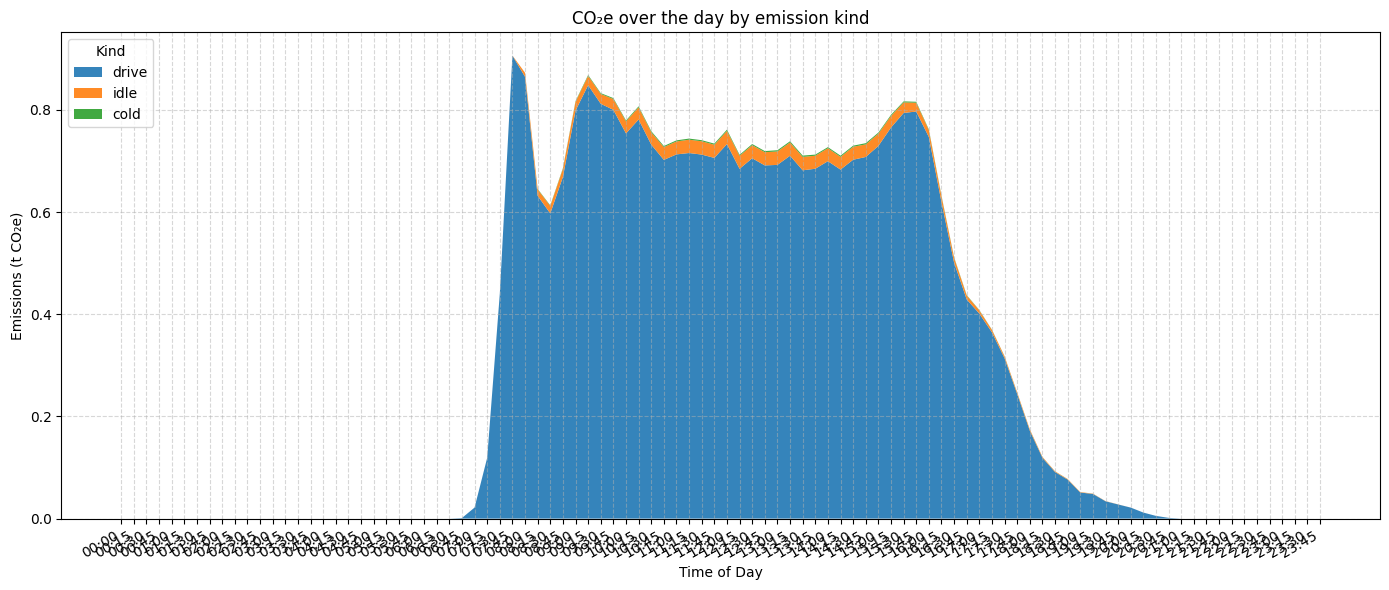

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\344709216.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shares = shares.div(row_sums, axis=0).fillna(0.0)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\344709216.py:78: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis="x", nbins=12)


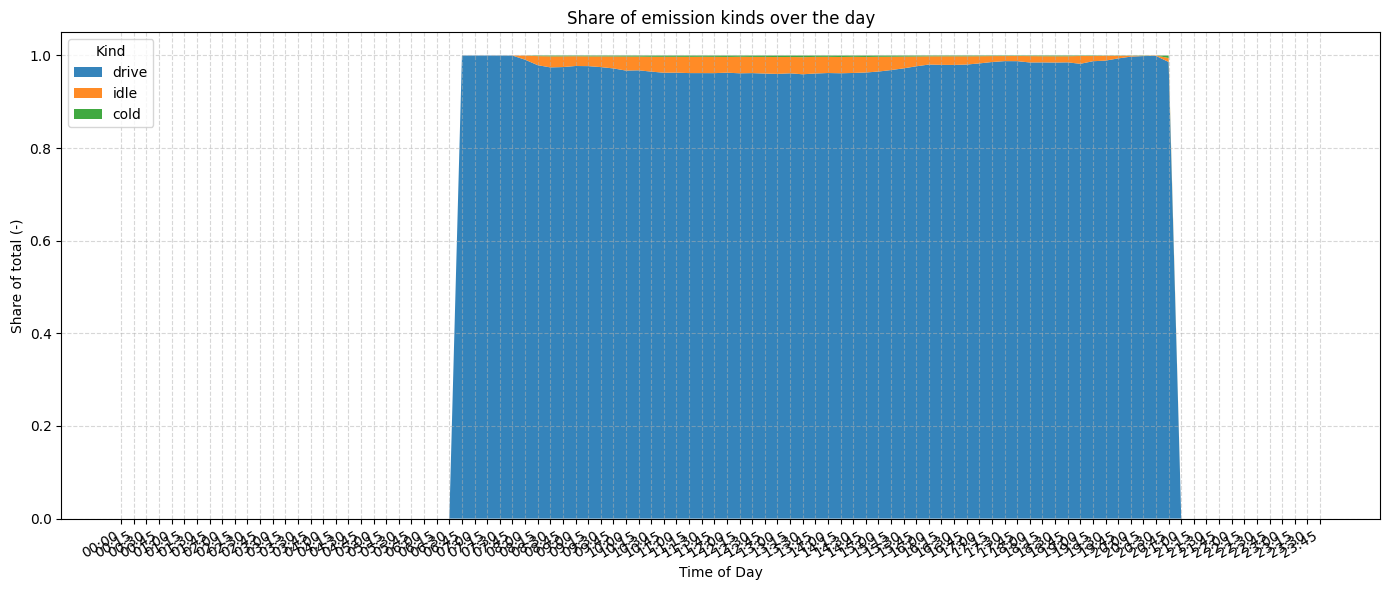

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Build time series by emission kind (drive, idle, cold)
# Input structure assumed:
#   emissions_dict[veh_size][link_id][HH:MM] = {"drive": g, "idle": g, "cold": g, "total": g}
# Output:
#   df_kinds: index = sorted time labels (HH:MM), columns = ["drive","idle","cold"], values = grams
# ----------------------------------------------------------

def timeseries_by_kind(emissions_dict, kinds=("drive", "idle", "cold")):
    # collect all time bins that exist anywhere
    all_times = set()
    for vsize in emissions_dict.values():
        for link in vsize.values():
            all_times.update(link.keys())
    # sort HH:MM chronologically
    def _to_minutes(hhmm):
        h, m = map(int, hhmm.split(":"))
        return h * 60 + m
    time_bins = sorted(all_times, key=_to_minutes)

    # aggregate grams over all vehicle sizes and links per time and kind
    data = {k: [0.0] * len(time_bins) for k in kinds}
    idx_map = {t: i for i, t in enumerate(time_bins)}

    for vsize in emissions_dict.values():
        for link in vsize.values():
            for hhmm, payload in link.items():
                i = idx_map[hhmm]
                for k in kinds:
                    data[k][i] += float(payload.get(k, 0.0))

    df = pd.DataFrame(data, index=time_bins)
    return df

df_kinds = timeseries_by_kind(emissions_dict, kinds=("drive","idle","cold"))

# Optional: convert to tonnes for plotting
df_kinds_t = df_kinds / 1_000_000

# ----------------------------------------------------------
# 1) Stacked area plot (absolute emissions by kind over time)
# ----------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_kinds_t.index,
    [df_kinds_t["drive"].values, df_kinds_t["idle"].values, df_kinds_t["cold"].values],
    labels=["drive", "idle", "cold"],
    alpha=0.9
)
plt.xticks(rotation=30, ha="right")
plt.locator_params(axis="x", nbins=12)  # reduce label clutter
plt.xlabel("Time of Day")
plt.ylabel("Emissions (t CO₂e)")
plt.title("CO₂e over the day by emission kind")
plt.legend(loc="upper left", title="Kind")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 2) Optional: 100 percent stacked area (shares per kind)
# ----------------------------------------------------------
shares = df_kinds.copy()
row_sums = shares.sum(axis=1).replace(0, pd.NA)
shares = shares.div(row_sums, axis=0).fillna(0.0)

plt.figure(figsize=(14, 6))
plt.stackplot(
    shares.index,
    [shares["drive"].values, shares["idle"].values, shares["cold"].values],
    labels=["drive", "idle", "cold"],
    alpha=0.9
)
plt.xticks(rotation=30, ha="right")
plt.locator_params(axis="x", nbins=12)
plt.xlabel("Time of Day")
plt.ylabel("Share of total (-)")
plt.title("Share of emission kinds over the day")
plt.legend(loc="upper left", title="Kind")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\2121874409.py:16: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis="x", nbins=12)


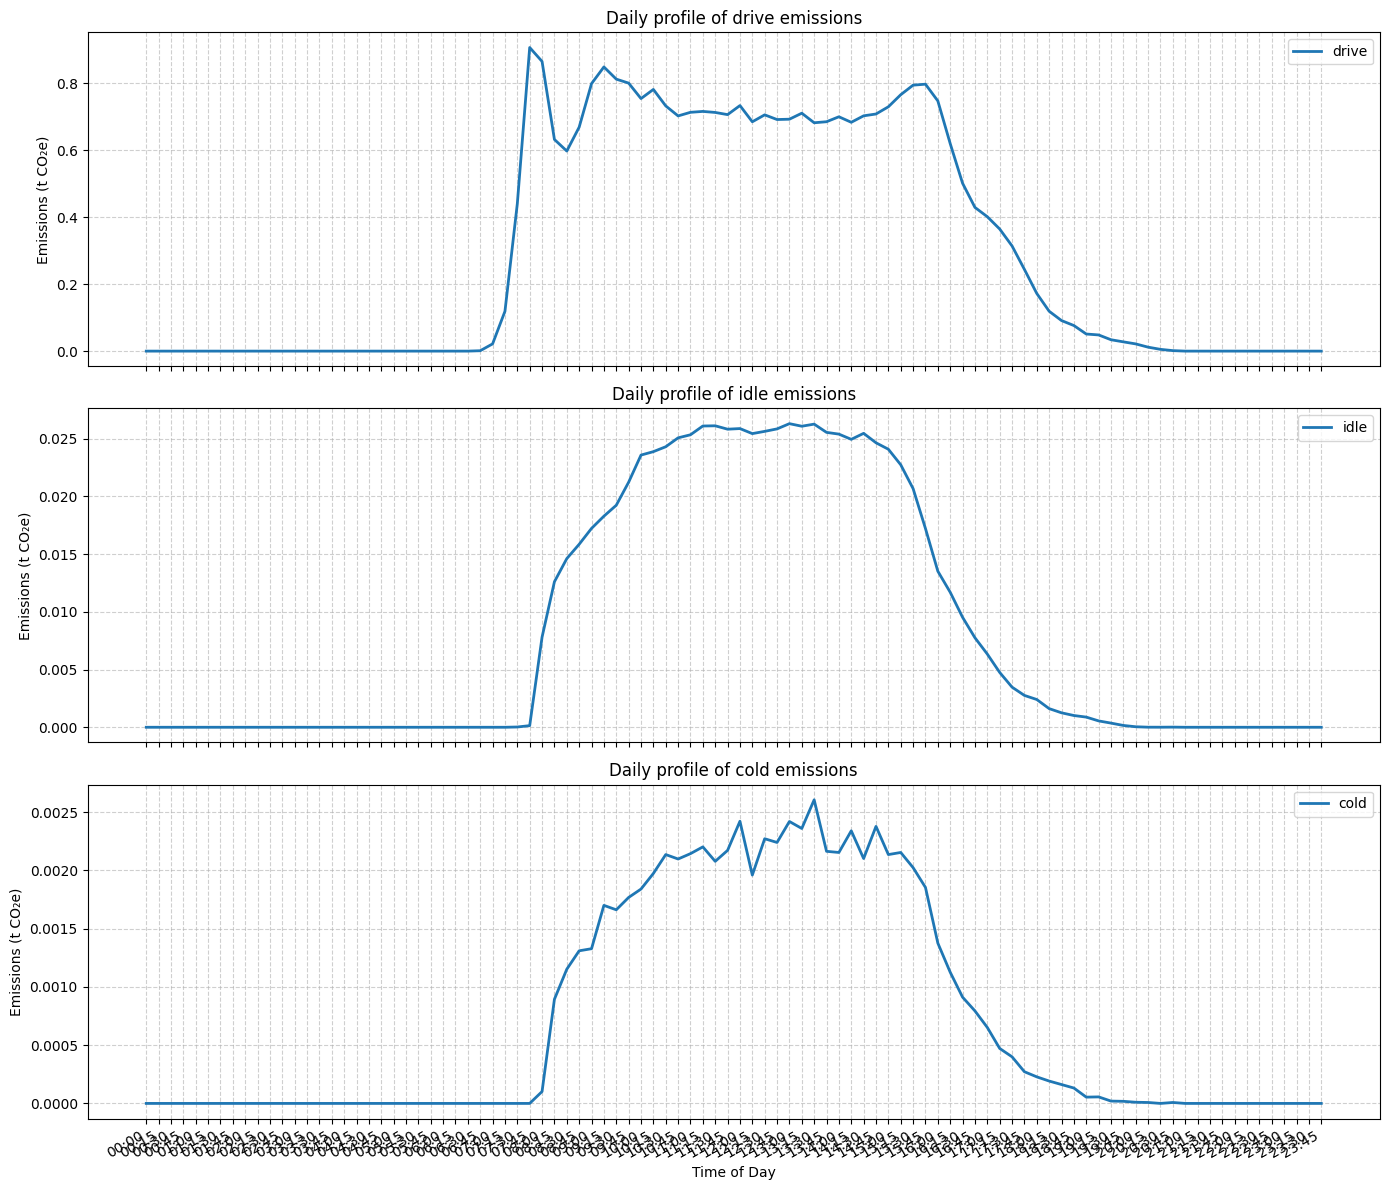

In [22]:
import matplotlib.pyplot as plt

# DataFrame df_kinds_t already prepared: index = time, columns = ["drive","idle","cold"] in tonnes

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, kind in zip(axes, ["drive", "idle", "cold"]):
    ax.plot(df_kinds_t.index, df_kinds_t[kind], label=kind, linewidth=2)
    ax.set_ylabel("Emissions (t CO₂e)")
    ax.set_title(f"Daily profile of {kind} emissions")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="upper right")

# format x-axis
plt.xticks(rotation=30, ha="right")
plt.locator_params(axis="x", nbins=12)

axes[-1].set_xlabel("Time of Day")

plt.tight_layout()
plt.show()


In [23]:
import pandas as pd

# Annahmen:
# - emissions_15min_long hat Spalten: link_id, interval_15min, emissions_g
# - link_raumtyp: dict {link_id: area_type_id_oder_name}
# Optional:
# - area_type_label: dict {area_type_id: "Metropolitan Center", ...} falls du IDs auf Namen mappen willst

# 1) Area Type an die 15-Minuten-Daten hängen
emissions_15min_long['area_type_id'] = emissions_15min_long['link_id'].map(link_raumtyp)

# Optional lesbarer Name
if 'area_type_label' in globals() and isinstance(area_type_label, dict):
    emissions_15min_long['area_type'] = emissions_15min_long['area_type_id'].map(area_type_label)
else:
    # Falls keine Label Map vorliegt: nimm die ID als Name, ersetze fehlende durch "Unknown"
    emissions_15min_long['area_type'] = emissions_15min_long['area_type_id'].fillna('Unknown')

# 2) Merge mit Netzgeometrie beibehalten, jetzt inklusive area_type
merged_15min = pd.merge(
    network_volumes_filtered,
    emissions_15min_long,
    on='link_id',
    how='left'
)

# 3) Netzsummen je 15-Minuten-Intervall UND Raumtyp
network_15min_by_area = (
    emissions_15min_long
    .groupby(['interval_15min', 'area_type'], as_index=False)['emissions_g']
    .sum()
    .rename(columns={'emissions_g': 'emissions_g_sum'})
)
network_15min_by_area['emissions_kg_sum'] = network_15min_by_area['emissions_g_sum'] / 1000.0

# 4) Optional: Pivot für einfache Plots oder Export
network_15min_pivot = network_15min_by_area.pivot(
    index='interval_15min',
    columns='area_type',
    values='emissions_kg_sum'
).reindex(index=time_intervals).fillna(0.0)

# 5) Reporting Beispiele
print("\nBeispiel je Link, Intervall und Area Type:")
print(emissions_15min_long[['link_id', 'interval_15min', 'area_type', 'emissions_g']].head())

print("\nNetzweite Summen je 15-Minuten-Intervall und Area Type:")
print(network_15min_by_area.head())

print("\nPivot je Intervall und Area Type in kg:")
print(network_15min_pivot.head())



Beispiel je Link, Intervall und Area Type:
         link_id interval_15min area_type  emissions_g
0         100000          00:00       4.0          0.0
1  100001-192714          00:00       4.0          0.0
2         100003          00:00       7.0          0.0
3         100004          00:00       7.0          0.0
4         100005          00:00       7.0          0.0

Netzweite Summen je 15-Minuten-Intervall und Area Type:
  interval_15min area_type  emissions_g_sum  emissions_kg_sum
0          00:00       1.0              0.0               0.0
1          00:00       2.0              0.0               0.0
2          00:00       3.0              0.0               0.0
3          00:00       4.0              0.0               0.0
4          00:00       5.0              0.0               0.0

Pivot je Intervall und Area Type in kg:
area_type       1.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0  Unknown
interval_15min                                                 
00:00           0.0  0.0  0.

In [24]:
# Reset to default (same as after import seaborn as sns)
sns.reset_defaults()

sns.set_theme()  # optional, aktiviert Standardtheme
sns.reset_defaults()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\3749878799.py:93: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\3749878799.py:93: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


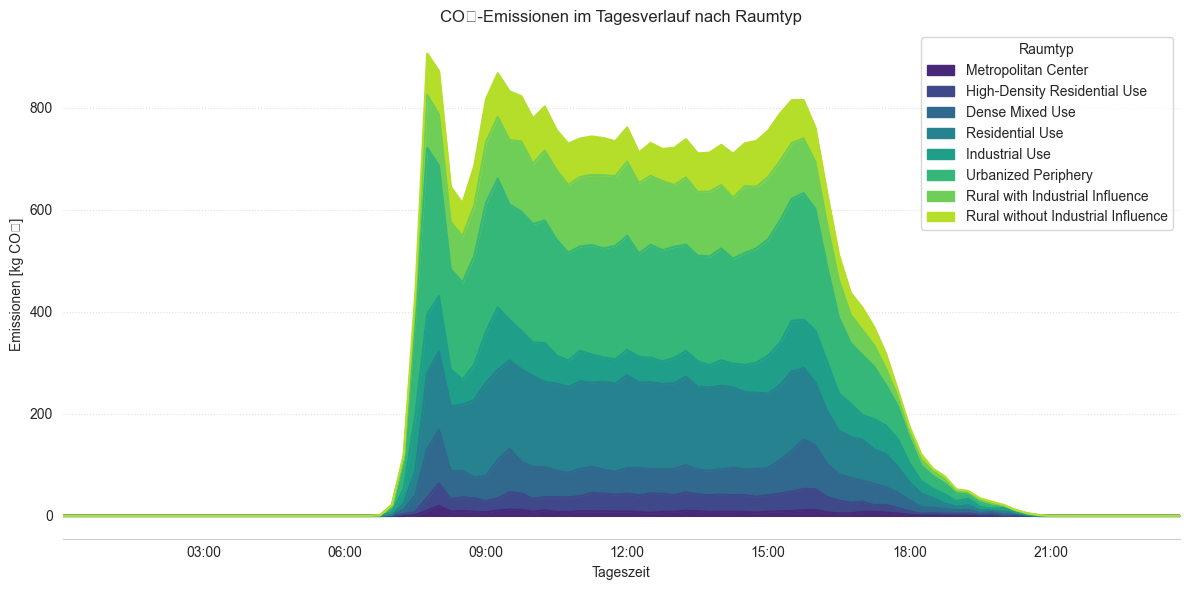

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Zielreihenfolge und Farben
ordered_names = [
    "Metropolitan Center",
    "High-Density Residential Use",
    "Dense Mixed Use",
    "Residential Use",
    "Industrial Use",
    "Urbanized Periphery",
    "Rural with Industrial Influence",
    "Rural without Industrial Influence"
]
category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b"
}

# Mapping, das auch float- und int-Keys akzeptiert
cat_map_num_to_name = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence"
}

def map_col_to_name(col):
    # ints, floats, strings robust abdecken
    try:
        # erst versuchen, in int zu casten (1.0 -> 1)
        k = int(float(col))
        return cat_map_num_to_name.get(k, col)
    except Exception:
        return col

# 1) Spaltennamen mappen
rename_map = {col: map_col_to_name(col) for col in network_15min_pivot.columns}
network_15min_pivot = network_15min_pivot.rename(columns=rename_map)

# 2) Nur die 8 bekannten Kategorien behalten, Unknown verwerfen
cols_present = [c for c in ordered_names if c in network_15min_pivot.columns]
plot_df = network_15min_pivot[cols_present].copy()

if plot_df.shape[1] == 0:
    raise ValueError(
        "Keine der 8 Zielkategorien nach dem Mapping vorhanden. Vorhandene Spalten: "
        f"{list(network_15min_pivot.columns)}"
    )

# 3) Werte numerisch erzwingen
plot_df = plot_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# 4) Zeitindex als HH:MM interpretieren und sortieren, falls möglich
try:
    dt_index = pd.to_datetime(plot_df.index, format="%H:%M")
    plot_df = plot_df.set_index(dt_index).sort_index()
except Exception:
    pass  # falls der Index bereits datetime ist oder anderes Format hat

# 5) Farben in Spaltenreihenfolge
name_to_color = {ordered_names[i]: category_color_dict_num[i] for i in range(len(ordered_names))}
colors = [name_to_color[c] for c in plot_df.columns]

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot.area(ax=ax, color=colors, stacked=True)

ax.set_title("CO₂-Emissionen im Tagesverlauf nach Raumtyp")
ax.set_xlabel("Tageszeit")
ax.set_ylabel("Emissionen [kg CO₂]")
ax.legend(title="Raumtyp", loc="upper right")

# X-Achse als Uhrzeit formatieren
try:
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
except Exception:
    pass

plt.tight_layout()
plt.show()


In [26]:
import numpy as np

result['emissions_total'] = result['emissions'].map(
    lambda d: float(d.get('total', 0.0)) if isinstance(d, dict) else float(d or 0.0)
)

# 2) CO2 per package (grams & kg) with divide-by-zero guard
den = result['deliveries'].fillna(0).to_numpy()
num_total = result['emissions_total'].fillna(0).to_numpy()

result['co2_per_pkg_g']  = np.divide(num_total, den, out=np.zeros_like(num_total, dtype=float), where=den>0)
result['co2_per_pkg_kg'] = result['co2_per_pkg_g'] / 1000.0



In [27]:
result["co2_per_pkg_g"].mean()

np.float64(154.7722274792446)

In [205]:
import numpy as np
import matplotlib.pyplot as plt

# ================
# Robust input
# ================
if "start_time" in result.columns:
    start_col = "start_time"
elif "Start time formatted" in result.columns:
    start_col = "Start time formatted"
else:
    raise KeyError("No start time column found")

if "end_time" in result.columns:
    end_col = "end_time"
elif "End time formatted" in result.columns:
    end_col = "End time formatted"
else:
    raise KeyError("No end time column found")

df = result.copy()
df[start_col] = pd.to_datetime(df[start_col], errors="coerce")
df[end_col]   = pd.to_datetime(df[end_col],   errors="coerce")

# Startzeit (wie bisher schon bei dir definiert)
df["tod_min"]  = df[start_col].dt.hour * 60 + df[start_col].dt.minute
df["tod_hour"] = df["tod_min"] / 60.0

# Endzeit analog, aber eigene Spalten
df["end_min"]  = df[end_col].dt.hour * 60 + df[end_col].dt.minute
df["end_hour"] = df["end_min"] / 60.0

# Bereiche nach Häufigkeit sortieren
areas = df["main_area_type_name"].value_counts().index.tolist()

<Figure size 800x500 with 0 Axes>

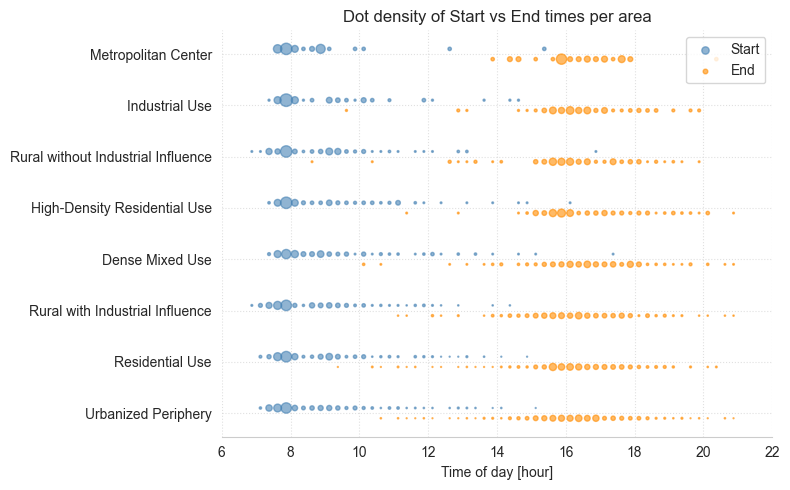

In [206]:
# ================
# Dot density Plot
# ================
bins = np.arange(0, 24*60+1, 15)   # 15-Minuten-Bins
x_cent = (bins[:-1] + bins[1:]) / 2.0
offset = 0.1   # Abstand zwischen Start und End pro Area

plt.figure(figsize=(8, 5))

for i, a in enumerate(areas):
    # Startzeiten
    m_start = df.loc[df["main_area_type_name"] == a, "tod_min"].dropna().to_numpy()
    hist_s, _ = np.histogram(m_start, bins=bins)
    frac_s = hist_s / hist_s.sum() if hist_s.sum() > 0 else hist_s
    sizes_s = 220 * frac_s
    plt.scatter(x_cent/60.0, np.full_like(x_cent, i+offset, dtype=float),
                s=sizes_s, alpha=0.6, color="steelblue", label="Start" if i==0 else None)

    # Endzeiten
    m_end = df.loc[df["main_area_type_name"] == a, "end_min"].dropna().to_numpy()
    hist_e, _ = np.histogram(m_end, bins=bins)
    frac_e = hist_e / hist_e.sum() if hist_e.sum() > 0 else hist_e
    sizes_e = 220 * frac_e
    plt.scatter(x_cent/60.0, np.full_like(x_cent, i-offset, dtype=float),
                s=sizes_e, alpha=0.6, color="darkorange", label="End" if i==0 else None)

# Achsen und Labels
plt.yticks(range(len(areas)), areas)
plt.xlim(6, 22)
plt.xlabel("Time of day [hour]")
plt.title("Dot density of Start vs End times per area")
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Common prep on `result` ----------
if "start_time" in result.columns:
    time_col = "start_time"
elif "Start time formatted" in result.columns:
    time_col = "Start time formatted"
else:
    raise KeyError("No start time column found in result")

df = result.copy()
df[time_col] = pd.to_datetime(df[time_col])

# Time of day in hours [0..24)
df["tod_hour"] = df[time_col].dt.hour + df[time_col].dt.minute / 60.0 + df[time_col].dt.second / 3600.0

# Order areas by frequency
areas = df["main_area_type_name"].value_counts().index.tolist()

# Binning helpers
def hist_by_area(hours, bins):
    counts, _ = np.histogram(hours, bins=bins)
    return counts

def smooth_counts(counts, sigma=1.0):
    """Simple Gaussian smoothing without scipy."""
    if sigma <= 0:
        return counts.astype(float)
    wlen = int(6 * sigma) + 1
    x = np.arange(wlen) - wlen // 2
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= kernel.sum()
    return np.convolve(counts, kernel, mode="same")

# Uniform bins for 24h
bins_h = np.linspace(0, 24, 97)  # 15 min
centers_h = (bins_h[:-1] + bins_h[1:]) / 2.0


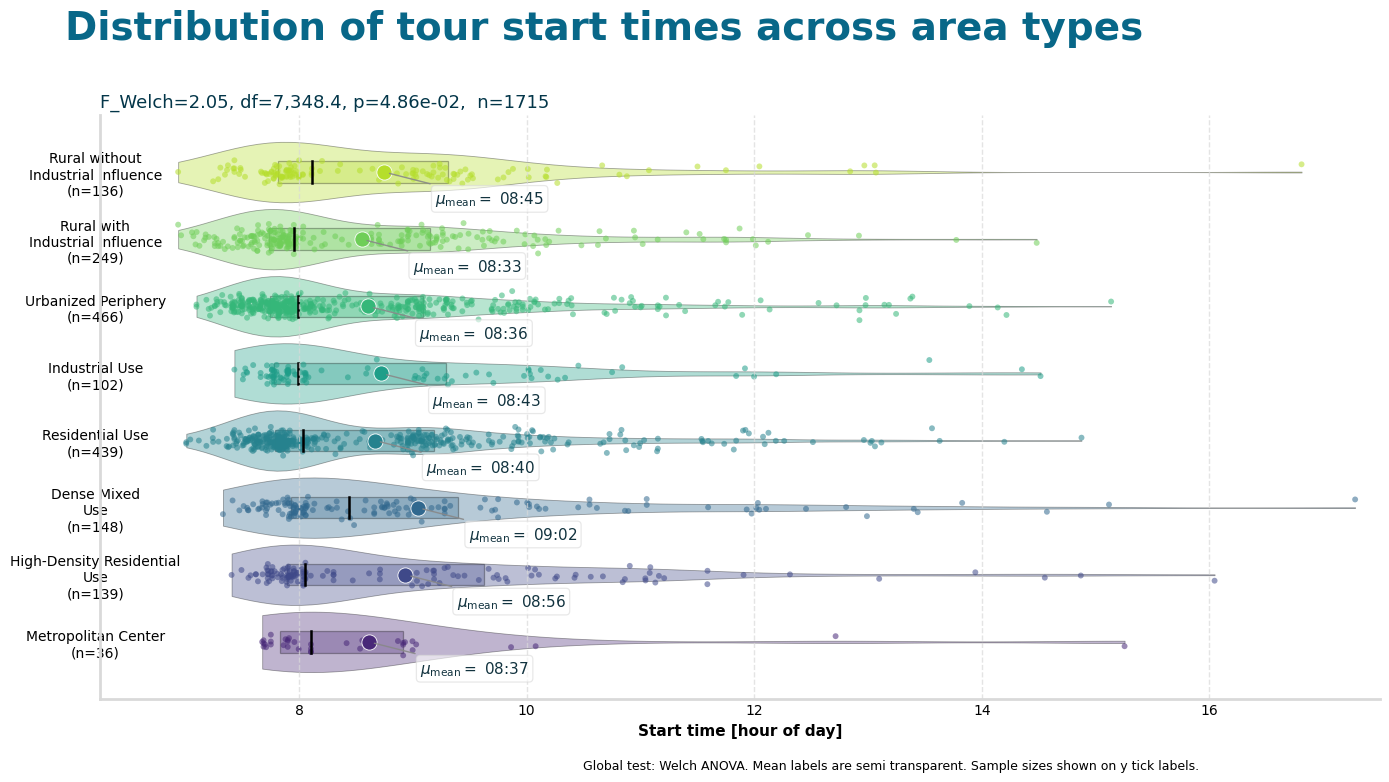

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================
# Input prep on `result`
# =========================
if "start_time" in result.columns:
    time_col = "start_time"
elif "Start time formatted" in result.columns:
    time_col = "Start time formatted"
else:
    raise KeyError("No start time column found in `result`")

df = result.copy()
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col, "main_area_type_name"]).copy()

# Time of day in hours (x axis data)
df["tod_hour"] = (
    df[time_col].dt.hour
    + df[time_col].dt.minute / 60.0
    + df[time_col].dt.second / 3600.0
)

# =========================
# Color and category mapping
# =========================
category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b",
}

cat_map_num_to_name = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence",
}

# Build a clean name column regardless of numeric or string inputs
if np.issubdtype(df["main_area_type_name"].dtype, np.number):
    df["area_name"] = df["main_area_type_name"].map(lambda v: cat_map_num_to_name.get(int(v), str(v)))
else:
    df["area_name"] = df["main_area_type_name"].astype(str)

# Name -> numeric id -> color
name_to_num = {v: k for k, v in cat_map_num_to_name.items()}
name_to_color = {}
for name, num in name_to_num.items():
    idx = max(0, min(num - 1, 7))  # map 1..8 to 0..7 safely
    name_to_color[name] = category_color_dict_num[idx]

# =========================
# Fixed order on the y axis
# =========================
order_nums = list(cat_map_num_to_name.keys())  # [1..8]
ordered_areas = [cat_map_num_to_name[num] for num in order_nums]
areas = [a for a in ordered_areas if a in df["area_name"].unique()]

# Data arrays and colors aligned to fixed order
x_data_per_group = [df.loc[df["area_name"] == a, "tod_hour"].to_numpy(dtype=float) for a in areas]
colors = [name_to_color.get(a, "#999999") for a in areas]

# =========================
# Label wrapping helper
# =========================
def wrap_words(name, max_words=2):
    words = name.split()
    lines = []
    line = []
    for w in words:
        line.append(w)
        if len(line) >= max_words:
            lines.append(" ".join(line))
            line = []
    if line:
        lines.append(" ".join(line))
    return "\n".join(lines)

# y tick labels with wrapped names and sample sizes
y_tick_labels = [wrap_words(a, max_words=2) + f"\n(n={len(x_data_per_group[i])})"
                 for i, a in enumerate(areas)]

def hours_to_hhmm(hour_val: float) -> str:
    """Convert decimal hour to HH:MM format string."""
    h = int(hour_val)
    m = int(round((hour_val - h) * 60))
    if m == 60:
        h = (h + 1) % 24
        m = 0
    return f"{h:02d}:{m:02d}"

# =========================
# Statistics helpers
# =========================
def welch_anova(groups):
    """
    Welch ANOVA F*, df1, df2, p value.
    Uses scipy.stats for F CDF if available, else returns p as NaN.
    """
    groups = [np.asarray(g, dtype=float) for g in groups if np.asarray(g).size > 1]
    k = len(groups)
    if k < 2:
        return np.nan, np.nan, np.nan, np.nan

    n = np.array([g.size for g in groups], dtype=float)
    means = np.array([g.mean() for g in groups], dtype=float)
    vars_ = np.array([g.var(ddof=1) for g in groups], dtype=float)
    vars_ = np.where(vars_ <= 0.0, 1e-12, vars_)  # guard

    w = n / vars_
    w_sum = np.sum(w)
    mean_w = np.sum(w * means) / w_sum

    df1 = k - 1
    A = np.sum(w * (means - mean_w) ** 2) / df1
    B = 1.0 + (2.0 * (k - 2.0) / (k**2 - 1.0)) * np.sum(((1.0 / (n - 1.0)) * (1.0 - (w / w_sum)) ** 2))
    Fstar = A / B

    df2 = (k**2 - 1.0) / (3.0 * np.sum(((1.0 / (n - 1.0)) * (1.0 - (w / w_sum)) ** 2)))
    if not np.isfinite(df2) or df2 <= 0:
        df2 = np.nan

    p = np.nan
    try:
        from scipy.stats import f as f_dist
        if np.isfinite(Fstar) and np.isfinite(df1) and np.isfinite(df2) and df1 > 0 and df2 > 0:
            p = float(1.0 - f_dist.cdf(Fstar, df1, df2))
    except Exception:
        p = np.nan

    return float(Fstar), float(df1), float(df2), p

# Global Welch ANOVA
Fval, df1, df2, p_welch = welch_anova(x_data_per_group)

# =========================
# Plot (horizontal violins)
# =========================
fig, ax = plt.subplots(figsize=(14, 8))
positions = np.arange(len(x_data_per_group))
violin_thickness = 0.9
box_height = 0.32

# Horizontal violins
vp = ax.violinplot(
    x_data_per_group,
    positions=positions,
    widths=violin_thickness,
    vert=False,
    showmeans=False,
    showextrema=False,
    showmedians=False
)
for body, c in zip(vp["bodies"], colors):
    body.set_facecolor(c)
    body.set_edgecolor("black")
    body.set_linewidth(0.6)
    body.set_alpha(0.35)

# IQR boxes and median lines (horizontal)
for yi, xvals, c in zip(positions, x_data_per_group, colors):
    if xvals.size == 0:
        continue
    q1, q2, q3 = np.percentile(xvals, [25, 50, 75])
    ax.add_patch(Rectangle(
        (q1, yi - box_height/2.0),
        q3 - q1, box_height,
        facecolor=c, alpha=0.30,
        edgecolor="black", linewidth=0.9, zorder=1
    ))
    ax.plot([q2, q2], [yi - box_height/2.0, yi + box_height/2.0],
            color="black", linewidth=1.8, zorder=2)

# Scatter points with small vertical jitter, in area color
rng = np.random.default_rng(7)
for yi, xvals, c in zip(positions, x_data_per_group, colors):
    if xvals.size == 0:
        continue
    jitter = rng.normal(0.0, 0.08, size=xvals.size)
    ax.scatter(xvals, np.full_like(xvals, yi, dtype=float) + jitter,
               s=18, alpha=0.55, color=c, edgecolors="none")

# Means as colored dots with semi transparent labels connected by a grey line
dx = 0.45   # shift right from mean value
dy = 0.40   # shift labels 0.4 units downward
for yi, xvals, c in zip(positions, x_data_per_group, colors):
    if xvals.size == 0:
        continue
    m = float(np.mean(xvals))
    mean_label = hours_to_hhmm(m)
    ax.scatter([m], [yi], s=120, zorder=6, color=c,
               edgecolors="white", linewidths=0.6)
    ax.annotate(
        r"$\mu_{\rm mean} =$ " + f"{mean_label}",
        xy=(m, yi),
        xytext=(m + dx, yi - dy),  # 0.4 downward
        ha="left", va="center",
        fontsize=11, color="#12333f",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#d9d9d9", lw=0.9, alpha=0.6),
        arrowprops=dict(arrowstyle="-", shrinkA=4, shrinkB=4, lw=1.0, color="#888888", alpha=0.9)
    )

# Grid and axes styling
for h in [8, 10, 12, 14, 16, 18]:  # no grid line at 6
    ax.axvline(h, color="#d9d9d9", linestyle="--", linewidth=1, alpha=0.7)
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#d9d9d9")
    ax.spines[side].set_linewidth(2)
ax.tick_params(length=0, labelsize=10)

# Y ticks with wrapped labels in fixed order
ax.set_yticks(positions)
ax.set_yticklabels(y_tick_labels, ha="center")

# X label and fixed limits 6..18
ax.set_xlabel("Start time [hour of day]", fontsize=11, weight="bold")
ax.set_xlim(6.25, 17.5)

# Title and subtitle with Welch ANOVA
subtitle = []
if np.isfinite(Fval):
    subtitle.append("F_Welch=" + f"{Fval:.2f}")
if np.isfinite(df1) and np.isfinite(df2):
    subtitle.append("df=" + f"{int(df1)},{df2:.1f}")
if p_welch == p_welch:
    subtitle.append("p=" + f"{p_welch:.2e}")
n_total = sum(len(x) for x in x_data_per_group)

fig.suptitle(
    "Distribution of tour start times across area types",
    x=0.05, y=0.98, ha="left", fontsize=28, color="#086788", weight="bold"
)
ax.set_title(", ".join(subtitle) + f",  n={n_total}",
             loc="left", fontsize=13, color="#033649")

# Bottom note
fig.text(
    0.42, 0.03,
    "Global test: Welch ANOVA. Mean labels are semi transparent. Sample sizes shown on y tick labels.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()


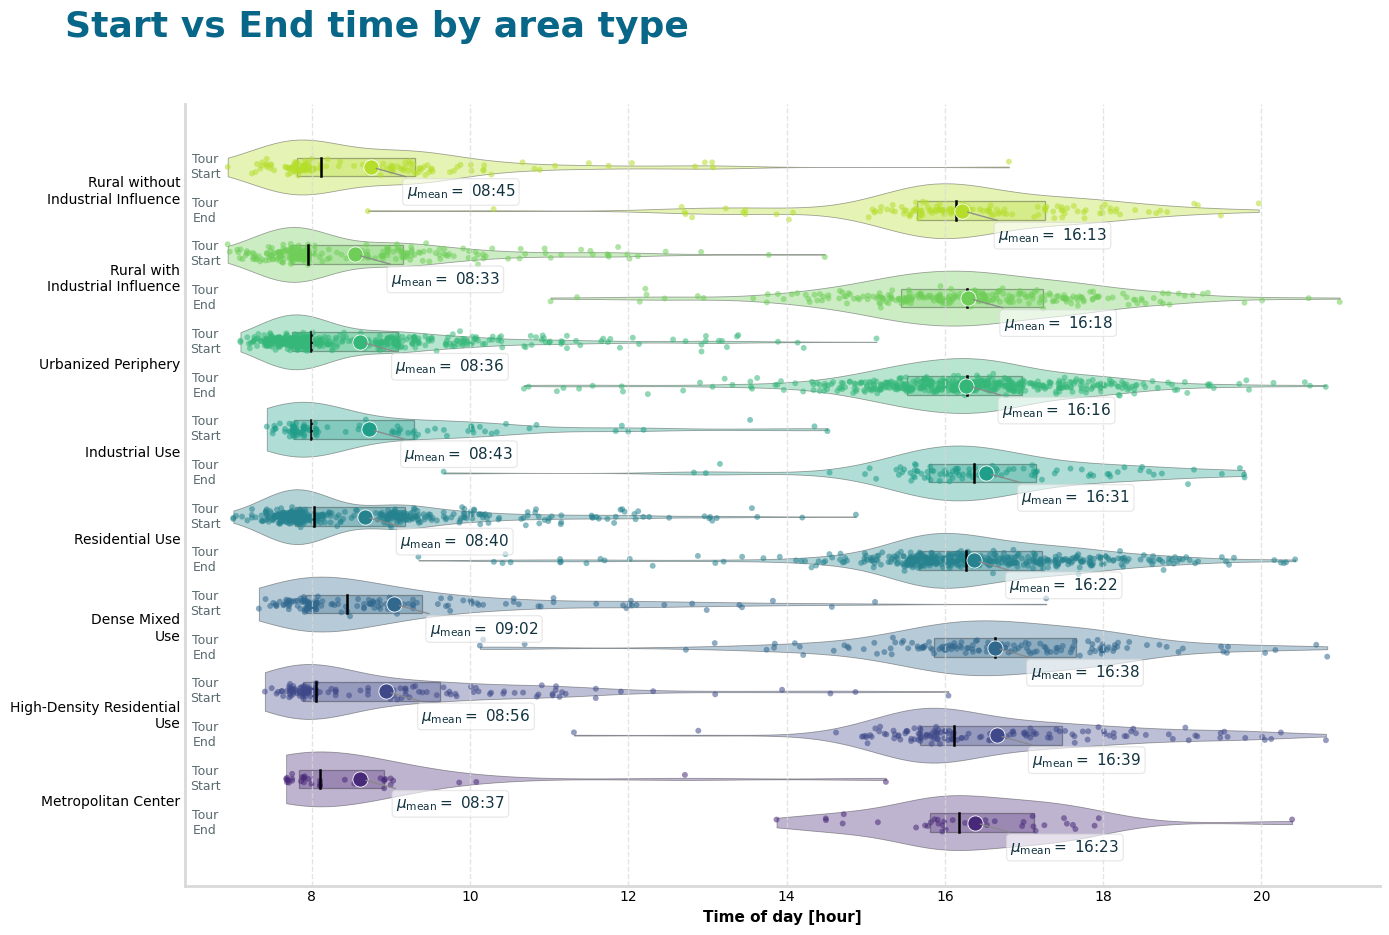

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================
# Robust input from `result`
# =========================
# Spalten finden
if "start_time" in result.columns:
    start_col = "start_time"
elif "Start time formatted" in result.columns:
    start_col = "Start time formatted"
else:
    raise KeyError("No start time column found")

if "end_time" in result.columns:
    end_col = "end_time"
elif "End time formatted" in result.columns:
    end_col = "End time formatted"
else:
    raise KeyError("No end time column found")

df = result.copy()
df[start_col] = pd.to_datetime(df[start_col], errors="coerce")
df[end_col]   = pd.to_datetime(df[end_col],   errors="coerce")
df = df.dropna(subset=[start_col, end_col, "main_area_type_name"]).copy()

# Zeit des Tages in Dezimalstunden
def to_hour(tser):
    return tser.dt.hour + tser.dt.minute/60.0 + tser.dt.second/3600.0

df["start_hour"] = to_hour(df[start_col])
df["end_hour"]   = to_hour(df[end_col])

# =========================
# Farben & Kategorien
# =========================
category_color_dict_num = {
    0: "#482878",
    1: "#3f4989",
    2: "#31688e",
    3: "#26828e",
    4: "#1f9e89",
    5: "#35b779",
    6: "#6fce58",
    7: "#b5de2b",
}
cat_map_num_to_name = {
    1: "Metropolitan Center",
    2: "High-Density Residential Use",
    3: "Dense Mixed Use",
    4: "Residential Use",
    5: "Industrial Use",
    6: "Urbanized Periphery",
    7: "Rural with Industrial Influence",
    8: "Rural without Industrial Influence",
}

# Einheitliche Namen bauen
if np.issubdtype(df["main_area_type_name"].dtype, np.number):
    df["area_name"] = df["main_area_type_name"].map(lambda v: cat_map_num_to_name.get(int(v), str(v)))
else:
    df["area_name"] = df["main_area_type_name"].astype(str)

# Name -> Nummer -> Farbe
name_to_num = {v: k for k, v in cat_map_num_to_name.items()}
name_to_color = {name: category_color_dict_num[max(0, min(num-1, 7))]
                 for name, num in name_to_num.items()}

# Feste Reihenfolge 1..8, nur vorhandene
ordered_areas = [cat_map_num_to_name[k] for k in cat_map_num_to_name.keys()]
areas = [a for a in ordered_areas if a in df["area_name"].unique()]
colors = [name_to_color.get(a, "#999999") for a in areas]

# Daten je Raumtyp
start_per_area = [df.loc[df["area_name"] == a, "start_hour"].to_numpy(float) for a in areas]
end_per_area   = [df.loc[df["area_name"] == a, "end_hour"].to_numpy(float)   for a in areas]

# =========================
# Helpers
# =========================
def hours_to_hhmm(x: float) -> str:
    h = int(x)
    m = int(round((x - h) * 60))
    if m == 60:
        h = (h + 1) % 24
        m = 0
    return f"{h:02d}:{m:02d}"

def wrap_words(name, max_words=2):
    words, lines, line = name.split(), [], []
    for w in words:
        line.append(w)
        if len(line) >= max_words:
            lines.append(" ".join(line)); line = []
    if line: lines.append(" ".join(line))
    return "\n".join(lines)

# =========================
# Y-Positionen: je Area zwei Reihen, aber nur EIN Tick in der Mitte
# =========================
gap = 1.4                  # Abstand zwischen Area-Blöcken
offset = 0.35              # Abstand Start/End innerhalb Block
center_pos = np.arange(len(areas)) * gap
pos_start  = center_pos + offset
pos_end    = center_pos - offset

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 10))
violin_thickness = 0.88
box_h = 0.30

# Start-Violins
vp_s = ax.violinplot(
    start_per_area,
    positions=pos_start,
    widths=violin_thickness,
    vert=False,
    showmeans=False, showextrema=False, showmedians=False
)
for body, c in zip(vp_s["bodies"], colors):
    body.set_facecolor(c); body.set_edgecolor("black"); body.set_linewidth(0.6); body.set_alpha(0.35)

# End-Violins
vp_e = ax.violinplot(
    end_per_area,
    positions=pos_end,
    widths=violin_thickness,
    vert=False,
    showmeans=False, showextrema=False, showmedians=False
)
for body, c in zip(vp_e["bodies"], colors):
    body.set_facecolor(c); body.set_edgecolor("black"); body.set_linewidth(0.6); body.set_alpha(0.35)

# IQR + Median für beide
def draw_iqr_median(x_arrays, positions, color_list):
    for yi, xvals, c in zip(positions, x_arrays, color_list):
        if xvals.size == 0: continue
        q1, q2, q3 = np.percentile(xvals, [25, 50, 75])
        ax.add_patch(Rectangle((q1, yi - box_h/2.0), q3 - q1, box_h,
                               facecolor=c, alpha=0.30, edgecolor="black", linewidth=0.9, zorder=1))
        ax.plot([q2, q2], [yi - box_h/2.0, yi + box_h/2.0], color="black", linewidth=1.8, zorder=2)

draw_iqr_median(start_per_area, pos_start, colors)
draw_iqr_median(end_per_area,   pos_end,   colors)

# Punkte
rng = np.random.default_rng(7)
def scatter_points(x_arrays, positions, color_list):
    for yi, xvals, c in zip(positions, x_arrays, color_list):
        if xvals.size == 0: continue
        jitter = rng.normal(0.0, 0.06, size=xvals.size)
        ax.scatter(xvals, np.full_like(xvals, yi, float) + jitter,
                   s=18, alpha=0.55, color=c, edgecolors="none")

scatter_points(start_per_area, pos_start, colors)
scatter_points(end_per_area,   pos_end,   colors)

# Means: farbiger Punkt + semi-transparente Box mit HH:MM
dx = 0.45
dy = 0.40
def annotate_means(x_arrays, positions, color_list):
    for yi, xvals, c in zip(positions, x_arrays, color_list):
        if xvals.size == 0: continue
        m = float(np.mean(xvals))
        ax.scatter([m], [yi], s=120, zorder=6, color=c, edgecolors="white", linewidths=0.6)
        ax.annotate(r"$\mu_{\rm mean} =$ " + hours_to_hhmm(m),
                    xy=(m, yi), xytext=(m + dx, yi - dy),
                    ha="left", va="center", fontsize=11, color="#12333f", zorder=10,
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#d9d9d9", lw=0.9, alpha=0.6),
                    arrowprops=dict(arrowstyle="-", shrinkA=4, shrinkB=4, lw=1.0,
                                    color="#888888", alpha=0.9))

annotate_means(start_per_area, pos_start, colors)
annotate_means(end_per_area,   pos_end,   colors)

# Vertikale Stundenlinien
for h in [8, 10, 12, 14, 16, 18, 20]:
    ax.axvline(h, color="#d9d9d9", linestyle="--", linewidth=1, alpha=0.7)

# Achsen-Optik
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
for side in ["left", "bottom"]:
    ax.spines[side].set_color("#d9d9d9"); ax.spines[side].set_linewidth(2)
ax.tick_params(length=0, labelsize=10)

# *** Nur EIN Y-Tick je Area, mittig zwischen Start/End ***
y_tick_labels = [wrap_words(a, 2) for a in areas]
ax.set_yticks(center_pos)
ax.set_yticklabels(y_tick_labels, ha="right")

# Kleine Seitenlabels "Start" / "End" links neben jedem Block
x_left = 6.65  # etwas links vom Plotbereich
for y in center_pos:
    ax.text(x_left, y + offset, "Tour\nStart", ha="center", va="center", fontsize=9, color="#5a6a6f")
    ax.text(x_left, y - offset, "Tour\nEnd",   ha="center", va="center", fontsize=9, color="#5a6a6f")

# X-Achse
ax.set_xlabel("Time of day [hour]", fontsize=11, weight="bold")
ax.set_xlim(6.4, 21.5)

# Titel
fig = plt.gcf()
fig.suptitle("Start vs End time by area type",
             x=0.05, y=0.98, ha="left", fontsize=26, color="#086788", weight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


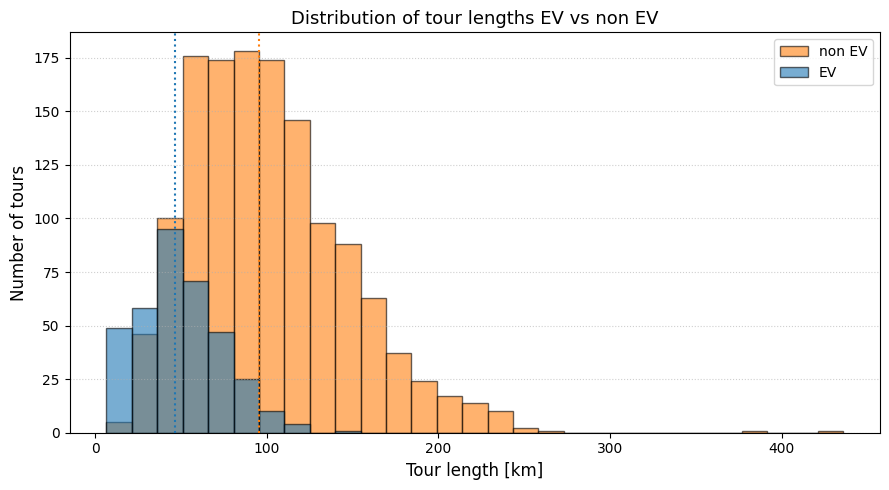

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Choose tour length column once
if "tour_km" in result.columns:
    length_col = "tour_km"
elif "tour_length_km" in result.columns:
    length_col = "tour_length_km"
else:
    raise KeyError("No tour length column found in result")

# Split EV vs non EV
ev_df = result[result["is_ev"] == True]
ice_df = result[result["is_ev"] == False]

# Drop NaN and non positive values for safety
ev_vals = ev_df[length_col].dropna().astype(float)
ice_vals = ice_df[length_col].dropna().astype(float)

ev_vals = ev_vals[ev_vals >= 0.0]
ice_vals = ice_vals[ice_vals >= 0.0]

# Build common bins for fair comparison
if len(ev_vals) and len(ice_vals):
    xmin = min(ev_vals.min(), ice_vals.min())
    xmax = max(ev_vals.max(), ice_vals.max())
elif len(ev_vals):
    xmin, xmax = ev_vals.min(), ev_vals.max()
elif len(ice_vals):
    xmin, xmax = ice_vals.min(), ice_vals.max()
else:
    raise ValueError("No tour length values available to plot")

bins = np.linspace(xmin, xmax, 30)

# Compute medians
ev_med = float(ev_vals.median()) if len(ev_vals) else np.nan
ice_med = float(ice_vals.median()) if len(ice_vals) else np.nan

# Plot overlay histogram
plt.figure(figsize=(9, 5))
plt.hist(ice_vals, bins=bins, alpha=0.6, label="non EV", color="tab:orange", edgecolor="black")
plt.hist(ev_vals,  bins=bins, alpha=0.6, label="EV",     color="tab:blue",   edgecolor="black")

# Median lines
if np.isfinite(ice_med):
    plt.axvline(ice_med, linestyle=":", linewidth=1.5, color="tab:orange")
if np.isfinite(ev_med):
    plt.axvline(ev_med, linestyle=":", linewidth=1.5, color="tab:blue")

# Labels
plt.xlabel("Tour length [km]", fontsize=12)
plt.ylabel("Number of tours", fontsize=12)
plt.title("Distribution of tour lengths EV vs non EV", fontsize=13)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
result["co2_per_pkg_g"].groupby(result["provider"]).mean()

provider
amazon    149.635732
dhl        53.008772
dpd       292.295320
fedex     205.162113
gls       266.920316
hermes    209.897866
ups       184.089445
Name: co2_per_pkg_g, dtype: float64

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1524523475.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax_top.plot(cum_window.index, cum_window.sum(axis=1),
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1524523475.py:77: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1524523475.py:77: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1524523475.py:77: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\bienzeisler\Docume

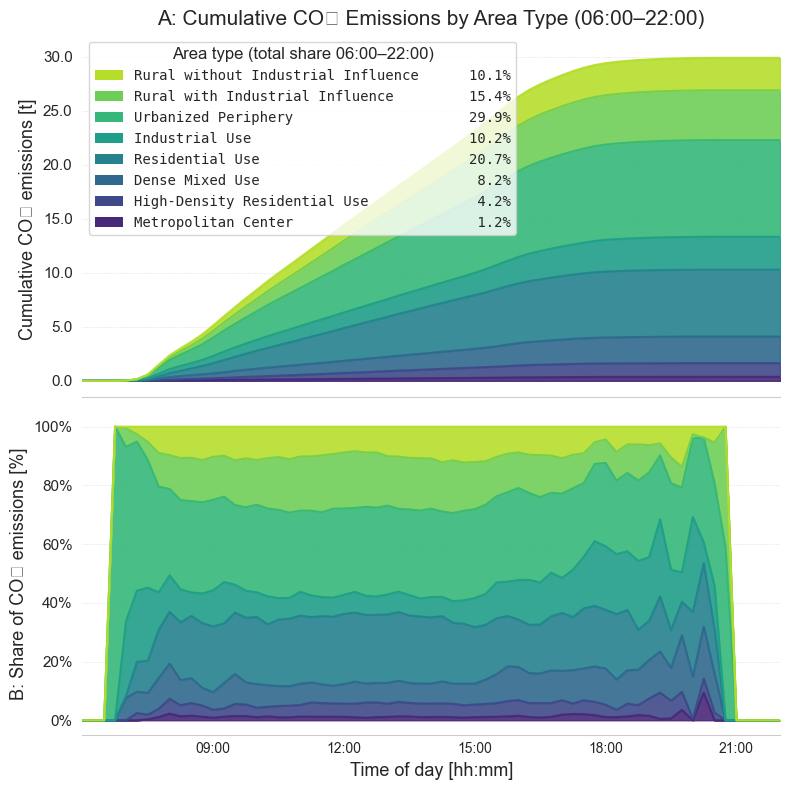

In [207]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
import pandas as pd
from matplotlib import transforms

# Assumptions:
# - plot_df: 15 min CO2 values per area type, index = DatetimeIndex (one day)
# - name_to_color: dict {area type: color} that covers all plot_df.columns
colors = [name_to_color[c] for c in plot_df.columns]

# 1) Derived frames
share_df = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0.0)
cum_df   = plot_df.cumsum()

# 2) Time windows
day0  = plot_df.index.normalize()[0]
start = day0 + pd.Timedelta(hours=6)
end   = day0 + pd.Timedelta(hours=22)

share_window = share_df.loc[start:end]
cum_window   = cum_df.loc[start:end]

# 3) Figure with two stacked subplots
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"height_ratios": [1.1, 1.0]}
)

# Top: cumulative emissions [kg] (displayed as tonnes)
cum_window.plot.area(ax=ax_top, stacked=True, color=colors, alpha=0.9, legend=False)
ax_top.plot(cum_window.index, cum_window.sum(axis=1),
            color="black", linewidth=1.6, label="Total cumulative")
# Show tonnes on the y-axis
ax_top.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/1000:,.1f}"))
ax_top.set_ylabel("Cumulative CO₂ emissions [t]", fontsize=13)
ax_top.set_title("A: Cumulative CO₂ Emissions by Area Type (06:00–22:00)", fontsize=15, pad=12)

# Bottom: shares [%] 06:00 to 22:00
share_window.plot.area(ax=ax_bottom, stacked=True, color=colors, alpha=0.9, legend=False)
ax_bottom.set_ylabel("B: Share of CO₂ emissions [%]", fontsize=13)
ax_bottom.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_bottom.set_xlabel("Time of day [hh:mm]", fontsize=13)

# X axis formatting
for ax in (ax_top, ax_bottom):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=11)

# --- Custom legend with total shares by 22:00 (full period) ---
end_vals = cum_window.iloc[-1]                         # cumulative by 22:00
total_end = end_vals.sum()
shares_end = (end_vals / total_end).fillna(0.0)

# Format legend labels: aligned percentages with 1 decimal (monospace + right-aligned)
maxlen = max(len(str(c)) for c in plot_df.columns)
patches = []
labels  = []
for col in reversed(plot_df.columns):  # REVERSED ORDER
    pct = shares_end.get(col, 0.0) * 100
    patches.append(mpatches.Patch(facecolor=name_to_color[col], edgecolor='none'))
    labels.append(f"{str(col).ljust(maxlen)}   {pct:>7.1f}%")  # width 7 fits up to 100.0%

# Monospaced legend for proper alignment (Windows-friendly fallbacks)
fp = FontProperties(family=['monospace'])
ax_top.legend(
    patches, labels,
    title="Area type (total share 06:00–22:00)",
    loc="upper left", bbox_to_anchor=(0.0, 1.02), ncol=1, frameon=True,
    prop=fp, fontsize=11, title_fontsize=12
)

plt.tight_layout()
# plt.savefig("area_type_emissions_TRB_ready.png", dpi=600, bbox_inches="tight")
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\76880659.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  share = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0).resample('30T').mean()


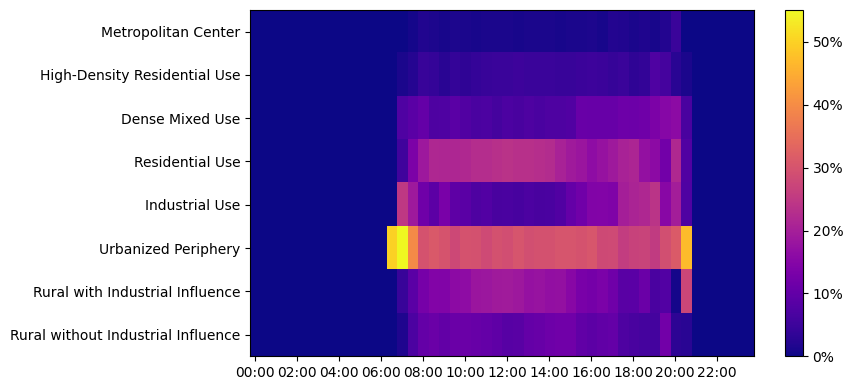

In [36]:
share = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0).resample('30T').mean()
hm = share.T  # Raumtyp als Zeilen
fig, ax = plt.subplots(figsize=(9,4))
im = ax.imshow(hm.values, aspect='auto', cmap='plasma', vmin=0, vmax=hm.values.max())
ax.set_yticks(range(len(hm.index))); ax.set_yticklabels(hm.index)
ax.set_xticks(range(0, len(hm.columns), 4)); ax.set_xticklabels(hm.columns[::4].strftime('%H:%M'), rotation=0)
cbar = plt.colorbar(im); cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plt.title('Share by area type over time')
plt.tight_layout()
plt.show()


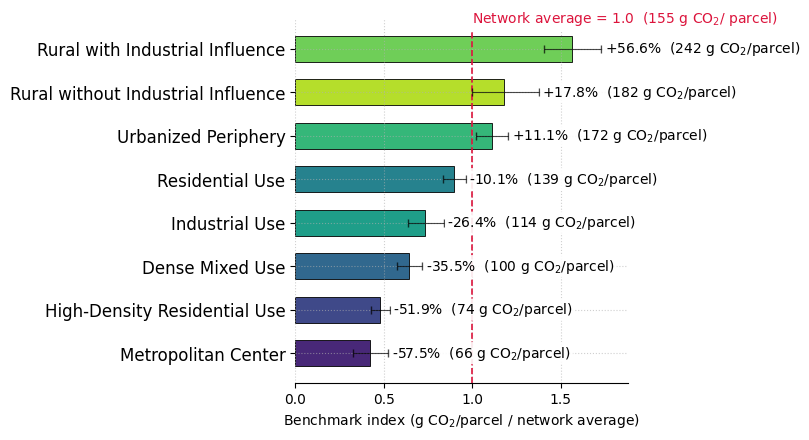

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==== Inputs ====
# result: DataFrame mit Spalten ["main_area_type_name", "co2_per_pkg_g"]
area_colors = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b",
}

# ==== Kennzahlen berechnen ====
mean_per_area = result.groupby("main_area_type_name")["co2_per_pkg_g"].mean()
overall_mean = result["co2_per_pkg_g"].mean()

# Benchmark Index
bench = (mean_per_area / overall_mean).sort_values()
areas_ordered = bench.index.tolist()
colors = [area_colors.get(a, "#999999") for a in areas_ordered]

# ==== 95% CI via Bootstrap ====
def bootstrap_ci(x, n_boot=20000, alpha=0.05, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    samples = rng.choice(x.values, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.quantile(samples, [alpha / 2.0, 1.0 - alpha / 2.0])
    return lo, hi

ci_lo, ci_hi = [], []
for a in areas_ordered:
    lo, hi = bootstrap_ci(result.loc[result["main_area_type_name"] == a, "co2_per_pkg_g"])
    ci_lo.append(lo / overall_mean)
    ci_hi.append(hi / overall_mean)

ci_lo = np.array(ci_lo)
ci_hi = np.array(ci_hi)

# ==== Plot Stil ====
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.grid": True,
    "grid.linestyle": ":", "grid.alpha": 0.6
})

fig, ax = plt.subplots(figsize=(8, 4.5))

y = np.arange(len(bench))
bars = ax.barh(y, bench.values, color=colors, edgecolor="black", linewidth=0.6, height=0.6)

# Fehlerbalken
err_left  = bench.values - ci_lo
err_right = ci_hi - bench.values
# Sicherheitshalber negative Rundungsreste auf null kappen
err_left = np.clip(err_left, 0, None)
err_right = np.clip(err_right, 0, None)

ax.errorbar(
    bench.values, y,
    xerr=[err_left, err_right],
    fmt="none", ecolor="black", elinewidth=0.8, capsize=3, alpha=0.7, zorder=3
)

# Vertikale Referenzlinie und Label
ax.axvline(1.0, color="crimson", linestyle="--", linewidth=1.2)
ax.text(
    1.0, len(bench) - 0.1,
    f"Network average = 1.0  ({overall_mean:.0f} g CO$_2$/ parcel)",
    color="crimson", fontsize=10, va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=1)
)

# Achsen
ax.set_yticks(y)
ax.set_yticklabels(areas_ordered)
ax.set_xlabel("Benchmark index (g CO$_2$/parcel / network average)", size=10)

# Labels am Balkenende
for i, (yi, val, area) in enumerate(zip(y, bench.values, areas_ordered)):
    pct = (val - 1.0) * 100.0
    abs_g = mean_per_area.loc[area]
    label = f"{pct:+.1f}%  ({abs_g:.0f} g CO$_2$/parcel)"
    x_text = ci_hi[i] + 0.02
    ax.text(
        x_text, yi, label, va="center", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9)
    )

# X Limits
xmin = 0
xmax = max(ci_hi.max() + 0.15, bench.values.max() + 0.15)
ax.set_xlim(xmin, xmax)

ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("area_type_benchmarking.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [148]:
plotWithoutEV = result[result["is_ev"] == 1]
plotWithoutEV

,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,emissions_total,co2_per_pkg_g,co2_per_pkg_kg,Cost per Parcel [€/parcel],b2b_deliveries,b2c_deliveries,cost_b2b_total,cost_b2c_total,Cost per B2B Parcel [€/parcel],Cost per B2C Parcel [€/parcel]
212,freight_hermes_30966_veh_cep_size_m_7_4,27403,37477,10074,2882,7192,1970-01-01 07:36:43,1970-01-01 10:24:37,1970-01-01 02:47:54,1970-01-01 00:48:02,...,0.0,0.0,0.0,8.334585,1.0,22.0,8.334585,183.360867,8.334585,8.334585
222,freight_dhl_31311_1_veh_cep_size_m_7_3,27477,52825,25348,15325,10023,1970-01-01 07:37:57,1970-01-01 14:40:25,1970-01-01 07:02:28,1970-01-01 04:15:25,...,0.0,0.0,0.0,1.640185,15.0,107.0,24.602769,175.499749,1.640185,1.640185
224,freight_dhl_31311_1_veh_cep_size_m_7_2,27477,55038,27561,15280,12281,1970-01-01 07:37:57,1970-01-01 15:17:18,1970-01-01 07:39:21,1970-01-01 04:14:40,...,0.0,0.0,0.0,1.706940,9.0,114.0,15.362464,194.591213,1.706940,1.706940
302,freight_dhl_30453_veh_cep_size_l_7_8,27764,55659,27895,19812,8083,1970-01-01 07:42:44,1970-01-01 15:27:39,1970-01-01 07:44:55,1970-01-01 05:30:12,...,0.0,0.0,0.0,1.376962,28.0,131.0,38.554930,180.381996,1.376962,1.376962
308,freight_dhl_30453_veh_cep_size_l_7_3,27764,55402,27638,22514,5124,1970-01-01 07:42:44,1970-01-01 15:23:22,1970-01-01 07:40:38,1970-01-01 06:15:14,...,0.0,0.0,0.0,1.131179,19.0,164.0,21.492405,185.513392,1.131179,1.131179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,freight_dhl_31535_0_veh_cep_size_m_14_7,54492,60510,6018,2685,3333,1970-01-01 15:08:12,1970-01-01 16:48:30,1970-01-01 01:40:18,1970-01-01 00:44:45,...,0.0,0.0,0.0,8.106410,6.0,16.0,48.638460,129.702560,8.106410,8.106410
1734,freight_amazon_30159_veh_cep_size_m_15_4,54918,73401,18483,12271,6212,1970-01-01 15:15:18,1970-01-01 20:23:21,1970-01-01 05:08:03,1970-01-01 03:24:31,...,0.0,0.0,0.0,1.889456,0.0,100.0,0.000000,188.945588,NaN,1.889456
1735,freight_amazon_30171_veh_cep_size_m_16_4,57766,74940,17174,10520,6654,1970-01-01 16:02:46,1970-01-01 20:49:00,1970-01-01 04:46:14,1970-01-01 02:55:20,...,0.0,0.0,0.0,2.231840,8.0,78.0,17.854720,174.083517,2.231840,2.231840
1736,freight_amazon_30826_veh_cep_size_m_17_6,60518,67219,6701,3820,2881,1970-01-01 16:48:38,1970-01-01 18:40:19,1970-01-01 01:51:41,1970-01-01 01:03:40,...,0.0,0.0,0.0,5.840609,0.0,31.0,0.000000,181.058879,NaN,5.840609


In [63]:
plotWithoutEV = result[result["is_ev"] == 0]
plotWithoutEV

,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,emissions_total,co2_per_pkg_g,co2_per_pkg_kg,Cost per Parcel [€/parcel],b2b_deliveries,b2c_deliveries,cost_b2b_total,cost_b2c_total,Cost per B2B Parcel [€/parcel],Cost per B2C Parcel [€/parcel]
0,freight_gls_30900_veh_cep_size_m_7_3,24971,69117,44146,15206,28940,1970-01-01 06:56:11,1970-01-01 19:11:57,1970-01-01 12:15:46,1970-01-01 04:13:26,...,43633.460327,360.607110,0.360607,3.020783,8.0,113.0,24.166267,341.348522,3.020783,3.020783
1,freight_gls_30900_veh_cep_size_m_7_2,24971,66547,41576,14078,27498,1970-01-01 06:56:11,1970-01-01 18:29:07,1970-01-01 11:32:56,1970-01-01 03:54:38,...,45746.595612,397.796484,0.397796,3.083288,7.0,108.0,21.583014,332.995066,3.083288,3.083288
2,freight_gls_30900_veh_cep_size_l_7_1,25065,66363,41298,14726,26572,1970-01-01 06:57:45,1970-01-01 18:26:03,1970-01-01 11:28:18,1970-01-01 04:05:26,...,59857.755610,498.814630,0.498815,3.062653,4.0,116.0,12.250613,355.267779,3.062653,3.062653
3,freight_dpd_30890_veh_cep_size_m_7_3,25228,54480,29252,11580,17672,1970-01-01 07:00:28,1970-01-01 15:08:00,1970-01-01 08:07:32,1970-01-01 03:13:00,...,32395.202989,344.629819,0.344630,2.669586,11.0,83.0,29.365447,221.575642,2.669586,2.669586
4,freight_dpd_30890_veh_cep_size_m_7_1,25228,53024,27796,8299,19497,1970-01-01 07:00:28,1970-01-01 14:43:44,1970-01-01 07:43:16,1970-01-01 02:18:19,...,28529.671317,425.815990,0.425816,3.509993,11.0,56.0,38.609919,196.559588,3.509993,3.509993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,freight_ups_31319_veh_cep_size_m_12_2,47688,64538,16850,7189,9661,1970-01-01 13:14:48,1970-01-01 17:55:38,1970-01-01 04:40:50,1970-01-01 01:59:49,...,16632.995957,291.806947,0.291807,3.576245,47.0,10.0,168.083529,35.762453,3.576245,3.576245
1708,freight_hermes_30851_veh_cep_size_l_13_2,48140,69834,21694,14189,7505,1970-01-01 13:22:20,1970-01-01 19:23:54,1970-01-01 06:01:34,1970-01-01 03:56:29,...,15674.507344,137.495678,0.137496,1.839887,7.0,107.0,12.879208,196.867891,1.839887,1.839887
1711,freight_hermes_30167_veh_cep_size_m_13_2,48372,70435,22063,14911,7152,1970-01-01 13:26:12,1970-01-01 19:33:55,1970-01-01 06:07:43,1970-01-01 04:08:31,...,11428.355937,95.236299,0.095236,1.599882,2.0,118.0,3.199765,188.786127,1.599882,1.599882
1713,freight_fedex_31303_veh_cep_size_m_13_4,48824,63738,14914,5093,9821,1970-01-01 13:33:44,1970-01-01 17:42:18,1970-01-01 04:08:34,1970-01-01 01:24:53,...,15383.675365,366.277985,0.366278,4.815818,32.0,10.0,154.106175,48.158180,4.815818,4.815818


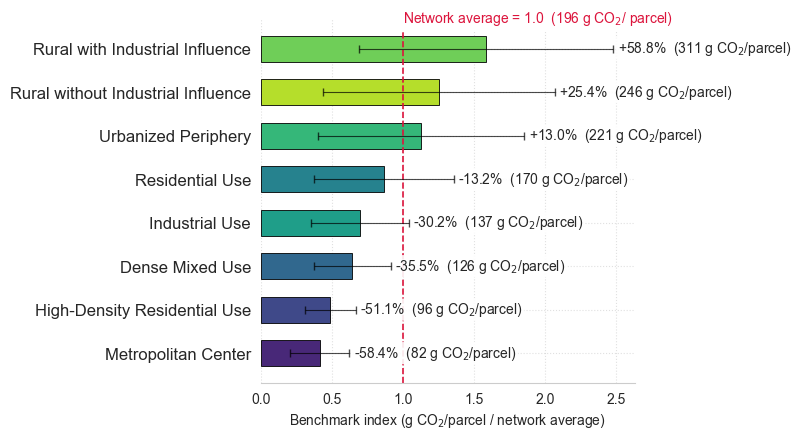

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==== Inputs ====
# result: DataFrame with columns ["main_area_type_name", "co2_per_pkg_g"]

plotWithoutEV = result[result["is_ev"] == 0]
area_colors = {
    "Metropolitan Center": "#482878",
    "High-Density Residential Use": "#3f4989",
    "Dense Mixed Use": "#31688e",
    "Residential Use": "#26828e",
    "Industrial Use": "#1f9e89",
    "Urbanized Periphery": "#35b779",
    "Rural with Industrial Influence": "#6fce58",
    "Rural without Industrial Influence": "#b5de2b",
}

# ==== Per-area means and overall mean ====
mean_per_area = plotWithoutEV.groupby("main_area_type_name")["co2_per_pkg_g"].mean()
overall_mean = plotWithoutEV["co2_per_pkg_g"].mean()

# Benchmark index (relative to network average)
bench = (mean_per_area / overall_mean).sort_values()
areas_ordered = bench.index.tolist()
colors = [area_colors.get(a, "#999999") for a in areas_ordered]

# ==== Classical tour-based uncertainty (95% CI or SD) ====
stats = (
    plotWithoutEV.groupby("main_area_type_name")["co2_per_pkg_g"]
    .agg(mean="mean", std=lambda s: float(np.std(s, ddof=1)), n="count")
)

error_mode = "sd"  # or "sd"
if error_mode == "ci95":
    se = stats["std"] / np.sqrt(stats["n"].clip(lower=1))
    half = 1.96 * se
else:
    half = stats["std"]

# Normalize CI to benchmark scale and align to plotting order
ci_lo = ((stats["mean"] - half) / overall_mean).reindex(areas_ordered).to_numpy()
ci_hi = ((stats["mean"] + half) / overall_mean).reindex(areas_ordered).to_numpy()

# ==== Plot style ====
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.grid": True,
    "grid.linestyle": ":", "grid.alpha": 0.6
})

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(bench))

# Bars
bars = ax.barh(y, bench.values, color=colors, edgecolor="black", linewidth=0.6, height=0.6)

# Error bars from classical uncertainty
err_left = np.clip(bench.values - ci_lo, 0, None)
err_right = np.clip(ci_hi - bench.values, 0, None)
ax.errorbar(
    bench.values, y,
    xerr=[err_left, err_right],
    fmt="none", ecolor="black", elinewidth=0.8, capsize=3, alpha=0.7, zorder=3
)

# Reference line and label
ax.axvline(1.0, color="crimson", linestyle="--", linewidth=1.2)
ax.text(
    1.0, len(bench) - 0.1,
    f"Network average = 1.0  ({overall_mean:.0f} g CO$_2$/ parcel)",
    color="crimson", fontsize=10, va="top", ha="left",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=1)
)

# Axes
ax.set_yticks(y)
ax.set_yticklabels(areas_ordered)
ax.set_xlabel("Benchmark index (g CO$_2$/parcel / network average)", size=10)

# End labels
for i, (yi, val, area) in enumerate(zip(y, bench.values, areas_ordered)):
    pct = (val - 1.0) * 100.0
    abs_g = mean_per_area.loc[area]
    label = f"{pct:+.1f}%  ({abs_g:.0f} g CO$_2$/parcel)"
    x_text = ci_hi[i] + 0.03
    ax.text(
        x_text, yi, label, va="center", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9)
    )

# X limits
xmin = 0
xmax = max(ci_hi.max() + 0.15, bench.values.max() + 0.15)
ax.set_xlim(xmin, xmax)

ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()
# plt.savefig("area_type_benchmarking.pdf", dpi=300, bbox_inches="tight")
plt.show()


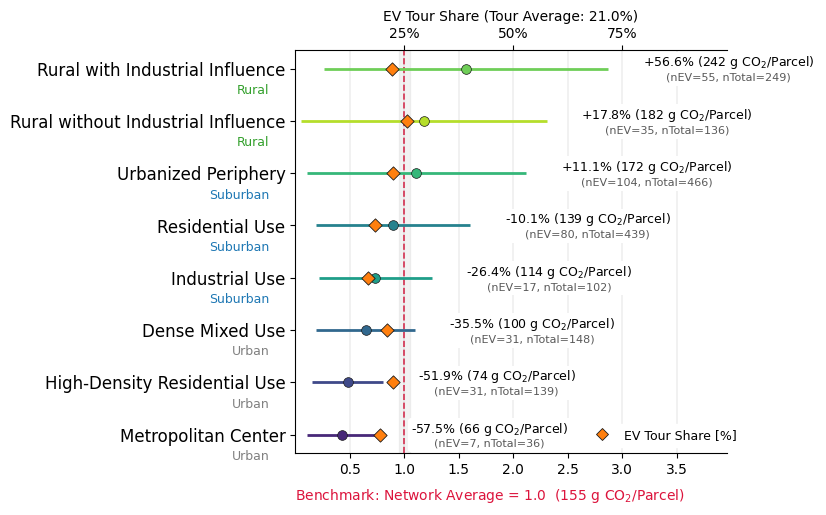

In [384]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import TextArea, VPacker, AnnotationBbox

# mapping from detailed to aggregated types
def determine_area_type(area_name):
    mapping = {
        "Metropolitan Center": "Urban",
        "High-Density Residential Use": "Urban",
        "Dense Mixed Use": "Urban",
        "Residential Use": "Suburban",
        "Industrial Use": "Suburban",
        "Urbanized Periphery": "Suburban",
        "Rural with Industrial Influence": "Rural",
        "Rural without Industrial Influence": "Rural"
    }
    return mapping.get(area_name, "unknown")

category_color_dict_agg = {
    'Urban': '#808080',      # grey
    'Suburban': '#1f78b4',   # blue
    'Rural': '#33a02c'       # green
}

# Inputs:
# - result: DataFrame with columns ["main_area_type_name","co2_per_pkg_g"] and preferably "is_ev"
# - area_colors: dict mapping the 8 area type names to colors

# If "is_ev" is missing, try to infer it from common powertrain columns
def ensure_is_ev(df):
    if "is_ev" in df.columns:
        return df["is_ev"].astype(bool)
    cols = {c.lower(): c for c in df.columns}
    for cand in ["vehicle_powertrain", "powertrain", "drivetrain", "vehicle_type", "fuel_type"]:
        if cand in cols:
            s = df[cols[cand]].astype(str).str.lower()
            return s.str.contains("bev|ev|electric")
    raise ValueError("Missing EV indicator. Provide 'is_ev' or a powertrain column.")

# ---------- stats for forest plot ----------
overall_mean = result["co2_per_pkg_g"].mean()
stats = (
    result.groupby("main_area_type_name")["co2_per_pkg_g"]
          .agg(mean="mean", std=lambda s: float(np.std(s, ddof=1)), n="count")
)

bench = (stats["mean"] / overall_mean).sort_values()
areas = bench.index.tolist()
colors = [area_colors.get(a, "#999999") for a in areas]

sd_norm = (stats.loc[areas, "std"] / overall_mean).to_numpy()
ci_lo = bench.values - sd_norm
ci_hi = bench.values + sd_norm

y = np.arange(len(areas))
fig_h = 0.5 * len(areas) + 1.2
fig, ax = plt.subplots(figsize=(8, fig_h))

# equivalence band and reference
ax.axvspan(0.95, 1.05, color="#cccccc", alpha=0.25, zorder=0)
ax.axvline(1.0, color="crimson", ls="--", lw=1.2, zorder=1)

# forest elements
for i, a in enumerate(areas):
    ax.hlines(y[i], ci_lo[i], ci_hi[i], color=colors[i], lw=2, zorder=2)
    ax.plot(bench.iloc[i], y[i], "o", ms=7, color=colors[i], mec="k", mew=0.5, zorder=30)

ax.set_yticks(y)
ax.set_yticklabels(areas, size = 12)

# x limits with extra space for labels
xmin_core = min(0.8, float(ci_lo.min()) - 0.05)
xmax_core = float(max(ci_hi.max(), bench.max()))
xrange_core = xmax_core - xmin_core
xmax = xmax_core + 0.38 * xrange_core
ax.set_xlim(xmin_core, xmax)

# ---------- EV counts and totals (now that 'areas' exists) ----------
is_ev = ensure_is_ev(result)
ev_count_by_area = (
    result.assign(is_ev=is_ev)
          .groupby("main_area_type_name")["is_ev"]
          .sum().reindex(areas).fillna(0).astype(int)
)
total_tours_by_area = (
    result.groupby("main_area_type_name")["co2_per_pkg_g"]
          .count().reindex(areas).fillna(0).astype(int)
)
tours_df = result.copy()

# weighting for EV share
weight_mode = "tour"  # or "parcel" if 'deliveries' exists
def weighted_mean_bool(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        return float(np.mean(x)) if x.size else np.nan
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return float(np.average(x[m], weights=w[m])) if np.any(m) else np.nan

w_series = tours_df["deliveries"] if (weight_mode == "parcel" and "deliveries" in tours_df.columns) else None

ev_share = (
    tours_df.assign(is_ev=is_ev)
            .groupby("main_area_type_name")["is_ev"]
            .apply(lambda s: weighted_mean_bool(s, w_series.loc[s.index] if w_series is not None else None))
            .reindex(areas)
)

# right-side labels as two lines, centered
xrange_full = ax.get_xlim()[1] - ax.get_xlim()[0]
offset = 0.08 * xrange_full
for i, a in enumerate(areas):
    pct = (bench.loc[a] - 1.0) * 100.0
    abs_g = float(stats.loc[a, "mean"])
    n_ev = int(ev_count_by_area.loc[a])
    n_all = int(total_tours_by_area.loc[a])

    line1 = f"{pct:+.1f}% ({abs_g:,.0f} g CO$_2$/Parcel)"
    line2 = f"(nEV={n_ev:,}, nTotal={n_all:,})"

    ta1 = TextArea(line1, textprops=dict(size=9, color="black"))
    ta2 = TextArea(line2, textprops=dict(size=8, color="0.35"))
    box = VPacker(children=[ta1, ta2], align="center", pad=0, sep=1.0)

    ab = AnnotationBbox(
        box,
        (ci_hi[i] + offset, y[i]),
        xycoords=("data", "data"),
        box_alignment=(0.0, 0.5),
        frameon=True,   # show frame
        bboxprops=dict(
            boxstyle="round,pad=0.18",
            fc="white",   # background white
            ec="white",   # edge/frame also white
            lw=0.8,       # optional: frame thickness
            alpha=1
        ),
        zorder=4,
        clip_on=False
    )
    ax.add_artist(ab)

# bottom benchmark note
ax.text(0, -1,
        f"Benchmark: Network Average = 1.0  ({overall_mean:.0f} g CO$_2$/Parcel)",
        color="crimson", fontsize=10, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9),
        zorder=5, clip_on=False)

ax.grid(axis="x", linewidth=0.25, alpha=1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# After: ax.set_xlim(xmin_core, xmax)
xmin, xmax = ax.get_xlim()

# Anchor mapping: share s in [0,1] -> bottom x
def map_share(s, x_at_0=0.0, x_at_25=1.0):
    s = np.asarray(s, dtype=float)
    scale = (x_at_25 - x_at_0) / 0.25  # = 4.0 for 0%->0.0 and 25%->1.0
    return x_at_0 + scale * s

ax2 = ax.twiny()
ax2.set_xlim(xmin, xmax)

overall_ev_share = weighted_mean_bool(is_ev, w_series) * 100.0  # in %
ax2.set_xlabel(f"EV Tour Share (Tour Average: {overall_ev_share:.1f}%)")

# Ticks exactly above bottom x = 0, 1, 2, 3, 4 (filter to current view)
ticks_share = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
tick_pos = map_share(ticks_share)
m = (tick_pos >= xmin) & (tick_pos <= xmax)
ax2.set_xticks(tick_pos[m])
ax2.set_xticklabels([f"{int(t*100)}%" for t in ticks_share[m]])

# Markers for EV share
x_ev = map_share(np.asarray(ev_share, dtype=float))
ax2.scatter(x_ev, y, marker="D", s=46,
            color="tab:orange", edgecolor="k", linewidth=0.6, zorder=10)

# Make sure only one grid is visible
ax2.grid(False)
ax2.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(True)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)

# legend
ev_handle = Line2D([0], [0], marker="D", color="none",
                   markerfacecolor="tab:orange", markeredgecolor="k",
                   markeredgewidth=0.6, markersize=6, label="EV Tour Share [%]")
ax.legend(
    handles=[ev_handle],
    loc="lower right",
    bbox_to_anchor=(1.05, 0.0),  # weiter nach rechts, y=0 bleibt unten
    frameon=True,
    fontsize=9,
    fancybox=True,
    framealpha=1,              # leichte Transparenz
    facecolor="white",
    edgecolor="1"
)

# Kleine Aggregatlabels links unter die großen Y-Ticks setzen
xmin, xmax = ax.get_xlim()
xrange_full = xmax - xmin
left_offset = 0.06 * xrange_full   # bei Bedarf anpassen
y_shift = -0.35                    # vertikal unter die Hauptzeile rücken

for i, a in enumerate(areas):
    agg = determine_area_type(a)
    agg_col = category_color_dict_agg.get(agg, "0.35")

    ta = TextArea(
        agg,
        textprops=dict(size=9, color=agg_col, va="center", ha="right")
    )
    ab = AnnotationBbox(
        ta,
        (xmin - left_offset, y[i] + y_shift),
        xycoords=("data", "data"),
        box_alignment=(1.0, 0.5),
        frameon=False,
        zorder=5,
        clip_on=False
    )
    ax.add_artist(ab)

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
plt.savefig("area_type_benchmarking_new.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [40]:
result["Cost per Parcel [€/parcel]"] =  result["vehicle_cost"] / result["deliveries"] 


result["b2b_deliveries"] = result["deliveries"] * result["b2b_ration"]
result["b2c_deliveries"] = result["deliveries"] * (1 - result["b2b_ration"])
result["cost_b2b_total"] = result["vehicle_cost"] * (result["b2b_deliveries"] / result["deliveries"])
result["cost_b2c_total"] = result["vehicle_cost"] * (result["b2c_deliveries"] / result["deliveries"])

result["Cost per B2B Parcel [€/parcel]"] = result["cost_b2b_total"] / result["b2b_deliveries"]
result["Cost per B2C Parcel [€/parcel]"] = result["cost_b2c_total"] / result["b2c_deliveries"]



In [ ]:
# Van-Verkehrsstärken als Liniennetz-Plot mit Raumtypen im Hintergrund (transparent)
import matplotlib.pyplot as plt
import geopandas as gpd

# Annahmen:
# - network_volumes_filtered enthält 'geometry', 'van_count', 'link_id'
# - regionclusters_split enthält die Polygone der Raumtypen und Spalten 'area_type' oder 'raumtyp_label'
# - category_color_dict ist das Farbschema für die Raumtypen

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Raumtypen als Hintergrundkarte (mit Transparenz)
if 'regionclusters_split' in globals():
    regionclusters_split.plot(
        column='area_type' if 'area_type' in regionclusters_split.columns else 'raumtyp_label',
        ax=ax,
        alpha=0.18,  # hohe Transparenz
        edgecolor='none',
        legend=False,
        color=[category_color_dict.get(val, '#cccccc') for val in regionclusters_split['area_type']]
            if 'area_type' in regionclusters_split.columns and 'category_color_dict' in globals()
            else '#cccccc'
    )
else:
    print('regionclusters_split nicht gefunden!')

# 2. Van-Verkehrsstärken als farbige Linien
if 'network_volumes_filtered' in globals():
    gdf = network_volumes_filtered.copy()
    # Optional: nur Links mit Van-Verkehr
    gdf = gdf[gdf['van_count'] > 0]
    # Plot: Linienbreite proportional zur Verkehrsstärke
    gdf.plot(
        ax=ax,
        linewidth=(gdf['van_count'] / gdf['van_count'].max()) * 6 + 0.2,  # Skaliert, min. 0.2
        color='red',
        alpha=0.85,
        label='Van-Verkehrsstärke'
    )
else:
    print('network_volumes_filtered nicht gefunden!')

# 3. Plot-Details
ax.set_title('Van-Verkehrsstärken im Netz mit Raumtypen-Hintergrund', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Van-Verkehrsstärken im Netz mit Raumtypen-Hintergrund

Die folgende Abbildung zeigt die Van-Verkehrsstärken als farbige Linien auf dem Straßennetz. Die Raumtypen werden als transparente Flächen im Hintergrund dargestellt, sodass die räumliche Einordnung der Verkehrsströme direkt sichtbar ist.

- **Linienbreite:** proportional zur Van-Verkehrsstärke (Anzahl Fahrten pro Link)
- **Farbe Hintergrund:** gemäß Raumtyp (Projektfarbcode)
- **Transparenz:** hohe Transparenz für Flächen, damit das Netz im Vordergrund steht

In [191]:
# Van-Verkehrsstärken als Liniennetz-Plot mit Raumtypen im Hintergrund (transparent, Reds colormap)
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(14, 12))

# 1. Raumtypen als Hintergrundkarte (mit Transparenz)
if 'regionclusters_split' in globals():
    regionclusters_split.plot(
        column='area_type' if 'area_type' in regionclusters_split.columns else 'raumtyp_label',
        ax=ax,
        alpha=0.18,  # hohe Transparenz
        edgecolor='none',
        legend=False,
        color=[category_color_dict.get(val, '#cccccc') for val in regionclusters_split['area_type']]
            if 'area_type' in regionclusters_split.columns and 'category_color_dict' in globals()
            else '#cccccc'
    )
else:
    print('regionclusters_split nicht gefunden!')

# 2. Van-Verkehrsstärken als farbige Linien (Reds colormap)
if 'network_volumes_filtered' in globals():
    gdf = network_volumes_filtered.copy()
    gdf = gdf[gdf['van_count'] > 0]
    norm = mpl.colors.Normalize(vmin=gdf['van_count'].min(), vmax=gdf['van_count'].max())
    cmap = mpl.cm.get_cmap('Reds')
    for _, row in gdf.iterrows():
        color = cmap(norm(row['van_count']))
        ax.plot(*row['geometry'].xy, color=color, linewidth=(row['van_count']/gdf['van_count'].max())*6+0.2, alpha=1)
    # Colorbar
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
    cbar.set_label('Van-Verkehrsstärke (Fahrten pro Link)')
else:
    print('network_volumes_filtered nicht gefunden!')

ax.set_title('Van-Verkehrsstärken im Netz (Reds) mit Raumtypen-Hintergrund', fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1988839699.py:10: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  regionclusters_split.plot(
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1988839699.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Reds')
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1988839699.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('Reds')


KeyboardInterrupt: 

In [208]:
# Reset Matplotlib and Seaborn to clean defaults
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.close('all')                       # close all open figures
mpl.rcParams.update(mpl.rcParamsDefault)  # Matplotlib defaults
plt.style.use('default')               # clear any style sheets
sns.reset_orig()                       # undo Seaborn rc changes
# optional: also clear Seaborn defaults layer
# sns.reset_defaults()

# optional Jupyter inline backend back to PNG
# %config InlineBackend.figure_format = 'png'


In [ ]:
# ==== Gesamte Fahrstrecke pro Raumtyp (nur Vans) ====
# Annahme: network_volumes_filtered enthält 'length' (Meter), 'van_count', 'link_id'
# link_raumtyp: dict {link_id: raumtyp_id}
# area_type_dict: dict {raumtyp_id: Name}

gdf = network_volumes_filtered.copy()

# Raumtyp für jeden Link bestimmen
gdf['raumtyp_id'] = gdf['link_id'].map(link_raumtyp)
# Optional: Raumtyp-Label bestimmen
gdf['raumtyp_label'] = gdf['raumtyp_id'].map(area_type_dict) if 'area_type_dict' in globals() else gdf['raumtyp_id'].astype(str)

# Berechne zurückgelegte km pro Link: Länge (in km) * van_count
gdf['km_van'] = (gdf['length'] / 1000) * gdf['van_count']

# Gruppieren nach Raumtyp
km_per_area = gdf.groupby('raumtyp_label')['km_van'].sum().sort_values(ascending=False)

# Farben aus area_colors übernehmen, falls vorhanden
color_list = [area_colors.get(area, '#888888') for area in km_per_area.index]

# Plot als Ergänzung zum Benchmark-Plot
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
y2 = np.arange(len(km_per_area))
bars2 = ax2.barh(y2, km_per_area.values, color=color_list, edgecolor="black", linewidth=0.6, height=0.6)
ax2.set_yticks(y2)
ax2.set_yticklabels(km_per_area.index)
ax2.set_xlabel('Zurückgelegte Kilometer (Vans)')
ax2.set_title('Zurückgelegte Kilometer pro Raumtyp (nur Vans)')
plt.tight_layout()
plt.savefig("area_type_km_van.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
import pandas as pd

# Assumptions:
# - plot_df: 15 min CO2 values per area type, index = DatetimeIndex (one day)
# - name_to_color: dict {area type: color} that covers all plot_df.columns
colors = [name_to_color[c] for c in plot_df.columns]

# 1) Derived frames
share_df = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0.0)
cum_df = plot_df.cumsum()

# 2) Time windows
day0 = plot_df.index.normalize()[0]
start = day0 + pd.Timedelta(hours=6)
end = day0 + pd.Timedelta(hours=22)
end2 = day0 + pd.Timedelta(hours=21)  # cumulative only until 21:00

share_window = share_df.loc[start:end]
cum_window = cum_df.loc[start:end2]

# 3) Figure with two stacked subplots
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(8, 6.5), sharex=True, gridspec_kw={"height_ratios": [1.1, 1.0]}
)

# Top: cumulative emissions [kg] until 21:00 (displayed as tonnes)
cum_window.plot.area(ax=ax_top, stacked=True, color=colors, alpha=0.9, legend=False)
ax_top.plot(cum_window.index, cum_window.sum(axis=1), color="black", linewidth=1.6, label="Total cumulative")
# Show tonnes on the y-axis
ax_top.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/1000:,.1f}"))
ax_top.set_ylabel("Cumulative CO₂ Emissions [t]")

# Bottom: shares [%] 06:00 to 22:00
share_window.plot.area(ax=ax_bottom, stacked=True, color=colors, alpha=0.9, legend=False)
ax_bottom.set_ylabel("CO₂ Emissions Share [%]")
ax_bottom.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_bottom.set_xlabel("Time of day")

# X axis formatting
for ax in (ax_top, ax_bottom):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.7)

# --- Custom legend with total shares by 21:00 ---
end_vals = cum_window.iloc[-1]  # cumulative by 21:00
total_end = end_vals.sum()
shares_end = (end_vals / total_end).fillna(0.0)

# Format legend labels: aligned percentages with 1 decimal (monospace + right-aligned)

maxlen = max(len(str(c)) for c in plot_df.columns)
patches = []
labels = []
for col in plot_df.columns:
    pct = shares_end.get(col, 0.0) * 100
    total_tonnes = end_vals.get(col, 0.0) / 1000
    patches.append(mpatches.Patch(facecolor=name_to_color[col], edgecolor='none'))
    labels.append(f"{col.ljust(maxlen)} ({total_tonnes:.2f} t, {pct:.1f} %)")

# Monospaced legend for proper alignment (Windows-friendly fallbacks)
fp = FontProperties(family=['monospace'])
ax_top.legend(
    patches, labels,
    title="Area Type (with Total Share of CO₂ Emissions)",
    loc="upper left", bbox_to_anchor=(0.0, 1.02), ncol=1, frameon=True,
    prop=fp
)
plt.tight_layout()
# plt.savefig("area_type_emissions.png", dpi=1000, bbox_inches="tight")
plt.show()


In [196]:
network_volumes_df= network_volumes_filtered

# Sicherstellen, dass die Area-Type-Spalte als Name vorliegt
if 'main_area_type_name' not in network_volumes_df.columns:
    if 'raumtyp' in network_volumes_df.columns:
        network_volumes_df['main_area_type_name'] = network_volumes_df['raumtyp'].astype(str).map(category_dict)
    elif 'main_area_type' in network_volumes_df.columns:
        network_volumes_df['main_area_type_name'] = network_volumes_df['main_area_type'].astype(str).map(category_dict)
    else:
        print('Keine Area-Type-Spalte gefunden!')


Keine Area-Type-Spalte gefunden!


In [ ]:
# ===== Emissions surface: sum per 10 km hex, plotted like the cost surface =====

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # needed for ax.get_proj override
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.interpolate import griddata

# Inputs expected in memory:
# - emissions_15min_long: DataFrame with ['link_id','interval_15min','emissions_g']
# - network: GeoDataFrame with ['link_id','geometry'] in projected CRS (meters)
# - regionclusters_split: GeoDataFrame with ['area_type','geometry'] same CRS
# - category_color_dict: dict mapping area_type to color strings
# - add_polygons_on_z0(ax, gdf, color_map, alpha=..., draw_legend=...) defined or use the helper below

# Optional helper: add_polygons_on_z0 with draw_legend flag (safe if you already defined it)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch

def add_polygons_on_z0(ax3d, gdf, color_map,
                       edgecolor=(0.4, 0.4, 0.4, 1.0),
                       default_color=(0.85, 0.85, 0.85, 1.0),
                       alpha=0.9,
                       draw_legend=False,
                       z0=0.0):
    used = set()
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        facecolor = color_map.get(row.get("area_type", None), default_color)
        used.add(row.get("area_type", None))

        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue

        for poly in polys:
            ex_x, ex_y = poly.exterior.coords.xy
            verts = [(float(x), float(y), float(z0)) for x, y in zip(ex_x, ex_y)]
            ax3d.add_collection3d(Poly3DCollection([verts],
                                  facecolors=facecolor, edgecolors=edgecolor,
                                  linewidths=0.4, alpha=alpha))
            for interior in poly.interiors:
                in_x, in_y = interior.coords.xy
                verts_in = [(float(x), float(y), float(z0)) for x, y in zip(in_x, in_y)]
                ax3d.add_collection3d(Poly3DCollection([verts_in],
                                      facecolors=(1, 1, 1, 0.0), edgecolors=edgecolor,
                                      linewidths=0.3, alpha=1.0))
    if draw_legend:
        labels = [k for k in used if k in color_map]
        patches = [Patch(facecolor=color_map[k], edgecolor=edgecolor, label=k) for k in labels]
        if patches:
            ax3d.legend(handles=patches, loc="upper left",
                        bbox_to_anchor=(1.02, 1.0), frameon=False, title="Area type")

# ------------------------------------------------------------------------------
# 1) Aggregate emissions per link to one day
emissions_day = (
    emissions_15min_long.groupby('link_id', as_index=False)['emissions_g']
    .sum().rename(columns={'emissions_g': 'emissions_g_day'})
)

# 2) Prepare links GeoDataFrame
links_gdf = (
    network[['link_id', 'geometry']]
    .drop_duplicates(subset=['link_id'])
    .merge(emissions_day, on='link_id', how='left')
    .fillna({'emissions_g_day': 0.0})
)
# ensure CRS matches regionclusters_split
if links_gdf.crs != regionclusters_split.crs:
    links_gdf = links_gdf.to_crs(regionclusters_split.crs)

# Filter out zero links early
EPS = 1e-12
links_gdf = links_gdf[links_gdf['emissions_g_day'] > EPS]
if links_gdf.empty:
    raise ValueError("No links with positive emissions.")

# 3) Build a 10 km flat topped hex grid covering the links extent
hex_size = 10000.0  # edge to edge width
r = hex_size / 2.0
dx = 3.0 * r / 2.0
dy = np.sqrt(3.0) * r / 2.0

minx, miny, maxx, maxy = links_gdf.total_bounds
pad = hex_size
minx, miny, maxx, maxy = minx - pad, miny - pad, maxx + pad, maxy + pad

def hex_polygon(cx, cy, rad):
    angles = np.deg2rad([0, 60, 120, 180, 240, 300])  # flat topped
    verts = [(cx + rad * np.cos(a), cy + rad * np.sin(a)) for a in angles]
    return Polygon(verts)

hexes = []
hex_ids = []
j = 0
row = 0
y = miny
while y <= maxy + 1e-6:
    x_offset = 0.0 if (row % 2 == 0) else dx / 2.0
    x = minx
    while x <= maxx + 1e-6:
        cx = x + x_offset
        poly = hex_polygon(cx, y, r)
        hexes.append(poly)
        hex_ids.append(j)
        j += 1
        x += dx
    y += dy
    row += 1

hex_gdf = gpd.GeoDataFrame({'hex_id': hex_ids}, geometry=hexes, crs=links_gdf.crs)
hex_gdf['cx'] = hex_gdf.geometry.centroid.x.astype(float)
hex_gdf['cy'] = hex_gdf.geometry.centroid.y.astype(float)

# 4) Assign each link to the hex where it has the largest overlap length
inter = gpd.overlay(links_gdf[['link_id','geometry','emissions_g_day']], hex_gdf[['hex_id','geometry']], how='intersection')
inter['seg_len'] = inter.geometry.length
idx = inter.groupby('link_id')['seg_len'].idxmax()
link2hex = inter.loc[idx, ['link_id','hex_id']].copy()

# 5) Sum emissions per hex (kg per day)
em_hex = (
    emissions_day.merge(link2hex, on='link_id', how='inner')
    .groupby('hex_id', as_index=False)['emissions_g_day'].sum()
)
em_hex['emissions_kg_day'] = em_hex['emissions_g_day'] / 1000.0

hex_emit = hex_gdf.merge(em_hex[['hex_id','emissions_kg_day']], on='hex_id', how='left').fillna({'emissions_kg_day': 0.0})

# 6) Dominant area_type per hex via centroid sjoin (for base coloring)
centroids = gpd.GeoDataFrame({'hex_id': hex_emit['hex_id'], 'geometry': hex_emit.geometry.centroid}, crs=hex_emit.crs)
ct = gpd.sjoin(
    centroids,
    regionclusters_split[['area_type','geometry']],
    how='left', predicate='within'
)[['hex_id','area_type']]
hex_emit = hex_emit.merge(ct, on='hex_id', how='left')

EPS = 1e-12
# EPS = 10
# 7) Build hex_heights tuples (cx, cy, total_kg, color) and drop zero hexes
hex_heights = []
for _, row in hex_emit.iterrows():
    total_kg = float(row['emissions_kg_day']) 
    if total_kg <= EPS:
        continue
    cx = float(row['cx'])
    cy = float(row['cy'])
    at = row.get('area_type', None)
    color = category_color_dict.get(at, '#888888')
    hex_heights.append((cx, cy, (total_kg+4000)/1000, color))

if not hex_heights:
    raise ValueError("No hexes with positive emissions to plot.")

# 8) Prepare arrays exactly like your cost plot (variable 'costs' now holds totals)
hx = np.array([h[0] for h in hex_heights])
hy = np.array([h[1] for h in hex_heights])
costs = np.array([h[2] for h in hex_heights])  # here: total emissions [kg] per hex

# ==== Plot block identical to your cost surface, labels adapted ====

# Build interpolation grid for a smooth surface
grid_x, grid_y = np.mgrid[hx.min():hx.max():500j, hy.min():hy.max():500j]
grid_z = griddata((hx, hy), costs, (grid_x, grid_y), method="cubic")

# Do not fill holes. Mask invalid values so they are not plotted.
grid_z_masked = np.ma.masked_invalid(grid_z)

# Color range based on finite values
finite_costs = costs[np.isfinite(costs)]
vmin = float(np.nanmin(finite_costs))
vmax = float(np.nanmax(finite_costs))

NameError: name 'emissions_15min_long' is not defined

In [210]:
from scipy.interpolate import Rbf
from scipy.spatial import Delaunay
# # Fit RBF on scattered data
# # function can be 'multiquadric', 'inverse', 'gaussian', 'linear', 'cubic', 'quintic', 'thin_plate'
# rbf = Rbf(hx, hy, costs, function='multiquadric', smooth=0.1, epsilon=None)
# # smooth controls regularization, increase for smoother surface
# # epsilon can be tuned, leave None to auto-scale

# # Evaluate on your grid
# grid_z = rbf(grid_x, grid_y)
# grid_z_masked = np.ma.masked_invalid(grid_z)



pts = np.column_stack([hx, hy])
tri = Delaunay(pts)

def in_hull(xy, hull):
    return hull.find_simplex(xy) >= 0

XY = np.column_stack([grid_x.ravel(), grid_y.ravel()])
inside = in_hull(XY, tri).reshape(grid_x.shape)
grid_z_masked = np.ma.masked_array(grid_z_masked, mask=~inside)


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1953108924.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))


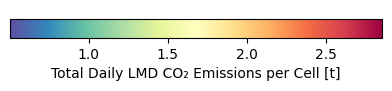

In [255]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import LinearLocator, FormatStrFormatter

cmap_name = "Spectral_r"

fig_cb, ax_cb = plt.subplots(figsize=(4.8, 0.6))  # wide and low
ax_cb.axis("off")

norm = mpl.colors.Normalize(vmin=vmin-3.5, vmax=vmax-3.5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.get_cmap(cmap_name))
sm.set_array([])

cbar = fig_cb.colorbar(
    sm, ax=ax_cb,
    orientation="horizontal",
    fraction=1.0, pad=0.2
)
cbar.set_label("Total Daily LMD CO₂ Emissions per Cell [t]", labelpad=4)

# # exactly 8 ticks
# cbar.locator = LinearLocator(numticks=8)
# cbar.formatter = FormatStrFormatter("%.2f")
# cbar.update_ticks()

# optional place ticks and label at bottom
cbar.ax.xaxis.set_ticks_position("bottom")
cbar.ax.xaxis.set_label_position("bottom")

# save as SVG
mpl.rcParams["svg.fonttype"] = "none"
fig_cb.savefig("colorbar_emissions.svg", format="svg",
               bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\2778609086.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = mpl.cm.get_cmap(cmap_name)


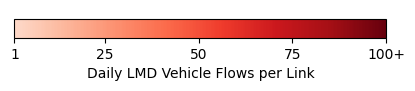

In [298]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def truncated_cmap(cmap_name="Reds", min_tone=0.0, max_tone=1.0, N=256):
    base = mpl.cm.get_cmap(cmap_name)
    tones = np.linspace(min_tone, max_tone, N)
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"{cmap_name}_trunc_{min_tone:.2f}_{max_tone:.2f}",
        base(tones)
    )

def make_traffic_colorbar(
    v_values,                 # z.B. lines_gdf['van_count'].to_numpy()
    vmin=None, vmax=None,     # genau dieselben Grenzen wie beim Plotten verwenden!
    cmap_name="Reds",
    min_tone=0.15, max_tone=1.0,
    label="Van traffic volume (van_count)",   # Beschriftung nach Wunsch
    fig_size=(4.8, 0.6),      # breit & flach wie dein Beispiel
    num_ticks=6               # optional: feste Tick-Anzahl
):
    v = np.asarray(v_values, dtype=float)
    v = v[np.isfinite(v)]
    if vmin is None:
        vmin = float(np.nanmin(v))
    if vmax is None:
        vmax = float(np.nanmax(v))
    if vmax <= vmin:
        vmax = vmin + 1.0

    cmap_trunc = truncated_cmap(cmap_name, min_tone, max_tone)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_trunc)
    sm.set_array([])

    fig_cb, ax_cb = plt.subplots(figsize=fig_size)
    ax_cb.axis("off")
    cbar = fig_cb.colorbar(
        sm, ax=ax_cb,
        orientation="horizontal",
        fraction=1.0, pad=0.2
    )
    cbar.set_label(label, labelpad=4)

    # Feste Ticks/Labels: 1, 25, 50, 75, 100+
    last_tick = 100 if vmax >= 100 else vmax
    ticks = [1, 25, 50, 75, last_tick]
    labels = ["1", "25", "50", "75", "100+" if vmax >= 100 else f"{int(last_tick)}"]

    cbar.set_ticks(ticks)
    cbar.set_ticklabels(labels)

    # Ticks/Label unten – wie gehabt
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.ax.xaxis.set_label_position("bottom")
    

    # Für gestochen scharfe Schrift in SVG
    mpl.rcParams["svg.fonttype"] = "none"
    fig_cb.savefig("colorbar_traffic.svg", format="svg",
                   bbox_inches="tight", pad_inches=0.02, transparent=True)
    plt.show()

# ------------------------------
# Beispielaufruf (WICHTIG: gleiche Parameter wie beim Linienplot!)
# ------------------------------
# vmin/vmax/min_tone/max_tone exakt wie in add_traffic_lines_3d verwendet:
make_traffic_colorbar(
    v_values=lines_gdf.loc[lines_gdf["van_count"]>0, "van_count"].to_numpy(),
    vmin=None,      # oder derselbe vmin wie beim Plotten
    vmax=100,       # z.B. wie in deinem add_traffic_lines_3d-Call
    cmap_name="Reds",
    min_tone=0.15,
    max_tone=1.0,
    label="Daily LMD Vehicle Flows per Link",
    fig_size=(4.8, 0.6),
    num_ticks=6
)


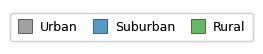

In [309]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Inputs: category_color_dict = {"Metropolitan Center":"#482878", ...}
labels_area = list(category_color_dict_agg.keys())
colors_area = [category_color_dict_agg[k] for k in labels_area]

# Square handles for area types
handles_area = [
    Line2D([0], [0],
           marker="s", linestyle="", color="w",
           markerfacecolor=c, markeredgewidth=0.5, markeredgecolor="black",
           markersize=10, alpha=0.7)
    for c in colors_area
]

# Figure
fig = plt.figure(figsize=(2, 0.925/2.5))
ax = fig.add_subplot(111)
ax.axis("off")

# Top legend  two rows of four  centered
leg1 = fig.legend(
    handles_area, labels_area,
    loc="center",
    ncol=3,
    frameon=True,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.6,
    columnspacing=1.2,
    borderpad=0.6
)
ax.add_artist(leg1)

fig.tight_layout(pad=0.1)
fig.savefig("legend_area_types_agg_1x3.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()


In [353]:
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection, Line3DCollection
from matplotlib.lines import Line2D

# ---------- helpers: rotate & transform ----------
def _rotate_xy(xa, ya, cx, cy, deg):
    xa = np.asarray(xa, dtype=float); ya = np.asarray(ya, dtype=float)
    th = np.deg2rad(float(deg)); c, s = np.cos(th), np.sin(th)
    dx, dy = xa - cx, ya - cy
    xr = cx + c*dx - s*dy
    yr = cy + s*dx + c*dy
    return xr, yr

def rotate_grid(X, Y, cx, cy, deg):
    return _rotate_xy(X, Y, cx, cy, deg)

# ---------- patched drawers with rotation ----------
def draw_area_polygons_at(ax3d, gdf, color_map,
                          edgecolor=(0.4, 0.4, 0.4, 1.0),
                          default_color=(0.85, 0.85, 0.85, 1.0),
                          alpha=0.9, z0=0.0,
                          rotate_deg=0.0, origin=None,
                          rasterized=True, force_back=True):
    # common origin (center) for consistent rotation
    if origin is None:
        minx, miny, maxx, maxy = gdf.total_bounds
        origin = (0.5*(minx+maxx), 0.5*(miny+maxy))
    cx, cy = origin

    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        facecolor = color_map.get(row.get("area_type_group", None), default_color)

        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue

        for poly in polys:
            ex_x, ex_y = poly.exterior.coords.xy
            ex_x, ex_y = _rotate_xy(ex_x, ex_y, cx, cy, rotate_deg)
            verts = [(float(x), float(y), float(z0)) for x, y in zip(ex_x, ex_y)]
            coll = Poly3DCollection([verts],
                                    facecolors=facecolor,
                                    edgecolors=edgecolor,
                                    linewidths=0.4,
                                    alpha=alpha)
            coll.set_zsort('min')
            coll.set_sort_zpos(-1e9)  # großer negativer Bias
            if rasterized:
                coll.set_rasterized(True)
            ax3d.add_collection3d(coll)

            for interior in poly.interiors:
                in_x, in_y = interior.coords.xy
                in_x, in_y = _rotate_xy(in_x, in_y, cx, cy, rotate_deg)
                verts_in = [(float(x), float(y), float(z0)) for x, y in zip(in_x, in_y)]
                hole = Poly3DCollection([verts_in],
                                        facecolors=(1, 1, 1, 0.0),
                                        edgecolors=edgecolor,
                                        linewidths=0.3,
                                        alpha=1.0)
                if rasterized:
                    hole.set_rasterized(True)
                if force_back:
                    try:
                        hole.set_zsort("min")
                        hole.set_sort_zpos(-1e12)
                    except Exception:
                        hole._sort_zpos = -1e12
                ax3d.add_collection3d(hole)


def add_traffic_lines_3d(ax3d, gdf_lines, value_col="van_count",
                         z0=0.0, lw_min=0.2, lw_max=6.0,
                         alpha=0.85, crs_target=None, rasterized=True,
                         rotate_deg=0.0, origin=None,
                         cmap="Reds", vmin=None, vmax=None, min_tone=0.25, force_front=True):
    """
    Zeichnet Traffic-Linien auf Höhe z0 und färbt sie nach value_col mit Colormap (z.B. 'Reds').
    rotate_deg/origin: gleiche Rotation wie deine Basemap.
    min_tone: 0..1 – zieht die Colormap etwas in den satteren Bereich (vermeidet zu blass).
    """
    if gdf_lines is None or gdf_lines.empty:
        return

    gdf = gdf_lines.copy()
    m = np.isfinite(gdf[value_col]) & (gdf[value_col] > 0)
    gdf = gdf[m]
    if gdf.empty:
        return

    if crs_target is not None and hasattr(gdf, "to_crs") and gdf.crs is not None and gdf.crs != crs_target:
        gdf = gdf.to_crs(crs_target)

    v = gdf[value_col].to_numpy(dtype=float)
    if vmin is None: vmin = float(np.nanmin(v))
    if vmax is None: vmax = float(np.nanmax(v))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmax = vmin + 1.0

    norm = (v - vmin) / (vmax - vmin)
    norm = np.clip(norm, 0, 1)
    # Sattere Töne (nicht zu blass):
    norm = min_tone + (1.0 - min_tone) * norm

    # Line widths nach Intensität
    lw_vec = lw_min + ((v - vmin) / (vmax - vmin)) * (lw_max - lw_min)
    lw_vec = np.clip(lw_vec, lw_min, lw_max)
    lw_map = dict(zip(gdf.index.to_numpy(), lw_vec))

    # Rotation-Ursprung
    if origin is None:
        minx, miny, maxx, maxy = gdf.total_bounds
        origin = (0.5*(minx+maxx), 0.5*(miny+maxy))
    cx, cy = origin

    # Colormap-Objekt
    cmap_obj = plt.get_cmap(cmap)

    segments, widths, colors = [], [], []

    def _rotate_xy(xa, ya, cx, cy, deg):
        th = np.deg2rad(float(deg)); c, s = np.cos(th), np.sin(th)
        dx, dy = xa - cx, ya - cy
        return cx + c*dx - s*dy, cy + s*dx + c*dy

    for row_idx, row in gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue

        # Farbe/Alpha je Feature
        idx = np.where(gdf.index.to_numpy() == row_idx)[0][0]
        col = list(cmap_obj(norm[idx]))
        col[3] = alpha  # setze Alpha
        line_w = lw_map.get(row_idx, lw_min)

        def add_ls(ls):
            coords = np.asarray(ls.coords, dtype=float)
            if coords.shape[0] < 2:
                return
            xr, yr = _rotate_xy(coords[:,0], coords[:,1], cx, cy, rotate_deg)
            seg3d = np.column_stack([xr, yr, np.full(coords.shape[0], z0, dtype=float)])
            segments.append(seg3d)
            widths.append(float(line_w))
            colors.append(tuple(col))  # eine Farbe pro Segment

        if geom.geom_type == "LineString":
            add_ls(geom)
        elif geom.geom_type == "MultiLineString":
            for ls in geom.geoms:
                add_ls(ls)

    if not segments:
        return

    lc = Line3DCollection(segments, linewidths=np.asarray(widths, dtype=float))
    lc.set_colors(colors)
    
    if rasterized:
        lc.set_rasterized(True)
        
    if force_front:
        try:
            lc.set_zsort("max")
            lc.set_sort_zpos(1e12)
        except Exception:
            lc._sort_zpos = 1e12  # Fallback    
    ax3d.add_collection3d(lc)
    
    


c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\geopandas\geodataframe.py:1981: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_20032\1886952134.py:93: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


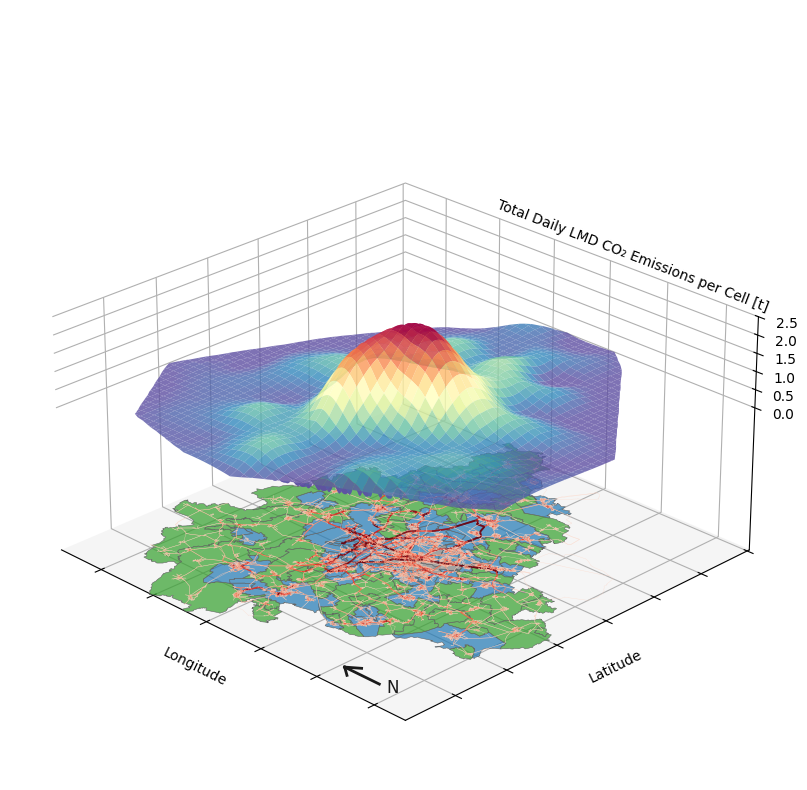

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# --- pick common rotation & origin ---
ROTATE_DEG = 90.0
# use the surface grid center as origin so everything aligns
cx = 0.5*(float(grid_x.min()) + float(grid_x.max()))
cy = 0.5*(float(grid_y.min()) + float(grid_y.max()))
origin = (cx, cy)

# base polygons rotated
base_gdf = regionclusters_split[['area_type', 'geometry']]
base_gdf["area_type_group"] = base_gdf["area_type"].apply(area_type_group)

draw_area_polygons_at(ax, base_gdf, category_color_dict_agg, 
                      alpha=0.7, z0=0,
                      rotate_deg=ROTATE_DEG, origin=origin)

# traffic lines rotated
if 'network_volumes_filtered' in globals():
    lines_gdf = network_volumes_filtered.copy()
    if not lines_gdf.empty:
        lines_gdf = lines_gdf[lines_gdf.get('van_count', 0) > 0]
        target_crs = regionclusters_split.crs if hasattr(regionclusters_split, "crs") else getattr(hex_emit, "crs", None)
        add_traffic_lines_3d(
            ax3d=ax,
            gdf_lines=lines_gdf,
            value_col="van_count",
            z0=0.0 + 1e-6,
            # z0=0,
            lw_min=0.25, lw_max=1.25,
            alpha=0.75,
            crs_target=target_crs,
            rasterized=True,
            rotate_deg=ROTATE_DEG, origin=origin,
            cmap="Reds",        # << hier die Colormap
            vmin=None, vmax=100,
            min_tone=0.15       # etwas sattere Rot-Töne
        )

# rotate the surface grid and plot
Xr, Yr = rotate_grid(grid_x, grid_y, cx, cy, ROTATE_DEG)
surf = ax.plot_surface(
    Xr, Yr, grid_z_masked,
    cmap="Spectral_r",
    linewidth=0, antialiased=True,
    alpha=0.8, vmin=vmin, vmax=vmax
)
surf.set_rasterized(True)

# --- everything below stays as you had it, but use Xr/Yr for extents ---
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 1, 0.7, 1]))

ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
ax.yaxis.pane.set_facecolor((1, 1, 1, 0))

# limits from rotated grid
ax.set_xlim(float(Xr.min()), float(Xr.max() + 2500))
ax.set_ylim(float(Yr.min() - 2500), float(Yr.max()))

ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False)

# North arrow built from rotated extents
x0 = float(Xr.min()) + 48500.0
y0 = float(Yr.min()) + 2000.0
z0 = 0.0
x_span = float(Xr.max() - Xr.min())
L = max(1.0, 0.1 * x_span)
x_tip = min(x0 + L, float(Xr.max()) - 0.01 * x_span)
ax.plot([x0, x_tip], [y0, y0], [z0, z0], color="k", linewidth=2)
h_ar = 0.28 * L; w_ar = 0.23 * L
ax.plot([x0, x0 + h_ar], [y0, y0 - w_ar], [z0, z0], color="k", linewidth=2)
ax.plot([x0, x0 + h_ar], [y0, y0 + w_ar], [z0, z0], color="k", linewidth=2)
ax.text(x_tip + 0.2 * L, y0, z0, "N", color="k", fontsize=12, ha="left", va="center")

ax.set_zlabel("")
ax.text2D(0.63, 0.68, "Total Daily LMD CO₂ Emissions per Cell [t]",
          transform=ax.transAxes, rotation=-21, va="center", ha="left")

ax.view_init(elev=25, azim=-45)

# your shifted z ticks unchanged
ax.set_zlim(0, 6.5)
ticks = np.arange(4.0, 6.51, 0.5)
ax.set_zticks(ticks)
ax.set_zticklabels([str(v - 4.0) for v in ticks])

plt.tight_layout()
fig.savefig("emissions_surface_new.svg", format="svg",
            bbox_inches="tight", pad_inches=0.02, transparent=True)
plt.show()


In [ ]:
# Sicherstellen, dass die Area-Type-Spalte als Name vorliegt
if 'main_area_type_name' not in network_volumes_df.columns:
    if 'raumtyp' in network_volumes_df.columns:
        network_volumes_df['main_area_type_name'] = network_volumes_df['raumtyp'].astype(str).map(category_dict)
    elif 'main_area_type' in network_volumes_df.columns:
        network_volumes_df['main_area_type_name'] = network_volumes_df['main_area_type'].astype(str).map(category_dict)
    else:
        print('Keine Area-Type-Spalte gefunden!')
        
# --- Aggregierte Kenngrößen pro Raumtyp (wissenschaftlich sortiert, logisch gruppiert) ---
# 1. Raumtyp-Nummer für alle Links zuordnen
network_volumes_df['raumtyp'] = network_volumes_df['link_id'].map(link_raumtyp)
category_dict_int = {int(k): v for k, v in category_dict.items()}
network_volumes_df['main_area_type_name'] = network_volumes_df['raumtyp'].map(category_dict_int)

# Nur gültige Area Types verwenden
valid_areas = [category_dict_int[i] for i in range(1,9)]
network_volumes_valid = network_volumes_df[network_volumes_df['main_area_type_name'].isin(valid_areas)].copy()

# Netzwerklänge pro Raumtyp (jeder Link nur 1x gezählt) -- Umrechnung von Meter in Kilometer
link_col = 'link_id' if 'link_id' in network_volumes_valid.columns else 'id'
net_length_by_area = network_volumes_valid.drop_duplicates(subset=[link_col]).groupby('main_area_type_name')['length'].sum().rename('network_length_m')
net_length_by_area_km = (net_length_by_area / 1000).rename('network_length_km')
total_network_length_km = net_length_by_area_km.sum()
network_share_percent = (net_length_by_area_km / total_network_length_km * 100).rename('network_share_percent')

# Gesamtkilometer pro Raumtyp: Summe (Fahrzeuge pro Link * Linklänge)
if 'van_count' in network_volumes_valid.columns:
    network_volumes_valid['km_on_link'] = network_volumes_valid['van_count'] * (network_volumes_valid['length'] / 1000)
else:
    print('Warnung: van_count fehlt, es werden nur Linklängen summiert!')
    network_volumes_valid['km_on_link'] = network_volumes_valid['length'] / 1000
km_by_area = network_volumes_valid.groupby('main_area_type_name')['km_on_link'].sum().rename('total_km')
total_km_all = km_by_area.sum()
km_share = (km_by_area / total_km_all * 100).rename('km_share_percent')

# km_to_network_ratio: total_km / network_length_km
km_to_net_ratio = (km_by_area / net_length_by_area_km).rename('km_to_network_ratio')

# Anzahl Fahrzeuge pro Raumtyp (aus result)
veh_count = result.groupby('main_area_type_name')['vehicle_id'].nunique().rename('vehicle_count')

# Gesamtemissionen pro Raumtyp (aus result['emissions'])
result['total_emissions_g'] = result['emissions'].apply(lambda x: x['total'] if isinstance(x, dict) and 'total' in x else 0)
emissions_by_area = result.groupby('main_area_type_name')['total_emissions_g'].sum().rename('total_emissions_kg') / 1000  # in kg
total_emissions_all = emissions_by_area.sum()
em_share = (emissions_by_area / total_emissions_all * 100).rename('emissions_share_percent')

# DataFrame zusammenführen
agg_df = pd.concat([
    veh_count,
    net_length_by_area_km, network_share_percent,
    km_by_area, km_share, km_to_net_ratio,
    emissions_by_area, em_share
], axis=1)
agg_df = agg_df.reset_index().rename(columns={'main_area_type_name': 'Area Type'})
agg_df['total_emissions_t'] = agg_df['total_emissions_kg'] / 1000

# Sortierung nach Raumtyp 1-8
area_order = [category_dict_int[i] for i in range(1,9)]
agg_df['area_sort'] = agg_df['Area Type'].apply(lambda x: area_order.index(x) if x in area_order else 99)
agg_df = agg_df.sort_values('area_sort').drop(columns='area_sort')

# Spaltenreihenfolge für wissenschaftliche Lesbarkeit (ohne total_emissions_kg)
cols = [
    'Area Type',
    'vehicle_count',
    'network_length_km', 'network_share_percent',
    'total_km', 'km_share_percent', 'km_to_network_ratio',
    'total_emissions_t', 'emissions_share_percent'
]
agg_df = agg_df[cols]

# Formatierung
agg_df['network_share_percent'] = agg_df['network_share_percent'].round(2)
agg_df['km_share_percent'] = agg_df['km_share_percent'].round(2)
agg_df['km_to_network_ratio'] = agg_df['km_to_network_ratio'].round(3)
agg_df['total_emissions_t'] = agg_df['total_emissions_t'].round(2)
agg_df['emissions_share_percent'] = agg_df['emissions_share_percent'].round(2)

agg_df.style.format({
    'network_length_km': '{:,.0f}',
    'total_km': '{:,.0f}',
    'total_emissions_t': '{:,.2f}',
    'km_share_percent': '{:,.2f}%','network_share_percent': '{:,.2f}%','emissions_share_percent': '{:,.2f}%'
}).set_caption('Aggregierte Kenngrößen pro Raumtyp (wissenschaftlich sortiert)')

agg_df["distance_per_vehicle"] =  agg_df["total_km"] / agg_df["vehicle_count"] 
agg_df


In [ ]:
network_volumes_df["agg_area_type"] = network_volumes_df["raumtyp"].apply(determine_area_type)

In [ ]:
result["agg_area_type"] = result["main_area_type"].apply(determine_area_type)

In [ ]:

# Nur gültige Area Types verwenden
valid_areas = [category_dict_int[i] for i in range(1,9)]
network_volumes_valid = network_volumes_df[network_volumes_df['main_area_type_name'].isin(valid_areas)].copy()

# Netzwerklänge pro Raumtyp (jeder Link nur 1x gezählt) -- Umrechnung von Meter in Kilometer
link_col = 'link_id' if 'link_id' in network_volumes_valid.columns else 'id'
net_length_by_area = network_volumes_valid.drop_duplicates(subset=[link_col]).groupby('agg_area_type')['length'].sum().rename('network_length_m')
net_length_by_area_km = (net_length_by_area / 1000).rename('network_length_km')
total_network_length_km = net_length_by_area_km.sum()
network_share_percent = (net_length_by_area_km / total_network_length_km * 100).rename('network_share_percent')

# Gesamtkilometer pro Raumtyp: Summe (Fahrzeuge pro Link * Linklänge)
if 'van_count' in network_volumes_valid.columns:
    network_volumes_valid['km_on_link'] = network_volumes_valid['van_count'] * (network_volumes_valid['length'] / 1000)
else:
    print('Warnung: van_count fehlt, es werden nur Linklängen summiert!')
    network_volumes_valid['km_on_link'] = network_volumes_valid['length'] / 1000
km_by_area = network_volumes_valid.groupby('agg_area_type')['km_on_link'].sum().rename('total_km')
total_km_all = km_by_area.sum()
km_share = (km_by_area / total_km_all * 100).rename('km_share_percent')

# km_to_network_ratio: total_km / network_length_km
km_to_net_ratio = (km_by_area / net_length_by_area_km).rename('km_to_network_ratio')

# Anzahl Fahrzeuge pro Raumtyp (aus result)
veh_count = result.groupby('agg_area_type')['vehicle_id'].nunique().rename('vehicle_count')

# Gesamtemissionen pro Raumtyp (aus result['emissions'])
result['total_emissions_g'] = result['emissions'].apply(lambda x: x['total'] if isinstance(x, dict) and 'total' in x else 0)
emissions_by_area = result.groupby('agg_area_type')['total_emissions_g'].sum().rename('total_emissions_kg') / 1000  # in kg
total_emissions_all = emissions_by_area.sum()
em_share = (emissions_by_area / total_emissions_all * 100).rename('emissions_share_percent')

# DataFrame zusammenführen
agg_df = pd.concat([
    veh_count,
    net_length_by_area_km, network_share_percent,
    km_by_area, km_share, km_to_net_ratio,
    emissions_by_area, em_share
], axis=1)
agg_df = agg_df.reset_index().rename(columns={'agg_area_type': 'Area Type'})
agg_df['total_emissions_t'] = agg_df['total_emissions_kg'] / 1000

# Sortierung nach Raumtyp 1-8
area_order = [category_dict_int[i] for i in range(1,9)]
agg_df['area_sort'] = agg_df['Area Type'].apply(lambda x: area_order.index(x) if x in area_order else 99)
agg_df = agg_df.sort_values('area_sort').drop(columns='area_sort')

# Spaltenreihenfolge für wissenschaftliche Lesbarkeit (ohne total_emissions_kg)
cols = [
    'Area Type',
    'vehicle_count',
    'network_length_km', 'network_share_percent',
    'total_km', 'km_share_percent', 'km_to_network_ratio',
    'total_emissions_t', 'emissions_share_percent'
]
agg_df = agg_df[cols]

# Formatierung
agg_df['network_share_percent'] = agg_df['network_share_percent'].round(2)
agg_df['km_share_percent'] = agg_df['km_share_percent'].round(2)
agg_df['km_to_network_ratio'] = agg_df['km_to_network_ratio'].round(3)
agg_df['total_emissions_t'] = agg_df['total_emissions_t'].round(2)
agg_df['emissions_share_percent'] = agg_df['emissions_share_percent'].round(2)

agg_df.style.format({
    'network_length_km': '{:,.0f}',
    'total_km': '{:,.0f}',
    'total_emissions_t': '{:,.2f}',
    'km_share_percent': '{:,.2f}%','network_share_percent': '{:,.2f}%','emissions_share_percent': '{:,.2f}%'
}).set_caption('Aggregierte Kenngrößen pro Raumtyp (wissenschaftlich sortiert)')

agg_df["distance_per_vehicle"] =  agg_df["total_km"] / agg_df["vehicle_count"] 
agg_df

In [ ]:
# Add area_type to links_gdf
links_gdf["area_type"] = links_gdf["link_id"].map(link_raumtyp)

In [ ]:
links_gdf["emissions_g_day"].sum()

In [ ]:
links_gdf.groupby("area_type")["emissions_g_day"].sum() / 1000.0  # in kg   